<a href="https://colab.research.google.com/github/webercw/Hydraulic-System-State-Prediction/blob/main/%E6%B8%85%E5%A4%A7%E8%B3%87%E6%96%99%E7%A7%91%E5%AD%B8%E7%A4%BE%E5%B0%88%E6%A1%88_%E6%B6%B2%E5%A3%93%E7%B3%BB%E7%B5%B1%E7%8B%80%E6%85%8B%E9%A0%90%E6%B8%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 資料處理

In [ ]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

### 檔案匯入

In [ ]:
# 將液壓系統紀錄的 zip 檔資料上傳
uploaded = files.upload()

# 自動獲取上傳的檔案名稱
# uploaded 是一個字典，keys() 裡面存的是檔名
zip_filename = list(uploaded.keys())[0]

# 印出上傳的檔案名稱
print(f"偵測到上傳檔案: {zip_filename}")

Saving archive.zip to archive (8).zip
偵測到上傳檔案: archive (8).zip


In [ ]:
# 設定解壓縮後資料儲存的路徑
raw_data_dir = 'raw_data'

# 若指定的路徑 (raw_data_dir) 不存在，則建立該路徑
if not os.path.exists(raw_data_dir):
    os.makedirs(raw_data_dir)

# 解壓縮 ('r' 代表讀取模式)
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    # 將 zip 檔內所有資料夾與資料全部解壓縮
    zip_ref.extractall(raw_data_dir)
    # 印出解壓縮結果
    print(f"檔案已解壓至: {raw_data_dir}")

檔案已解壓至: raw_data


In [ ]:
# 創建一個空的 list ，用以存取所有找到的檔案路徑
txt_list = []

# 使用 os.walk 可以遞迴搜尋資料夾內所有的 txt 檔 (預防 zip 檔內還有子目錄)
'''
root：目前走到的資料夾路徑
dirs：該資料夾下的子資料夾
files：該資料夾下的檔案
'''
for root, dirs, files in os.walk(raw_data_dir):
    # 檢查目前資料夾下的每一個檔案
    for file in files:
        # 若副檔名是 .txt 的檔案，將路徑存入 txt_list
        if file.endswith(".txt"):
            # os.path.join(root, file) 將資料夾路徑 (root) 與檔名 (file) 組合在一起
            txt_list.append(os.path.join(root, file))

# 印出檔案匯入的結果
print(f"共找到 {len(txt_list)} 個 .txt 檔案: ", txt_list)

共找到 20 個 .txt 檔案:  ['raw_data/TS4.txt', 'raw_data/SE.txt', 'raw_data/EPS1.txt', 'raw_data/VS1.txt', 'raw_data/PS5.txt', 'raw_data/documentation.txt', 'raw_data/PS1.txt', 'raw_data/CE.txt', 'raw_data/CP.txt', 'raw_data/PS6.txt', 'raw_data/TS2.txt', 'raw_data/PS3.txt', 'raw_data/PS2.txt', 'raw_data/TS1.txt', 'raw_data/TS3.txt', 'raw_data/FS2.txt', 'raw_data/PS4.txt', 'raw_data/FS1.txt', 'raw_data/profile.txt', 'raw_data/description.txt']


### 將 txt 檔轉為 csv 檔

In [ ]:
# 設定 txt 檔轉為 csv 檔後，資料儲存的路徑
converted_csv_dir = 'csv_data'

# 若指定的路徑 (converted_csv_dir) 不存在，則建立該路徑
if not os.path.exists(converted_csv_dir):
    os.makedirs(converted_csv_dir)

In [ ]:
# 設定要轉換的特定檔名（不含副檔名）
target_files = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4', 'FS1', 'FS2', 'VS1', 'EPS1']

In [ ]:
# 將 txt 檔轉為 csv 檔
for txt_path in txt_list:
    # 取得原始檔名（不含副檔名）
    base_name = os.path.basename(txt_path).replace('.txt', '')

    # 只處理要轉換的特定檔案 (target_files)
    if base_name in target_files:

        try:
            # 讀取 txt 檔
            '''
            sep='\t': 讀取 Tab 分隔的檔案
            header=None: 表示檔案第一行為數據，不是欄位名稱（標題）
            '''
            df = pd.read_csv(txt_path, sep='\t', header=None)

            # 取得檔案的總 column 數
            num_cols = df.shape[1]
            # 設定 column 標題
            new_headers = [f"time_{i+1}" for i in range(num_cols)]
            # 將清單 (new_headers) 賦值給 DataFrame 的 columns
            df.columns = new_headers

            # 設定循環數標題，df.shape[0] 用以確保編號與資料 row 數完全對齊
            cycle_ids = np.arange(1, df.shape[0] + 1)
            # 在索引 0 插入 'cycle_id' 的欄位
            df.insert(0, 'cycle_id', cycle_ids)

            # 定義 csv 檔的路徑
            csv_path = os.path.join(converted_csv_dir, f"{base_name}.csv")
            # 儲存為 csv 檔 (index=False 代表不儲存列索引)
            df.to_csv(csv_path, index=False)
            # 印出完成轉換的結果
            print(f"完成: {base_name}.txt -> {base_name}.csv")

        # 當程式執行發生錯誤時，印出錯誤原因
        except Exception as e:
            print(f"錯誤: 無法轉換 {base_name}.txt。原因: {e}")

    else:
      # 如果不在清單 (target_files) 內，跳過不處理
      continue

# 印出完成轉換的結果以及 csv 檔路徑
print(f"\n轉換完成！所有 CSV 檔案存放在: {converted_csv_dir}")

完成: TS4.txt -> TS4.csv
完成: EPS1.txt -> EPS1.csv
完成: VS1.txt -> VS1.csv
完成: PS5.txt -> PS5.csv
完成: PS1.txt -> PS1.csv
完成: PS6.txt -> PS6.csv
完成: TS2.txt -> TS2.csv
完成: PS3.txt -> PS3.csv
完成: PS2.txt -> PS2.csv
完成: TS1.txt -> TS1.csv
完成: TS3.txt -> TS3.csv
完成: FS2.txt -> FS2.csv
完成: PS4.txt -> PS4.csv
完成: FS1.txt -> FS1.csv

轉換完成！所有 CSV 檔案存放在: csv_data


## 資料分割 & 特徵提取

將各感測器數值的平均視覺化，觀察數值的平均趨勢，捨棄變化幅度極小、無法反映設備狀態的感測器數據 (PS4-6、TS1-4、FS2) ，並將剩下的感測器 (PS1-3、EPS1、FS1、VS1) 以趨勢圖上的明顯轉折點作為分段點切分區段，並計算統計值 (平均、中位數、最大值、最小值、變異數、斜率、偏態、 峰態) 。

In [ ]:
# 定義一個計算各切片區間 (時間段) 之統計值的函數
def segment_features(row):

    # 創建一個空的 list (feats) ，用以存取各切片區間 (時間段) 之統計值
    feats = []

    for (s, e) in segments:
        # 取得切片區間 (時間段) 數據
        seg = row[s:e]

        # 計算切片區間 (時間段) 之平均
        mean = seg.mean()
        # 計算切片區間 (時間段) 之中位數
        median = np.median(seg)
        # 計算切片區間 (時間段) 之最小值
        vmin = seg.min()
        # 計算切片區間 (時間段) 之最大值
        vmax = seg.max()
        # 計算切片區間 (時間段) 之變異數 (ddof=1 代表樣本變異數)
        var = seg.var(ddof=1)

        # 計算切片區間 (時間段) 之斜率
        # 使用最小平方法計算斜率: slope = Sum[(xi - x_mean) * (yi - y_mean)] / Sum[(xi - x_mean)^2]
        # 切片區間 (時間段) 之時間點 (1, 2, 3, ...)
        x = np.arange(1, len(seg) + 1, dtype=float)
        # 時間點加總平均
        x_mean = x.mean()
        # 切片區間 (時間段) 之平均
        y_mean = mean
        # 計算公式中的分母 (代表時間點的變異程度)
        denom = np.sum((x - x_mean) ** 2)
        # 若分母為 0 (只有一個點，無法計算趨勢)，斜率設為 0
        if denom == 0:
            slope = 0.0
        else:
            slope = np.sum((x - x_mean) * (seg - y_mean)) / denom

        # 計算切片區間 (時間段) 之偏態與峰態
        '''
        Skew = 0: 左右對稱（像常態分佈）。
        Skew > 0 (正偏): 數據有一條長長的右尾巴（右側有少數極大值）。
        Skew < 0 (負偏): 數據有一條長長的左尾巴（左側有少數極小值）。

        樣本超額峰度 (Sample Excess Kurtosis) 計算:
        Kurt = 0: 分佈的尖銳程度與常態分佈一致。
        Kurt > 0 (高狹峰): 分佈非常尖銳，且擁有肥厚的尾巴（代表極端值出現頻率較高）。
        Kurt < 0 (低闊峰): 分佈較平坦，極端值較少。
        '''
        # 計算切片區間 (時間段) 之長度
        n = len(seg)
        # 計算偏態與峰態之切片區間 (時間段) 最小長度
        if n > 3:
            # 將數據減去平均值，讓數據中心點歸零
            centered = seg - mean
            # 二階動差 (變異數 Variance)
            m2 = np.mean(centered ** 2)
            # 三階動差
            m3 = np.mean(centered ** 3)
            # 四階動差
            m4 = np.mean(centered ** 4)
            # 若二階動差 (變異數 Variance) 為 0 ，代表該段數據完全沒有變化（所有數值都一樣)
            if m2 == 0:
                # 所有數值都一樣，偏態設定為 0
                skew = 0.0
                # 所有數值都一樣，超額峰度 （Excess Kurtosis） 通常視為 -3
                kurt = -3.0
            else:
                # 計算切片區間 (時間段) 之偏態
                skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / (m2 ** 1.5))
                # 計算切片區間 (時間段) 之樣本超額峰度 (Sample Excess Kurtosis)
                kurt = ((n - 1) / ((n - 2) * (n - 3))) * (
                    (n + 1) * (m4 / (m2 ** 2)) - 3 * (n - 1)
                )
        else:
            # 計算偏態與峰態之切片區間 (時間段) 長度太短就定義為 NaN
            skew = np.nan
            kurt = np.nan

        # 將統計值計算的結果存入 feats 中
        feats.extend([mean, median, vmin, vmax, var, slope, skew, kurt])

    # 將處理完的資料轉換成 Numpy 陣列格式並回傳 (回傳所有切片區間 (時間段) 之統計值)
    return np.array(feats)

In [ ]:
# 定義一個計算整個區間 (整個時間段) 之統計值的函數
def all_features(row):
    # 取得整個區間 (整個時間段) 數據
    seg = row

    # 計算整個區間 (整個時間段) 之平均
    mean = seg.mean()
    # 計算整個區間 (整個時間段) 之中位數
    median = np.median(seg)
    # 計算整個區間 (整個時間段) 之最小值
    vmin = seg.min()
    # 計算整個區間 (整個時間段) 之最大值
    vmax = seg.max()
    # 計算整個區間 (整個時間段) 之變異數 (ddof=1 代表樣本變異數)
    var = seg.var(ddof=1)

    # 計算整個區間 (整個時間段) 之斜率
    # 使用最小平方法計算斜率: slope = Sum[(xi - x_mean) * (yi - y_mean)] / Sum[(xi - x_mean)^2]
    # 整個區間 (整個時間段) 之時間點 (1, 2, 3, ...)
    x = np.arange(1, len(seg) + 1, dtype=float)
    # 時間點加總平均
    x_mean = x.mean()
    # 整個區間 (整個時間段) 之平均
    y_mean = mean
    # 計算公式中的分母 (代表時間點的變異程度)
    denom = np.sum((x - x_mean) ** 2)
    slope = np.sum((x - x_mean) * (seg - y_mean)) / denom

    # 計算整個區間 (整個時間段) 之偏態與峰態
    '''
    Skew = 0: 左右對稱（像常態分佈）。
    Skew > 0 (正偏): 數據有一條長長的右尾巴（右側有少數極大值）。
    Skew < 0 (負偏): 數據有一條長長的左尾巴（左側有少數極小值）。
    樣本超額峰度 (Sample Excess Kurtosis) 計算:
    Kurt = 0: 分佈的尖銳程度與常態分佈一致。
    Kurt > 0 (高狹峰): 分佈非常尖銳，且擁有肥厚的尾巴（代表極端值出現頻率較高）。
    Kurt < 0 (低闊峰): 分佈較平坦，極端值較少。
    '''
    # 計算整個區間 (整個時間段) 之長度
    n = len(seg)
    # 將數據減去平均值，讓數據中心點歸零
    centered = seg - mean
    # 二階動差 (變異數 Variance)
    m2 = np.mean(centered ** 2)
    # 三階動差
    m3 = np.mean(centered ** 3)
    # 四階動差
    m4 = np.mean(centered ** 4)
    # 若二階動差 (變異數 Variance) 為 0 ，代表該段數據完全沒有變化（所有數值都一樣)
    if m2 == 0:
        # 所有數值都一樣，偏態設定為 0
        skew = 0.0
        # 所有數值都一樣，超額峰度 （Excess Kurtosis） 通常視為 -3
        kurt = -3.0
    else:
        # 計算整個區間 (整個時間段) 之偏態
        skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / (m2 ** 1.5))
        # 計算整個區間 (整個時間段) 之樣本超額峰度 (Sample Excess Kurtosis)
        kurt = ((n - 1) / ((n - 2) * (n - 3))) * (
            (n + 1) * (m4 / (m2 ** 2)) - 3 * (n - 1)
        )

    # 將處理完的資料轉換成 Numpy 陣列格式並回傳 (回傳整個區間 (整個時間段) 之統計值)
    return np.array([mean, median, vmin, vmax, var, slope, skew, kurt])

In [ ]:
# 選取的八個統計值名稱
stats_names = ["mean", "median", "min", "max", "var", "slope", "skew", "kurt"]

### PS1

In [ ]:
# 讀取 PS1.csv
ps1 = pd.read_csv(os.path.join(converted_csv_dir, "PS1.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_ps1 = ps1.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_ps1.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 6000)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 101),
    (102, 943),
    (944, 1041),
    (1042, 1905),
    (1906, 2012),
    (2013, 2904),
    (2905, 2948),
    (2949, 3903),
    (3904, 3947),
    (3948, 4908),
    (4909, 4936),
    (4937, 6000),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_ps1：排除掉 cycle_id 後的純數據矩陣
'''
features_ps1 = np.apply_along_axis(segment_features, 1, data_ps1)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_ps1.shape}")

分段特徵形狀: (2205, 96)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_ps1：排除掉 cycle_id 後的純數據矩陣
'''
features_all_ps1 = np.apply_along_axis(all_features, 1, data_ps1)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_ps1.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_PS1 = np.hstack((features_ps1, features_all_ps1))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_PS1.shape}")

合併後特徵形狀: (2205, 104)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_PS1_df = pd.DataFrame(features_PS1, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_PS1_df.to_csv("PS1_features.csv", index=False)

### PS2

In [ ]:
# 讀取 PS2.csv
ps2 = pd.read_csv(os.path.join(converted_csv_dir, "PS2.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_ps2 = ps2.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_ps2.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 6000)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 41),
    (42, 935),
    (936, 973),
    (974, 1026),
    (1027, 1904),
    (1905, 2015),
    (2016, 2904),
    (2905, 2948),
    (2949, 3904),
    (3905, 3931),
    (3932, 4904),
    (4905, 4930),
    (4931, 6000),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_ps2：排除掉 cycle_id 後的純數據矩陣
'''
features_ps2 = np.apply_along_axis(segment_features, 1, data_ps2)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_ps2.shape}")

分段特徵形狀: (2205, 104)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_ps2：排除掉 cycle_id 後的純數據矩陣
'''
features_all_ps2 = np.apply_along_axis(all_features, 1, data_ps2)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_ps2.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_PS2 = np.hstack((features_ps2, features_all_ps2))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_PS2.shape}")

合併後特徵形狀: (2205, 112)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_PS2_df = pd.DataFrame(features_PS2, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_PS2_df.to_csv("PS2_features.csv", index=False)

### PS3

In [ ]:
# 讀取 PS3.csv
ps3 = pd.read_csv(os.path.join(converted_csv_dir, "PS3.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_ps3 = ps3.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_ps3.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 6000)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 10),
    (11, 937),
    (938, 980),
    (981, 1100),
    (1101, 1904),
    (1905, 1912),
    (1913, 1962),
    (1963, 2904),
    (2905, 2909),
    (2910, 2978),
    (2979, 3904),
    (3905, 3912),
    (3913, 3972),
    (3973, 4904),
    (4905, 4914),
    (4915, 5009),
    (5010, 6000),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_ps3：排除掉 cycle_id 後的純數據矩陣
'''
features_ps3 = np.apply_along_axis(segment_features, 1, data_ps3)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_ps3.shape}")

分段特徵形狀: (2205, 136)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_ps3：排除掉 cycle_id 後的純數據矩陣
'''
features_all_ps3 = np.apply_along_axis(all_features, 1, data_ps3)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_ps3.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_PS3 = np.hstack((features_ps3, features_all_ps3))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_PS3.shape}")

合併後特徵形狀: (2205, 144)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_PS3_df = pd.DataFrame(features_PS3, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_PS3_df.to_csv("PS3_features.csv", index=False)

### EPS1

In [ ]:
# 讀取 EPS1.csv
eps1 = pd.read_csv(os.path.join(converted_csv_dir, "EPS1.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_eps1 = eps1.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_eps1.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 6000)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 101),
    (102, 943),
    (944, 1041),
    (1042, 1905),
    (1906, 2012),
    (2013, 2904),
    (2905, 2948),
    (2949, 3903),
    (3904, 3947),
    (3948, 4908),
    (4909, 4936),
    (4937, 6000),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_eps1：排除掉 cycle_id 後的純數據矩陣
'''
features_eps1 = np.apply_along_axis(segment_features, 1, data_eps1)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_eps1.shape}")

分段特徵形狀: (2205, 96)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_eps1：排除掉 cycle_id 後的純數據矩陣
'''
features_all_eps1 = np.apply_along_axis(all_features, 1, data_eps1)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_eps1.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_EPS1 = np.hstack((features_eps1, features_all_eps1))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_EPS1.shape}")

合併後特徵形狀: (2205, 104)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_EPS1_df = pd.DataFrame(features_EPS1, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_EPS1_df.to_csv("EPS1_features.csv", index=False)

### FS1

In [ ]:
# 讀取 FS1.csv
fs1 = pd.read_csv(os.path.join(converted_csv_dir, "FS1.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_fs1 = fs1.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_fs1.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 600)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 2),
    (3, 4),
    (5, 94),
    (95, 99),
    (100, 117),
    (118, 189),
    (190, 193),
    (194, 198),
    (199, 288),
    (289, 293),
    (294, 299),
    (300, 390),
    (391, 398),
    (399, 489),
    (490, 492),
    (493, 507),
    (508, 600),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_fs1：排除掉 cycle_id 後的純數據矩陣
'''
features_fs1 = np.apply_along_axis(segment_features, 1, data_fs1)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_fs1.shape}")

分段特徵形狀: (2205, 136)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_fs1：排除掉 cycle_id 後的純數據矩陣
'''
features_all_fs1 = np.apply_along_axis(all_features, 1, data_fs1)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_fs1.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_FS1 = np.hstack((features_fs1, features_all_fs1))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_FS1.shape}")

合併後特徵形狀: (2205, 144)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_FS1_df = pd.DataFrame(features_FS1, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_FS1_df.to_csv("FS1_features.csv", index=False)

### VS1

In [ ]:
# 讀取 VS1.csv
vs1 = pd.read_csv(os.path.join(converted_csv_dir, "VS1.csv"))

# 排除第一欄 (因為是 cycle_id)，並只取數值部分
data_vs1 = vs1.iloc[:, 1:].values

# 確認 Numpy Array 的形狀與原始 txt 檔一致
print(f"Numpy Array 形狀 (不含 cycle_id): {data_vs1.shape}")

Numpy Array 形狀 (不含 cycle_id): (2205, 60)


In [ ]:
# 定義切片區間 (時間段)
segments_origin = [
    (1, 9),
    (10, 18),
    (19, 24),
    (25, 29),
    (30, 34),
    (35, 59),
]

# 因為要符合 Python 的設定 (起始點從 0 開始)
# 創建一個空的 list (segments) ，用以存取新定義的切片區間 (時間段)
segments = []

for (s, e) in segments_origin:
    # 新定義的起始點
    new_start = s - 1
    # 結束點不變 (因為 Python 切片不包含最後一項)
    new_end = e
    # 將新定義的切片區間 (時間段) 存入 segments 中
    segments.append((new_start, new_end))

In [ ]:
# 計算每個週期的切片區間 (時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
segment_features：計算各切片區間 (時間段) 之統計值的函數
1：代表橫向（Row）
data_vs1：排除掉 cycle_id 後的純數據矩陣
'''
features_vs1 = np.apply_along_axis(segment_features, 1, data_vs1)

# 確認處理完的資料形狀無誤 (定義各切片區間 (時間段) 之統計值為一分段特徵)
print(f"分段特徵形狀: {features_vs1.shape}")

分段特徵形狀: (2205, 48)


In [ ]:
# 計算每個週期的整個區間 (整個時間段) 之統計值
'''
np.apply_along_axis: 對矩陣的每一列（或每一欄）重複執行同一個動作
all_features：計算整個區間 (整個時間段) 之統計值的函數
1：代表橫向（Row）
data_vs1：排除掉 cycle_id 後的純數據矩陣
'''
features_all_vs1 = np.apply_along_axis(all_features, 1, data_vs1)

# 確認處理完的資料形狀無誤 (定義整個區間 (整個時間段) 之統計值為整體特徵)
print(f"整體特徵形狀: {features_all_vs1.shape}")

整體特徵形狀: (2205, 8)


In [ ]:
# 合併分段特徵與整體特徵 (hstack: 水平合併)
features_VS1 = np.hstack((features_vs1, features_all_vs1))

# 確認處理完的資料形狀無誤
print(f"合併後特徵形狀: {features_VS1.shape}")

合併後特徵形狀: (2205, 56)


In [ ]:
# 設定切片區間 (時間段) 的欄位名稱
colnames_seg = [
    # 以切片區間 (時間段)與統計值名稱命名
    f"seg{i+1}_{stat}"
    # 切片區間 (時間段)
    for i in range(len(segments))
    # 統計值名稱
    for stat in stats_names
]

# 設定整個區間 (整個時間段) 的欄位名稱
colnames_all = [f"all_{stat}" for stat in stats_names]

# 合併切片區間 (時間段) 與 整個區間 (整個時間段) 的欄位名稱
colnames = colnames_seg + colnames_all

# 將 Numpy Array 轉換為 DataFrame (columns=colnames 表示以 colnames 當作表格的標頭)
features_VS1_df = pd.DataFrame(features_VS1, columns=colnames)

In [ ]:
# 將 DataFrame 存成 csv 檔
features_VS1_df.to_csv("VS1_features.csv", index=False)

# 特徵篩選



1.   計算各感測器時間段的統計值與各 condition 故障程度之間的相關性，相關係數取絕對值做排序，取出相關係數0.7以上的感測器統計值
2.   cooler、valve、pump、accumulator 計算 Spearman 相關係數，stable 計算 point-biserial 相關係數
3.   將前一步取出的感測器統計值之間做共線性分析，若共線性0.8以上，留下相關係數較高的感測器統計值



將各感測器統計值與各 condition 故障程度做相關性分析

In [ ]:
# 讀取 profile 資料
profile_df = pd.read_csv('raw_data/profile.txt', sep='\t', header=None, encoding='latin-1')

# 設定 profile 欄位名稱
profile_names = ['Cooler condition', 'Valve condition', 'Pump condition', 'Accumulator condition', 'Stable']

# 賦予 profile_df 新的欄位名稱
profile_df.columns = profile_names

## PS1

In [ ]:
# 獲取 profile 欄位名稱並轉換為 list
profile_cols = profile_df.columns.tolist()

# 獲取 features_PS1 欄位名稱並轉換為 list
feature_PS1_cols = features_PS1_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_PS1，column 放 profile)
PS1_correlation_results = pd.DataFrame(index=feature_PS1_cols, columns=profile_cols)

In [ ]:
# 針對每一個 profile 欄位進行處理
for p_col in profile_cols:

    # 選擇 profile 數據中的單一欄位 (p_col)
    profile_series = profile_df[p_col]

    # 決定使用的相關係數方法
    # 當目標是 Stable
    if p_col == 'Stable':

        # 針對 'Stable' 欄位計算 Point-Biserial Correlation
        # 確保數據是二元變數 (0 或 1)
        if not all(profile_series.isin([0, 1])):
             # 若數據不是二元變數 (0 或 1)，則跳出警告
             print(f"警告：'{p_col}' 欄位不是標準 0/1 格式，嘗試使用astype(int)。")
             # 將 profile_series 中所有數值轉換為整數型態 (排除小數點)
             profile_series = profile_series.astype(int)

        # 計算 Point-Biserial Correlation
        # 創建一個空的字典，以存放相關係數結果
        PS1_correlation_values = {}
        # 計算各感測器之特徵與各 condition 之間的相關性
        for f_col in feature_PS1_cols:
            # 取出該特徵欄位的所有數值 (Numpy Array 格式)
            feature_PS1_series = features_PS1_df[f_col].values
            # 計算相關係數 (r) 與顯著性差異 (p-value)
            '''
            feature_PS1_series 是連續數值
            profile_series.values 是二元變數 (0 或 1)
            pointbiserialr 返回 (r, p_value)，只需要 r
            '''
            r, p = stats.pointbiserialr(feature_PS1_series, profile_series.values)
            # 將計算出的相關係數 (r) 存入字典中
            PS1_correlation_values[f_col] = r
        # 將計算出的相關係數結果轉換成 Pandas Series 格式
        PS1_correlation_series = pd.Series(PS1_correlation_values)
        # 定義使用的統計方法
        method_name = "Point-Biserial"

    else:

        # 計算 features 與 condition 之間的相關係數
        # 使用 .corrwith() 方法計算一個 Series 與 DataFrame 所有欄位的相關性 (使用 Spearman 相關係數)
        PS1_correlation_series = features_PS1_df.corrwith(profile_series, method='spearman')


    # 將結果轉換為 DataFrame (欄位標題設定為 p_col)
    correlation_PS1_df = PS1_correlation_series.to_frame(name=p_col)

    # 取絕對值
    correlation_PS1_df_abs = correlation_PS1_df.abs()

    # 按照指定的欄位（p_col）從大到小排序，方便查看最相關的特徵
    correlation_PS1_df_abs = correlation_PS1_df_abs.sort_values(by=p_col, ascending=False)

    # 在索引 (特徵名稱) 前加上 "PS1_"
    # 使用 .map() 配合 lambda 函式修改索引值
    '''
    map: 是一個映射函數，會對索引中的「每一個元素」執行括號內的動作。
    lambda x: 是一個匿名函數，x 代表原本的索引名稱
    '''
    correlation_PS1_df_abs.index = correlation_PS1_df_abs.index.map(lambda x: f"PS1_{x}")

    # 將索引名稱設定為 "features"
    correlation_PS1_df_abs.index.name = "features"

    # 儲存相關係數結果
    # 設定檔案名稱
    output_filename = f"PS1_{p_col}_Corr_Abs.csv"
    # 將 DataFrame 轉成 csv 檔
    correlation_PS1_df_abs.to_csv(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"PS1_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_PS1_df_abs.head())

PS1_Cooler condition 相關性最高的前 5 個特徵:
                 Cooler condition
features                         
PS1_seg2_mean            0.931514
PS1_seg2_median          0.929814
PS1_all_min              0.929735
PS1_seg4_min             0.928935
PS1_seg4_mean            0.926027
PS1_Valve condition 相關性最高的前 5 個特徵:
                Valve condition
features                       
PS1_seg3_slope         0.913680
PS1_seg3_var           0.909245
PS1_seg3_mean          0.874896
PS1_seg3_kurt          0.864832
PS1_seg3_skew          0.844443
PS1_Pump condition 相關性最高的前 5 個特徵:
                 Pump condition
features                       
PS1_seg2_var           0.470969
PS1_seg3_var           0.428210
PS1_seg7_skew          0.426093
PS1_seg3_slope         0.425116
PS1_seg12_slope        0.417869
PS1_Accumulator condition 相關性最高的前 5 個特徵:
               Accumulator condition
features                            
PS1_seg10_var               0.749982
PS1_seg1_var                0.698577
PS1_seg5_skew       

## PS2

In [ ]:
# 獲取 profile 欄位名稱並轉換為 list
profile_cols = profile_df.columns.tolist()

# 獲取 features_PS2 欄位名稱並轉換為 list
feature_PS2_cols = features_PS2_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_PS2，column 放 profile)
PS2_correlation_results = pd.DataFrame(index=feature_PS2_cols, columns=profile_cols)

In [ ]:
# 針對每一個 profile 欄位進行處理
for p_col in profile_cols:

    # 選擇 profile 數據中的單一欄位 (p_col)
    profile_series = profile_df[p_col]

    # 決定使用的相關係數方法
    # 當目標是 Stable
    if p_col == 'Stable':

        # 針對 'Stable' 欄位計算 Point-Biserial Correlation
        # 確保數據是二元變數 (0 或 1)
        if not all(profile_series.isin([0, 1])):
             # 若數據不是二元變數 (0 或 1)，則跳出警告
             print(f"警告：'{p_col}' 欄位不是標準 0/1 格式，嘗試使用astype(int)。")
             # 將 profile_series 中所有數值轉換為整數型態 (排除小數點)
             profile_series = profile_series.astype(int)

        # 計算 Point-Biserial Correlation
        # 創建一個空的字典，以存放相關係數結果
        PS2_correlation_values = {}
        # 計算各感測器之特徵與各 condition 之間的相關性
        for f_col in feature_PS2_cols:
            # 取出該特徵欄位的所有數值 (Numpy Array 格式)
            feature_PS2_series = features_PS2_df[f_col].values
            # 計算相關係數 (r) 與顯著性差異 (p-value)
            '''
            feature_PS2_series 是連續數值
            profile_series.values 是二元變數 (0 或 1)
            pointbiserialr 返回 (r, p_value)，只需要 r
            '''
            r, p = stats.pointbiserialr(feature_PS2_series, profile_series.values)
            # 將計算出的相關係數 (r) 存入字典中
            PS2_correlation_values[f_col] = r
        # 將計算出的相關係數結果轉換成 Pandas Series 格式
        PS2_correlation_series = pd.Series(PS2_correlation_values)
        # 定義使用的統計方法
        method_name = "Point-Biserial"

    else:

        # 計算 features 與 condition 之間的相關係數
        # 使用 .corrwith() 方法計算一個 Series 與 DataFrame 所有欄位的相關性 (使用 Spearman 相關係數)
        PS2_correlation_series = features_PS2_df.corrwith(profile_series, method='spearman')


    # 將結果轉換為 DataFrame (欄位標題設定為 p_col)
    correlation_PS2_df = PS2_correlation_series.to_frame(name=p_col)

    # 取絕對值
    correlation_PS2_df_abs = correlation_PS2_df.abs()

    # 按照指定的欄位（p_col）從大到小排序，方便查看最相關的特徵
    correlation_PS2_df_abs = correlation_PS2_df_abs.sort_values(by=p_col, ascending=False)

    # 在索引 (特徵名稱) 前加上 "PS2_"
    # 使用 .map() 配合 lambda 函式修改索引值
    '''
    map: 是一個映射函數，會對索引中的「每一個元素」執行括號內的動作。
    lambda x: 是一個匿名函數，x 代表原本的索引名稱
    '''
    correlation_PS2_df_abs.index = correlation_PS2_df_abs.index.map(lambda x: f"PS2_{x}")

    # 將索引名稱設定為 "features"
    correlation_PS2_df_abs.index.name = "features"

    # 儲存相關係數結果
    # 設定檔案名稱
    output_filename = f"PS2_{p_col}_Corr_Abs.csv"
    # 將 DataFrame 轉成 csv 檔
    correlation_PS2_df_abs.to_csv(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"PS2_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_PS2_df_abs.head())

PS2_Cooler condition 相關性最高的前 5 個特徵:
                 Cooler condition
features                         
PS2_seg10_var            0.930498
PS2_seg5_min             0.926919
PS2_seg5_mean            0.924206
PS2_seg5_median          0.923814
PS2_all_max              0.923750


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS2_Valve condition 相關性最高的前 5 個特徵:
                Valve condition
features                       
PS2_seg3_skew          0.924194
PS2_seg3_mean          0.924194
PS2_seg4_max           0.876804
PS2_seg3_min           0.863983
PS2_seg4_slope         0.858638


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS2_Pump condition 相關性最高的前 5 個特徵:
               Pump condition
features                     
PS2_seg8_kurt        0.533451
PS2_seg8_skew        0.491433
PS2_all_skew         0.404009
PS2_seg3_skew        0.398888
PS2_seg11_var        0.394772
PS2_Accumulator condition 相關性最高的前 5 個特徵:
               Accumulator condition
features                            
PS2_seg11_var               0.631509
PS2_seg4_skew               0.604724
PS2_seg13_var               0.525278
PS2_seg6_skew               0.515122
PS2_seg4_kurt               0.513819


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS2_Stable 相關性最高的前 5 個特徵:
                  Stable
features                
PS2_seg3_kurt   0.670454
PS2_seg3_slope  0.648641
PS2_seg3_var    0.631205
PS2_seg3_min    0.629139
PS2_seg3_skew   0.614491


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


## PS3

In [ ]:
# 獲取 profile 欄位名稱並轉換為 list
profile_cols = profile_df.columns.tolist()

# 獲取 features_PS2 欄位名稱並轉換為 list
feature_PS3_cols = features_PS3_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_PS2，column 放 profile)
PS3_correlation_results = pd.DataFrame(index=feature_PS3_cols, columns=profile_cols)

In [ ]:
# 針對每一個 profile 欄位進行處理
for p_col in profile_cols:

    # 選擇 profile 數據中的單一欄位 (p_col)
    profile_series = profile_df[p_col]

    # 決定使用的相關係數方法
    # 當目標是 Stable
    if p_col == 'Stable':

        # 針對 'Stable' 欄位計算 Point-Biserial Correlation
        # 確保數據是二元變數 (0 或 1)
        if not all(profile_series.isin([0, 1])):
             # 若數據不是二元變數 (0 或 1)，則跳出警告
             print(f"警告：'{p_col}' 欄位不是標準 0/1 格式，嘗試使用astype(int)。")
             # 將 profile_series 中所有數值轉換為整數型態 (排除小數點)
             profile_series = profile_series.astype(int)

        # 計算 Point-Biserial Correlation
        # 創建一個空的字典，以存放相關係數結果
        PS3_correlation_values = {}
        # 計算各感測器之特徵與各 condition 之間的相關性
        for f_col in feature_PS3_cols:
            # 取出該特徵欄位的所有數值 (Numpy Array 格式)
            feature_PS3_series = features_PS3_df[f_col].values
            # 計算相關係數 (r) 與顯著性差異 (p-value)
            '''
            feature_PS3_series 是連續數值
            profile_series.values 是二元變數 (0 或 1)
            pointbiserialr 返回 (r, p_value)，只需要 r
            '''
            r, p = stats.pointbiserialr(feature_PS3_series, profile_series.values)
            # 將計算出的相關係數 (r) 存入字典中
            PS3_correlation_values[f_col] = r
        # 將計算出的相關係數結果轉換成 Pandas Series 格式
        PS3_correlation_series = pd.Series(PS3_correlation_values)
        # 定義使用的統計方法
        method_name = "Point-Biserial"

    else:

        # 計算 features 與 condition 之間的相關係數
        # 使用 .corrwith() 方法計算一個 Series 與 DataFrame 所有欄位的相關性 (使用 Spearman 相關係數)
        PS3_correlation_series = features_PS3_df.corrwith(profile_series, method='spearman')


    # 將結果轉換為 DataFrame (欄位標題設定為 p_col)
    correlation_PS3_df = PS3_correlation_series.to_frame(name=p_col)

    # 取絕對值
    correlation_PS3_df_abs = correlation_PS3_df.abs()

    # 按照指定的欄位（p_col）從大到小排序，方便查看最相關的特徵
    correlation_PS3_df_abs = correlation_PS3_df_abs.sort_values(by=p_col, ascending=False)

    # 在索引 (特徵名稱) 前加上 "PS3_"
    # 使用 .map() 配合 lambda 函式修改索引值
    '''
    map: 是一個映射函數，會對索引中的「每一個元素」執行括號內的動作。
    lambda x: 是一個匿名函數，x 代表原本的索引名稱
    '''
    correlation_PS3_df_abs.index = correlation_PS3_df_abs.index.map(lambda x: f"PS3_{x}")

    # 將索引名稱設定為 "features"
    correlation_PS3_df_abs.index.name = "features"

    # 儲存相關係數結果
    # 設定檔案名稱
    output_filename = f"PS3_{p_col}_Corr_Abs.csv"
    # 將 DataFrame 轉成 csv 檔
    correlation_PS3_df_abs.to_csv(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"PS3_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_PS3_df_abs.head())

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS3_Cooler condition 相關性最高的前 5 個特徵:
                 Cooler condition
features                         
PS3_all_skew             0.924286
PS3_seg11_min            0.923190
PS3_all_kurt             0.922103
PS3_seg5_mean            0.912238
PS3_seg5_median          0.911752


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS3_Valve condition 相關性最高的前 5 個特徵:
                Valve condition
features                       
PS3_seg4_max           0.915312
PS3_seg4_slope         0.910597
PS3_seg3_mean          0.903004
PS3_seg4_var           0.891706
PS3_seg3_slope         0.814026


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS3_Pump condition 相關性最高的前 5 個特徵:
                  Pump condition
features                        
PS3_seg12_min           0.523487
PS3_seg12_max           0.498716
PS3_seg12_mean          0.494729
PS3_seg11_max           0.487063
PS3_seg12_median        0.444027


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


PS3_Accumulator condition 相關性最高的前 5 個特徵:
                Accumulator condition
features                             
PS3_seg2_slope               0.529595
PS3_seg2_mean                0.527952
PS3_seg2_var                 0.523933
PS3_seg2_max                 0.517956
PS3_seg1_max                 0.494652
PS3_Stable 相關性最高的前 5 個特徵:
                  Stable
features                
PS3_seg3_slope  0.699745
PS3_seg4_slope  0.545739
PS3_seg3_mean   0.534499
PS3_seg3_var    0.532620
PS3_seg4_max    0.517845


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


## EPS1

In [ ]:
# 獲取 features_EPS1 欄位名稱並轉換為 list
feature_EPS1_cols = features_EPS1_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_EPS1，column 放 profile)
EPS1_correlation_results = pd.DataFrame(index=feature_EPS1_cols, columns=profile_cols)

In [ ]:
# 針對每一個 profile 欄位進行處理
for p_col in profile_cols:

    # 選擇 profile 數據中的單一欄位 (p_col)
    profile_series = profile_df[p_col]

    # 決定使用的相關係數方法
    # 當目標是 Stable
    if p_col == 'Stable':

        # 針對 'Stable' 欄位計算 Point-Biserial Correlation
        # 確保數據是二元變數 (0 或 1)
        if not all(profile_series.isin([0, 1])):
             # 若數據不是二元變數 (0 或 1)，則跳出警告
             print(f"警告：'{p_col}' 欄位不是標準 0/1 格式，嘗試使用astype(int)。")
             # 將 profile_series 中所有數值轉換為整數型態 (排除小數點)
             profile_series = profile_series.astype(int)

        # 計算 Point-Biserial Correlation
        # 創建一個空的字典，以存放相關係數結果
        EPS1_correlation_values = {}
        # 計算各感測器之特徵與各 condition 之間的相關性
        for f_col in feature_EPS1_cols:
            # 取出該特徵欄位的所有數值 (Numpy Array 格式)
            feature_EPS1_series = features_EPS1_df[f_col].values
            # 計算相關係數 (r) 與顯著性差異 (p-value)
            '''
            feature_EPS1_series 是連續數值
            profile_series.values 是二元變數 (0 或 1)
            pointbiserialr 返回 (r, p_value)，只需要 r
            '''
            r, p = stats.pointbiserialr(feature_EPS1_series, profile_series.values)
            # 將計算出的相關係數 (r) 存入字典中
            EPS1_correlation_values[f_col] = r
        # 將計算出的相關係數結果轉換成 Pandas Series 格式
        EPS1_correlation_series = pd.Series(EPS1_correlation_values)
        # 定義使用的統計方法
        method_name = "Point-Biserial"

    else:

        # 計算 features 與 condition 之間的相關係數
        # 使用 .corrwith() 方法計算一個 Series 與 DataFrame 所有欄位的相關性 (使用 Spearman 相關係數)
        EPS1_correlation_series = features_EPS1_df.corrwith(profile_series, method='spearman')


    # 將結果轉換為 DataFrame (欄位標題設定為 p_col)
    correlation_EPS1_df = EPS1_correlation_series.to_frame(name=p_col)

    # 取絕對值
    correlation_EPS1_df_abs = correlation_EPS1_df.abs()

    # 按照指定的欄位（p_col）從大到小排序，方便查看最相關的特徵
    correlation_EPS1_df_abs = correlation_EPS1_df_abs.sort_values(by=p_col, ascending=False)

    # 在索引 (特徵名稱) 前加上 "EPS1_"
    # 使用 .map() 配合 lambda 函式修改索引值
    '''
    map: 是一個映射函數，會對索引中的「每一個元素」執行括號內的動作。
    lambda x: 是一個匿名函數，x 代表原本的索引名稱
    '''
    correlation_EPS1_df_abs.index = correlation_EPS1_df_abs.index.map(lambda x: f"EPS1_{x}")

    # 將索引名稱設定為 "features"
    correlation_EPS1_df_abs.index.name = "features"

    # 儲存相關係數結果
    # 設定檔案名稱
    output_filename = f"EPS1_{p_col}_Corr_Abs.csv"
    # 將 DataFrame 轉成 csv 檔
    correlation_EPS1_df_abs.to_csv(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"EPS1_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_EPS1_df_abs.head())

EPS1_Cooler condition 相關性最高的前 5 個特徵:
                  Cooler condition
features                          
EPS1_seg3_max             0.930796
EPS1_all_max              0.930791
EPS1_seg2_mean            0.930707
EPS1_seg2_max             0.930571
EPS1_seg2_median          0.930116
EPS1_Valve condition 相關性最高的前 5 個特徵:
                  Valve condition
features                         
EPS1_seg3_skew           0.922478
EPS1_seg3_median         0.831491
EPS1_seg4_var            0.816602
EPS1_seg3_mean           0.717965
EPS1_seg4_slope          0.710292
EPS1_Pump condition 相關性最高的前 5 個特徵:
                   Pump condition
features                         
EPS1_all_mean            0.500771
EPS1_seg10_mean          0.497015
EPS1_seg10_median        0.496600
EPS1_seg10_min           0.495855
EPS1_seg11_max           0.494563
EPS1_Accumulator condition 相關性最高的前 5 個特徵:
                 Accumulator condition
features                              
EPS1_seg1_var                 0.788576
EPS1_seg1_sl

## FS1

In [ ]:
# 獲取 features_FS1 欄位名稱並轉換為 list
feature_FS1_cols = features_FS1_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_FS1，column 放 profile)
FS1_correlation_results = pd.DataFrame(index=feature_FS1_cols, columns=profile_cols)

In [ ]:
from scipy.stats import spearmanr

# 將 features_FS1_df 的所有欄位名稱前面加上 FS1_
features_FS1_df.columns = 'FS1_' + features_FS1_df.columns.astype(str)
print("已將所有特徵名稱前加上 'FS1_'。")

# 取得欄位名稱
feature_cols = features_FS1_df.columns
condition_cols = profile_df.columns

output_files = []

print("\n開始計算 Spearman's Rank 相關係數...")

# 遍歷 profile 裡的每一個 condition 欄位
for condition in condition_cols:
    print(f"--- 正在計算 Condition: {condition} 的相關性 ---")
    correlations = {}

    condition_series = profile_df[condition]
    # print(condition)

    # 檢查 condition 欄位是否為常數 (常數序列的 rank correlation 無定義)
    if condition_series.nunique() <= 1:
        print(f"警告: Condition '{condition}' 數值為常數，相關係數將被設為 NaN。")
        # 如果 condition 為常數，所有相關性都將為 NaN
        for feature in feature_cols:
            correlations[feature] = np.nan
    elif condition == "Stable":
        # 遍歷 FS1_features 裡的每一個 feature 欄位
        for feature in feature_cols:
            feature_series = features_FS1_df[feature]
            # print(feature_series)
            # 檢查 feature 欄位是否為常數
            if feature_series.nunique() <= 1:
                correlations[feature] = np.nan
            else:
                try:
                    # 計算 Point-Biserial Correlation
                    corr, p_value = stats.pointbiserialr(condition_series, feature_series)
                    correlations[feature] = corr

                except Exception as e:
                    # 捕捉其他計算錯誤 (如資料型別不正確)
                    print(f"計算 Feature '{feature}' 與 Condition '{condition}' 相關性時發生錯誤: {e}")
                    correlations[feature] = np.nan
    else:
        # 遍歷 FS1_features 裡的每一個 feature 欄位
        for feature in feature_cols:
            feature_series = features_FS1_df[feature]

            # 檢查 feature 欄位是否為常數
            if feature_series.nunique() <= 1:
                correlations[feature] = np.nan
            else:
                try:
                    # 計算 Spearman's rank correlation coefficient
                    # nan_policy='omit' 會排除 NaN 值後計算相關性
                    corr, p_value = spearmanr(feature_series, condition_series, nan_policy='omit')

                    # 如果 corr 是陣列 (在有 NaN 值被省略時可能發生，返回相關矩陣)，則取非對角線元素
                    if isinstance(corr, np.ndarray) and corr.shape == (2, 2):
                        # corr[0, 1] 是兩個序列的相關係數
                        correlations[feature] = corr[0, 1]
                    else:
                        # corr 已經是浮點數 (在無 NaN 或 NaN 值很少且 nan_policy='propagate' 時)
                        correlations[feature] = corr

                except Exception as e:
                    # 捕捉其他計算錯誤 (如資料型別不正確)
                    print(f"計算 Feature '{feature}' 與 Condition '{condition}' 相關性時發生錯誤: {e}")
                    correlations[feature] = np.nan

    # 為當前 condition 建立結果 DataFrame
    if condition == "Stable":
        correlation_col_name = 'Point_Biserial_Correlation'
    else:
        correlation_col_name = 'Spearman_Correlation'

    corr_df = pd.DataFrame(correlations.items(), columns=['Feature', correlation_col_name])

    # 增加絕對值欄位，並按絕對值排序 (降序)
    corr_df['Abs_Correlation'] = corr_df[correlation_col_name].abs()
    # 排序：先按絕對值降序，再按 Feature 名稱升序；NaN 值放在最後
    correlation_FS1_df_abs = corr_df.sort_values(
        by=['Abs_Correlation', 'Feature'],
        ascending=[False, True],
        na_position='last'
    ).drop(columns=['Abs_Correlation']) # 移除輔助排序的絕對值欄位

    # 儲存結果到 CSV 檔案
    # 確保檔名中不包含檔案系統不允許的字元，這裡使用簡單替換
    safe_condition = condition.replace('/', '_').replace('\\', '_').replace(':', '_')
    if condition == "Stable_Flag":
        file_prefix = 'point-biserial_correlation_results'
    else:
        file_prefix = 'spearman_correlation_results'

    output_filename = f'FS1_{safe_condition}_Corr_Abs.csv'

    correlation_FS1_df_abs.to_csv(output_filename, index=False)
    output_files.append(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"FS1_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_FS1_df_abs.head())

print("\n相關性計算完成。")
print("已為每個 condition 產生一個排序後的 CSV 檔案:")
for file in output_files:
    print(f"- {file}")

已將所有特徵名稱前加上 'FS1_'。

開始計算 Spearman's Rank 相關係數...
--- 正在計算 Condition: Cooler condition 的相關性 ---
FS1_Stable 相關性最高的前 5 個特徵:
              Feature  Spearman_Correlation
102    FS1_seg13_skew              0.903745
10       FS1_seg2_min             -0.886237
73   FS1_seg10_median              0.869213
16      FS1_seg3_mean             -0.843151
108     FS1_seg14_var              0.842090
--- 正在計算 Condition: Valve condition 的相關性 ---
FS1_Stable 相關性最高的前 5 個特徵:
           Feature  Spearman_Correlation
36    FS1_seg5_var             -0.903993
35    FS1_seg5_max             -0.891393
37  FS1_seg5_slope              0.882524
29  FS1_seg4_slope             -0.868408
28    FS1_seg4_var             -0.855517
--- 正在計算 Condition: Pump condition 的相關性 ---
FS1_Stable 相關性最高的前 5 個特徵:
              Feature  Spearman_Correlation
130     FS1_seg17_min             -0.884820
129  FS1_seg17_median             -0.876907
128    FS1_seg17_mean             -0.876670
42       FS1_seg6_min             -0.869446
34     

## VS1

In [ ]:
# 獲取 features_VS1 欄位名稱並轉換為 list
feature_VS1_cols = features_VS1_df.columns.tolist()

# 創建一個空的 DataFrame 以儲存所有相關係數結果 (row 放 features_VS1，column 放 profile)
VS1_correlation_results = pd.DataFrame(index=feature_VS1_cols, columns=profile_cols)

In [ ]:
# 針對每一個 profile 欄位進行處理
for p_col in profile_cols:

    # 選擇 profile 數據中的單一欄位 (p_col)
    profile_series = profile_df[p_col]

    # 決定使用的相關係數方法
    # 當目標是 Stable
    if p_col == 'Stable':

        # 針對 'Stable' 欄位計算 Point-Biserial Correlation
        # 確保數據是二元變數 (0 或 1)
        if not all(profile_series.isin([0, 1])):
             # 若數據不是二元變數 (0 或 1)，則跳出警告
             print(f"警告：'{p_col}' 欄位不是標準 0/1 格式，嘗試使用astype(int)。")
             # 將 profile_series 中所有數值轉換為整數型態 (排除小數點)
             profile_series = profile_series.astype(int)

        # 計算 Point-Biserial Correlation
        # 創建一個空的字典，以存放相關係數結果
        VS1_correlation_values = {}
        # 計算各感測器之特徵與各 condition 之間的相關性
        for f_col in feature_VS1_cols:
            # 取出該特徵欄位的所有數值 (Numpy Array 格式)
            feature_VS1_series = features_VS1_df[f_col].values
            # 計算相關係數 (r) 與顯著性差異 (p-value)
            '''
            feature_VS1_series 是連續數值
            profile_series.values 是二元變數 (0 或 1)
            pointbiserialr 返回 (r, p_value)，只需要 r
            '''
            r, p = stats.pointbiserialr(feature_VS1_series, profile_series.values)
            # 將計算出的相關係數 (r) 存入字典中
            VS1_correlation_values[f_col] = r
        # 將計算出的相關係數結果轉換成 Pandas Series 格式
        VS1_correlation_series = pd.Series(VS1_correlation_values)
        # 定義使用的統計方法
        method_name = "Point-Biserial"

    else:

        # 計算 features 與 condition 之間的相關係數
        # 使用 .corrwith() 方法計算一個 Series 與 DataFrame 所有欄位的相關性 (使用 Spearman 相關係數)
        VS1_correlation_series = features_VS1_df.corrwith(profile_series, method='spearman')


    # 將結果轉換為 DataFrame (欄位標題設定為 p_col)
    correlation_VS1_df = VS1_correlation_series.to_frame(name=p_col)

    # 取絕對值
    correlation_VS1_df_abs = correlation_VS1_df.abs()

    # 按照指定的欄位（p_col）從大到小排序，方便查看最相關的特徵
    correlation_VS1_df_abs = correlation_VS1_df_abs.sort_values(by=p_col, ascending=False)

    # 在索引 (特徵名稱) 前加上 "VS1_"
    # 使用 .map() 配合 lambda 函式修改索引值
    '''
    map: 是一個映射函數，會對索引中的「每一個元素」執行括號內的動作。
    lambda x: 是一個匿名函數，x 代表原本的索引名稱
    '''
    correlation_VS1_df_abs.index = correlation_VS1_df_abs.index.map(lambda x: f"VS1_{x}")

    # 將索引名稱設定為 "features"
    correlation_VS1_df_abs.index.name = "features"

    # 儲存相關係數結果
    # 設定檔案名稱
    output_filename = f"VS1_{p_col}_Corr_Abs.csv"
    # 將 DataFrame 轉成 csv 檔
    correlation_VS1_df_abs.to_csv(output_filename)

    # 顯示前 5 個相關性最高的特徵
    print(f"VS1_{p_col} 相關性最高的前 5 個特徵:")
    print(correlation_VS1_df_abs.head())

VS1_Cooler condition 相關性最高的前 5 個特徵:
                 Cooler condition
features                         
VS1_seg1_max             0.926915
VS1_seg1_mean            0.926421
VS1_all_max              0.925098
VS1_seg2_max             0.924049
VS1_seg1_median          0.923997
VS1_Valve condition 相關性最高的前 5 個特徵:
                Valve condition
features                       
VS1_all_skew           0.168104
VS1_seg1_slope         0.147660
VS1_seg2_kurt          0.139248
VS1_all_kurt           0.136892
VS1_seg1_var           0.130926
VS1_Pump condition 相關性最高的前 5 個特徵:
                Pump condition
features                      
VS1_all_skew          0.399798
VS1_all_kurt          0.357251
VS1_all_slope         0.343203
VS1_seg1_slope        0.289672
VS1_seg1_var          0.270954
VS1_Accumulator condition 相關性最高的前 5 個特徵:
                 Accumulator condition
features                              
VS1_seg3_min                  0.281189
VS1_seg2_min                  0.271024
VS1_seg2_median    

## 資料整合

整合全部感測器資料，依照 condition 分類 (分成cooler、valve、pump、accumulator 四個檔案)

In [ ]:
# 定義目標感測器與 condition
conditions = ['Cooler', 'Valve', 'Pump', 'Accumulator']
sensors = ['PS1', 'PS2', 'PS3', 'EPS1', 'FS1', 'VS1']

for cond in conditions:
    # 創建一個空的清單，用以存取該 condition 所有相關係數值
    all_sensor_corrs = []

    for sensor in sensors:
        # 讀取各相關係數檔案
        df = pd.read_csv(f"/content/{sensor}_{cond} condition_Corr_Abs.csv")

        try:
            # 定義欄位名稱
            df.columns = ['features', 'spearman correlation']
            # 將讀取檔案的結果存入清單
            all_sensor_corrs.append(df)
        except:
            continue

    # 如果清單裡面存有資料
    if all_sensor_corrs:
        # 合併同一個 condition 下的所有感測器結果
        '''
        axis=0: 縱向合併
        ignore_index=True: 重新設定 index
        '''
        merged_correlation_df = pd.concat(all_sensor_corrs, axis=0, ignore_index=True)

        # 根據相關係數由大到小排序
        merged_correlation_df_sorted = merged_correlation_df.sort_values(by='spearman correlation', ascending=False)

        # 定義檔案名稱
        output_filename = f"{cond}_spearman_correlation.csv"
        # 將 DataFrame 存成 csv 檔
        merged_correlation_df_sorted.to_csv(output_filename, index=False, encoding='utf-8-sig')
        # 印出資料整合結果
        print(f"已完成 {cond} 的合併排序，存檔為: {output_filename}")
        print(f"--- 該檔案前 5 名特徵: \n{merged_correlation_df_sorted.head(5)}\n")

已完成 Cooler 的合併排序，存檔為: Cooler_spearman_correlation.csv
--- 該檔案前 5 名特徵: 
           features  spearman correlation
0     PS1_seg2_mean              0.931514
360   EPS1_seg3_max              0.930796
361    EPS1_all_max              0.930791
362  EPS1_seg2_mean              0.930707
363   EPS1_seg2_max              0.930571

已完成 Valve 的合併排序，存檔為: Valve_spearman_correlation.csv
--- 該檔案前 5 名特徵: 
           features  spearman correlation
105   PS2_seg3_mean              0.924194
104   PS2_seg3_skew              0.924194
360  EPS1_seg3_skew              0.922478
216    PS3_seg4_max              0.915312
0    PS1_seg3_slope              0.913680

已完成 Pump 的合併排序，存檔為: Pump_spearman_correlation.csv
--- 該檔案前 5 名特徵: 
          features  spearman correlation
502   FS1_all_skew              0.598298
104  PS2_seg8_kurt              0.533451
216  PS3_seg12_min              0.523487
360  EPS1_all_mean              0.500771
217  PS3_seg12_max              0.498716

已完成 Accumulator 的合併排序，存檔為: Accumulator_s

## 資料篩選

針對各 condition，取出相關係數絕對值在0.7以上的感測器統計值

### Cooler condition

In [ ]:
# 讀取 Cooler_spearman_correlation.csv
df = pd.read_csv('Cooler_spearman_correlation.csv', header=None)

# 提取前兩欄的所有數據
df_cooler_feature = df.iloc[:, 0:2]

# 印出前 5 筆資料
print(df_cooler_feature.head())

                0                     1
0        features  spearman correlation
1   PS1_seg2_mean    0.9315137891957248
2   EPS1_seg3_max    0.9307962026859288
3    EPS1_all_max    0.9307914284562055
4  EPS1_seg2_mean    0.9307067286580918


In [ ]:
# 檢查欄位類型
print(df_cooler_feature[1].dtype)

object


In [ ]:
# 將目標欄位強制轉換為數值型態 (float)
df_cooler_feature[1] = pd.to_numeric(
    df_cooler_feature[1],
    # 將無法轉換的值設為 NaN
    errors='coerce'
)

In [ ]:
# 鎖定相關係數欄位
cooler_spearman_correlation = df_cooler_feature.columns[1]

# 設定篩選條件：檢查相關係數欄位的值是否大於 0.7
condition = df_cooler_feature[cooler_spearman_correlation] > 0.7

# 使用條件篩選出符合條件的所有 row
df_cooler_feature_above = df_cooler_feature[condition]

# 顯示篩選結果
print(df_cooler_feature_above)

                  0         1
1     PS1_seg2_mean  0.931514
2     EPS1_seg3_max  0.930796
3      EPS1_all_max  0.930791
4    EPS1_seg2_mean  0.930707
5     EPS1_seg2_max  0.930571
..              ...       ...
156  PS2_seg12_kurt  0.722557
157    VS1_seg1_var  0.713958
158   EPS1_seg2_var  0.706137
159   FS1_seg11_var  0.702119
160   PS2_seg1_kurt  0.700170

[160 rows x 2 columns]


### Valve condition

In [ ]:
# 讀取 Valve_spearman_correlation.csv
df = pd.read_csv('Valve_spearman_correlation.csv', header=None)

# 提取前兩欄的所有數據
df_valve_feature = df.iloc[:, 0:2]

# 印出前 5 筆資料
print(df_valve_feature.head())

                0                     1
0        features  spearman correlation
1   PS2_seg3_mean    0.9241937472549214
2   PS2_seg3_skew    0.9241937472549214
3  EPS1_seg3_skew    0.9224779445174016
4    PS3_seg4_max    0.9153119409803788


In [ ]:
# 檢查欄位類型
print(df_valve_feature[1].dtype)

object


In [ ]:
# 將目標欄位強制轉換為數值型態 (float)
df_valve_feature[1] = pd.to_numeric(
    df_valve_feature[1],
    # 將無法轉換的值設為 NaN
    errors='coerce'
)

In [ ]:
# 鎖定相關係數欄位
valve_spearman_correlation = df_valve_feature.columns[1]

# 設定篩選條件：檢查相關係數欄位的值是否大於 0.7
condition = df_valve_feature[valve_spearman_correlation] > 0.7

# 使用條件篩選出符合條件的所有 row
df_valve_feature_above = df_valve_feature[condition]

# 顯示篩選結果
print(df_valve_feature_above)

                   0         1
1      PS2_seg3_mean  0.924194
2      PS2_seg3_skew  0.924194
3     EPS1_seg3_skew  0.922478
4       PS3_seg4_max  0.915312
5     PS1_seg3_slope  0.913680
6     PS3_seg4_slope  0.910597
7       PS1_seg3_var  0.909245
8      PS3_seg3_mean  0.903004
9       PS3_seg4_var  0.891706
10    FS1_seg5_slope  0.882524
11      PS2_seg4_max  0.876804
12     PS1_seg3_mean  0.874896
13     PS1_seg3_kurt  0.864832
14      PS2_seg3_min  0.863983
15    PS2_seg4_slope  0.858638
16      PS2_seg4_var  0.852954
17     PS1_seg3_skew  0.844443
18   PS1_seg3_median  0.842725
19  EPS1_seg3_median  0.831491
20     EPS1_seg4_var  0.816602
21     PS1_seg2_kurt  0.815638
22    PS3_seg3_slope  0.814026
23      PS2_all_kurt  0.811053
24      FS1_seg4_min  0.811016
25      PS2_all_skew  0.810097
26     PS3_seg3_skew  0.795998
27     PS1_seg2_skew  0.793989
28     PS3_seg4_mean  0.786386
29      PS2_seg5_var  0.768271
30     FS1_seg4_mean  0.758941
31    PS2_seg3_slope  0.757957
32     P

### Pump condition

In [ ]:
# 讀取 Pump_spearman_correlation.csv
df = pd.read_csv('Pump_spearman_correlation.csv', header=None)

# 提取前兩欄的所有數據
df_pump_feature = df.iloc[:, 0:2]

# 印出前 5 筆資料
print(df_pump_feature.head())

               0                     1
0       features  spearman correlation
1   FS1_all_skew    0.5982978953278277
2  PS2_seg8_kurt    0.5334505034588564
3  PS3_seg12_min    0.5234871077377456
4  EPS1_all_mean     0.500770710962655


In [ ]:
# 檢查欄位類型
print(df_pump_feature[1].dtype)

object


In [ ]:
# 將目標欄位強制轉換為數值型態 (float)
df_pump_feature[1] = pd.to_numeric(
    df_pump_feature[1],
    # 將無法轉換的值設為 NaN
    errors='coerce'
)

In [ ]:
# 鎖定相關係數欄位
pump_spearman_correlation = df_pump_feature.columns[1]

# 設定篩選條件：檢查相關係數欄位的值是否大於 0.7
condition = df_pump_feature[pump_spearman_correlation] > 0.7

# 使用條件篩選出符合條件的所有 row
df_pump_feature_above = df_pump_feature[condition]

# 顯示篩選結果
print(df_pump_feature_above)

Empty DataFrame
Columns: [0, 1]
Index: []


In [ ]:
# 檢查篩選結果是否為空
if df_pump_feature_above.empty:
    print("警告：沒有相關係數大於 0.7 的數據，將保留前五高數據。")

    # 若不為空，則保留前五高數據
    df_pump_feature_above = df_pump_feature.head(6).copy()

# 若不為空，則使用篩選後的結果
else:
    print(f"篩選完成，找到 {(df_pump_feature_above)} 筆大於 0.7 的數據。")

df_pump_feature_above = df_pump_feature_above.iloc[1:].reset_index(drop=True)

警告：沒有相關係數大於 0.7 的數據，將保留前五高數據。


In [ ]:
print(df_pump_feature_above)

               0         1
0   FS1_all_skew  0.598298
1  PS2_seg8_kurt  0.533451
2  PS3_seg12_min  0.523487
3  EPS1_all_mean  0.500771
4  PS3_seg12_max  0.498716


### Accumulator condition

In [ ]:
# 讀取 Accumulator_spearman_correlation.csv
df = pd.read_csv('Accumulator_spearman_correlation.csv', header=None)

# 提取前兩欄的所有數據
df_accumulator_feature = df.iloc[:, 0:2]

# 印出前 5 筆資料
print(df_accumulator_feature.head())

                 0                     1
0         features  spearman correlation
1    EPS1_seg1_var    0.7885758436135637
2  EPS1_seg1_slope    0.7751006739355017
3    PS1_seg10_var    0.7499824185868524
4     PS1_seg1_var     0.698577397289681


In [ ]:
# 檢查欄位類型
print(df_accumulator_feature[1].dtype)

object


In [ ]:
# 將目標欄位強制轉換為數值型態 (float)
df_accumulator_feature[1] = pd.to_numeric(
    df_accumulator_feature[1],
    # 將無法轉換的值設為 NaN
    errors='coerce'
)

In [ ]:
# 鎖定相關係數欄位
accumulator_spearman_correlation = df_accumulator_feature.columns[1]

# 設定篩選條件：檢查相關係數欄位的值是否大於 0.7
condition = df_accumulator_feature[accumulator_spearman_correlation] > 0.7

# 使用條件篩選出符合條件的所有 row
df_accumulator_feature_above = df_accumulator_feature[condition]

# 顯示篩選結果
print(df_accumulator_feature_above)

                 0         1
1    EPS1_seg1_var  0.788576
2  EPS1_seg1_slope  0.775101
3    PS1_seg10_var  0.749982


## 特徵共線性分析

將前一步取出的感測器統計值之間做共線性分析，若共線性0.8以上，留下相關係數較高的感測器統計值

In [ ]:
# 定義一個字串處理函數，使用 split() 方法提取第一個底線之後的字串
def extract_after_first_underscore_split(text):

    # 把字串從第一個底線處切開 (限制分割次數為 1)
    parts = text.split('_', 1)

    # 如果列表長度大於 1，則回傳列表中的第 2 個元素 (代表有切成功，原本字串裡確實有底線）
    if len(parts) > 1:
        return parts[1]

    # 如果沒有底線，則回傳原本的字串
    return text

In [ ]:
# 定義一個函數，根據特徵名稱自動載入對應檔案的欄位，並將其合併為一個 DataFrame
def load_and_combine_features_by_name(target_feature_list, base_dir='.'):
    """
    特徵名稱格式範例: 'PS1_seg1_mean'
    - 第一個底線前 (e.g., 'PS1'): 代表檔案名前綴 (e.g., 'PS1_feature.csv')。
    - 第一個底線後 (e.g., 'seg1_mean'): 代表該檔案中的欄位名稱。

    參數:
    - target_feature_list (list): 想要合併的最終特徵名稱列表。
    - base_dir (str): csv 檔案所在的基礎目錄。

    回傳:
    - pd.DataFrame: 包含所有選定特徵的合併後 DataFrame。
    """

    # 用於儲存每個特徵欄位的字典
    feature_columns_map = {}

    # 儲存已讀取的檔案，避免重複讀取
    loaded_files = {}

    # 解析特徵名稱並準備載入
    print("--- 解析特徵名稱並載入數據 ---")

    for full_name in target_feature_list:

        # 把字串從第一個底線處切開 (限制分割次數為 1)
        parts = full_name.split('_', 1)
        # 如果列表長度小於 2，跳出警告 (字串裡沒有底線)
        if len(parts) < 2:
            print(f" 警告: 特徵名稱 '{full_name}' 格式不正確(缺少底線)，已跳過。")
            continue

        # 感測器種類(e.g., 'PS1')
        file_prefix = parts[0]
        # 切片區段 (時間段) 之統計值(e.g., 'seg1_mean')
        column_name = parts[1]

        # 設定檔案路徑
        file_path = os.path.join(base_dir, f'{file_prefix}_features.csv')

        # 檢查檔案路徑是否已經存在於 loaded_files 中 (避免重複讀取)
        if file_path not in loaded_files:
            try:
                # 讀取目標 csv 檔
                df = pd.read_csv(file_path)
                # 將讀取進來的 DataFrame 存入字典
                loaded_files[file_path] = df
                # 印出讀取結果
                print(f" > 成功載入檔案: {file_path}")
            # 若檔案不存在
            except FileNotFoundError:
                # 印出具體的錯誤原因
                print(f" 錯誤: 找不到檔案 {file_path}，已跳過該檔案的特徵。")
                continue
            # 其他可能發生的錯誤
            except Exception as e:
                # 印出具體的錯誤原因
                print(f" 錯誤: 載入檔案 {file_path} 時發生錯誤: {e}，已跳過。")
                continue

        # 擷取目標資料
        source_df = loaded_files[file_path]
        # 檢查欄位是否存在
        if column_name in source_df.columns:
            # 擷取一整欄的數據 (Series)，並將其重新命名為完整的特徵名稱 (full_name)
            series_data = source_df[column_name].rename(full_name)
            # 將重新命名好的這欄數據，存進字典 (valve_feature_columns_map) 裡
            feature_columns_map[full_name] = series_data
            # 印出擷取結果
            print(f" > 成功擷取欄位: {column_name}，將命名為: {full_name}")
        else:
            # 跳出警告 (擷取失敗)
            print(f" 警告: 檔案 '{file_path}' 中找不到欄位 '{column_name}'，已跳過。")

    # 檢查字典 (valve_feature_columns_map) 是否為空的
    if not feature_columns_map:
        # 若是空的，印出失敗提醒
        print("\n 失敗：沒有成功擷取任何特徵欄位。")
        # 回傳一個空的 DataFrame
        return pd.DataFrame()

    # 將多個不同感測器提取出來的特徵欄位橫向合併在一起 (axis=1，橫向合併)
    feature_combined_df = pd.concat(list(feature_columns_map.values()), axis=1)

    # 數據清理
    # 遍歷 DataFrame 中所有的欄位名稱
    for col in feature_combined_df.columns:
        # 將所有欄位強制轉換為數值型態
        feature_combined_df.loc[:, col] = pd.to_numeric(feature_combined_df[col], errors='coerce')

    # 丟棄任何包含 NaN 值的 row
    feature_combined_df_cleaned = feature_combined_df.dropna()

    # 印出最終結果
    print(f"\n 合併與清理完成。最終數據形狀: {feature_combined_df_cleaned.shape}")

    # 回傳清理後的特徵資料表
    return feature_combined_df_cleaned

In [ ]:
# 共線性分析與視覺化
# 定義一個函數，計算相關性矩陣並生成熱力圖
def calculate_and_visualize_collinearity(valve_features_df_cleaned):
    # 檢查特徵資料表是否是空的
    if valve_features_df_cleaned.empty:
        # 若是空的，跳出提醒
        print(" 無法進行共線性分析：輸入的數據是空的。")
        return None

    print("\n--- 計算相關性矩陣與熱力圖視覺化 ---")

    # 計算相關性矩陣 (共線性分析)
    correlation_matrix = valve_features_df_cleaned.corr()

    # 設定圖表尺寸
    plt.figure(figsize=(10, 8))
    # 熱力圖視覺化
    sns.heatmap(
        correlation_matrix,
        # 在每個格子裡顯示具體的數字 (相關係數值)
        annot=True,
        # 數字只顯示到小數點後兩位
        fmt=".2f",
        # 設定顏色主題 (藍色為負相關，紅色為正相關)
        cmap='coolwarm',
        linewidths=.5,
        linecolor='black',
        # 設定顏色刻度尺
        cbar_kws={'label': '相關係數 (Correlation Coefficient)'}
    )
    # 設定圖表標題
    plt.title('特徵共線性分析熱力圖', fontsize=16)
    plt.show()

    # 回傳相關係數矩陣
    return correlation_matrix

In [ ]:
# 定義一個函數，從相關性矩陣中找出相關係數絕對值大於指定閾值的特徵組合
def high_collinearity_pairs(correlation_matrix, threshold=0.8):
    """
    參數:
    - correlation_matrix (pd.DataFrame): 特徵之間的相關性矩陣 (由 .corr() 產生)。
    - threshold (float): 相關係數的絕對值閾值 (預設為 0.8)。

    回傳:
    - list of tuple: 包含 (特徵A, 特徵B, 相關係數) 的列表。
    """

    # 確保矩陣是對稱的，並只考慮上半部分，避免重複（例如 A-B 和 B-A）
    '''
    np.ones(correlation_matrix.shape): 建立一個與相關係數矩陣大小完全相同、數值全為 1 的矩陣
    triu: 代表 Upper Triangle（上三角矩陣）， k=1 代表不包含對角線
    .where(): 找出相關係數絕對值大於閾值的位置
    '''
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # 篩選出符合閾值的特徵對 (相關性過高的特徵對)
    high_corr_pairs = upper[abs(upper) > threshold].stack()

    # 建立一個 list (result_list) 儲存共線性分析結果
    result_list = []

    # high_corr_pairs 是一個 Series，其索引是 (特徵A, 特徵B)，值是相關係數
    for (feature_a, feature_b), correlation_value in high_corr_pairs.items():
        # 將資料重新格式化後存入 result_list 中
        result_list.append((feature_a, feature_b, correlation_value))

    # 回傳共線性分析結果
    return result_list

In [ ]:
# 定義一個函數，找出高共線性的特徵對，並保留 Spearman 相關係數數值較高的特徵
def filter_features(correlation_matrix, reference_file, threshold=0.8):
    '''
    參數:
    - correlation_matrix (pd.DataFrame): 原始特徵間的相關性矩陣。
    - reference_file (str): 含有 'spearman correlation' 欄位的 csv 路徑。
    - threshold (float): 共線性閾值，預設為 0.8。
    '''

    # 讀取參考檔案
    ref_df = pd.read_csv(reference_file)

    '''
    - 將 ref_df 的第一個欄位設定成 DataFrame 的 Index
    - 使用 set() 避免同一個特徵因為與多個特徵都有共線性而被重複記錄
    - 從設定好索引的 DataFrame 中，只取出 spearman correlation 欄位
    - 此時會變成一個 Series，左邊(第一欄)是 Index， 右邊是相關係數值
    - 為了方便查詢，將其轉換為以特徵名稱為 Key 的字典
    '''
    ref_scores = ref_df.set_index(ref_df.columns[0])['spearman correlation'].to_dict()

    # 確保矩陣是對稱的，並只考慮上半部分，避免重複（例如 A-B 和 B-A）
    '''
    np.ones(correlation_matrix.shape): 建立一個與相關係數矩陣大小完全相同、數值全為 1 的矩陣
    triu: 代表 Upper Triangle（上三角矩陣）， k=1 代表不包含對角線
    .where(): 找出相關係數絕對值大於閾值的位置
    '''
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # 篩選出符合閾值的特徵對 (相關性過高的特徵對)
    high_corr_pairs = upper[abs(upper) > threshold].stack()

    # 決定要刪除的特徵名單
    to_drop = set()

    print(f"--- 開始基於 Spearman 相關係數進行篩選 (閾值: {threshold}) ---")

    # 特徵篩選
    for (f_a, f_b), corr_val in high_corr_pairs.items():
        # 取得兩個特徵在參考檔案中的相關係數值
        # ref_scores.get(f_a, 0): 如果參考檔案中找不到該特徵，預設為 0
        score_a = abs(ref_scores.get(f_a, 0))
        score_b = abs(ref_scores.get(f_b, 0))

        # 比較相關係數值，決定刪除對象
        if score_a >= score_b:
            # A 更好或相等，刪除 B
            # 若 B 不在刪除名單內
            if f_b not in to_drop:
                # 將 B 加入刪除名單
                to_drop.add(f_b)
                # 印出篩選結果
                print(f" 組合 [{f_a} vs {f_b}]: 保留 {f_a} (Score: {score_a:.4f}), 剔除 {f_b} (Score: {score_b:.4f})")
        else:
            # B 更好，刪除 A
            # 若 A 不在刪除名單內
            if f_a not in to_drop:
                # 將 A 加入刪除名單
                to_drop.add(f_a)
                # 印出篩選結果
                print(f" 組合 [{f_a} vs {f_b}]: 保留 {f_b} (Score: {score_b:.4f}), 剔除 {f_a} (Score: {score_a:.4f})")

    # 回傳刪除名單
    return list(to_drop)

### Cooler condition

In [ ]:
# 將 DataFrame 中特定的 Column (特徵名稱欄位) 轉換為 Numpy Array
target_cooler_feature_list = df_cooler_feature_above[0].to_numpy()
target_cooler_feature_list

array(['PS1_seg2_mean', 'EPS1_seg3_max', 'EPS1_all_max', 'EPS1_seg2_mean',
       'EPS1_seg2_max', 'PS2_seg10_var', 'EPS1_seg2_median',
       'EPS1_seg4_median', 'EPS1_seg4_mean', 'PS1_seg2_median',
       'PS1_all_min', 'EPS1_seg5_min', 'EPS1_seg4_min', 'EPS1_all_min',
       'PS1_seg4_min', 'PS2_seg5_min', 'VS1_seg1_max', 'VS1_seg1_mean',
       'PS1_seg4_mean', 'PS1_seg4_median', 'PS1_all_max', 'VS1_all_max',
       'PS1_seg2_max', 'PS3_all_skew', 'PS2_seg5_mean', 'VS1_seg2_max',
       'VS1_seg1_median', 'PS2_seg5_median', 'PS2_all_max',
       'PS2_seg3_max', 'VS1_all_mean', 'VS1_seg2_mean', 'PS3_seg11_min',
       'PS2_seg10_slope', 'PS3_all_kurt', 'PS1_seg1_max', 'EPS1_seg2_min',
       'PS1_all_var', 'EPS1_seg1_max', 'PS3_seg5_mean', 'PS3_seg5_median',
       'PS3_seg9_max', 'PS3_seg8_min', 'VS1_seg2_median', 'PS3_all_slope',
       'PS3_seg10_mean', 'EPS1_seg1_mean', 'PS3_seg1_skew',
       'VS1_seg2_min', 'EPS1_seg12_min', 'PS3_seg10_median',
       'EPS1_seg12_median', 'EPS

--- 解析特徵名稱並載入數據 ---
 > 成功載入檔案: /content/PS1_features.csv
 > 成功擷取欄位: seg2_mean，將命名為: PS1_seg2_mean
 > 成功載入檔案: /content/EPS1_features.csv
 > 成功擷取欄位: seg3_max，將命名為: EPS1_seg3_max
 > 成功擷取欄位: all_max，將命名為: EPS1_all_max
 > 成功擷取欄位: seg2_mean，將命名為: EPS1_seg2_mean
 > 成功擷取欄位: seg2_max，將命名為: EPS1_seg2_max
 > 成功載入檔案: /content/PS2_features.csv
 > 成功擷取欄位: seg10_var，將命名為: PS2_seg10_var
 > 成功擷取欄位: seg2_median，將命名為: EPS1_seg2_median
 > 成功擷取欄位: seg4_median，將命名為: EPS1_seg4_median
 > 成功擷取欄位: seg4_mean，將命名為: EPS1_seg4_mean
 > 成功擷取欄位: seg2_median，將命名為: PS1_seg2_median
 > 成功擷取欄位: all_min，將命名為: PS1_all_min
 > 成功擷取欄位: seg5_min，將命名為: EPS1_seg5_min
 > 成功擷取欄位: seg4_min，將命名為: EPS1_seg4_min
 > 成功擷取欄位: all_min，將命名為: EPS1_all_min
 > 成功擷取欄位: seg4_min，將命名為: PS1_seg4_min
 > 成功擷取欄位: seg5_min，將命名為: PS2_seg5_min
 > 成功載入檔案: /content/VS1_features.csv
 > 成功擷取欄位: seg1_max，將命名為: VS1_seg1_max
 > 成功擷取欄位: seg1_mean，將命名為: VS1_seg1_mean
 > 成功擷取欄位: seg4_mean，將命名為: PS1_seg4_mean
 > 成功擷取欄位: seg4_median，將命名為: PS1_seg4_median
 > 成功擷取欄位: 

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24501 (\N{C

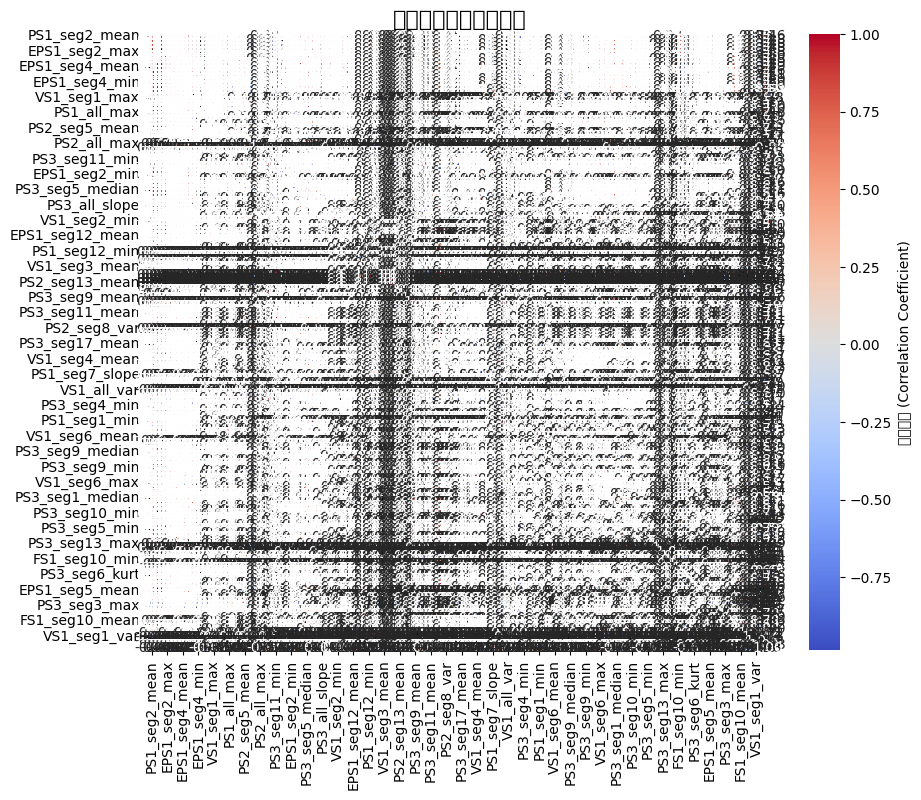


--- 相關性矩陣 ---
                PS1_seg2_mean  EPS1_seg3_max  ...  FS1_seg11_var  PS2_seg1_kurt
PS1_seg2_mean        1.000000       0.869672  ...       0.720492      -0.459800
EPS1_seg3_max        0.869672       1.000000  ...       0.720792      -0.480922
EPS1_all_max         0.871490       0.999442  ...       0.721272      -0.481316
EPS1_seg2_mean       0.876661       0.998764  ...       0.721522      -0.479836
EPS1_seg2_max        0.874778       0.998521  ...       0.721603      -0.481145
...                       ...            ...  ...            ...            ...
PS2_seg12_kurt      -0.492133      -0.549732  ...      -0.325463       0.223259
VS1_seg1_var        -0.252142      -0.351925  ...      -0.137367       0.134231
EPS1_seg2_var       -0.313933      -0.215434  ...      -0.165709       0.081307
FS1_seg11_var        0.720492       0.720792  ...       1.000000      -0.482321
PS2_seg1_kurt       -0.459800      -0.480922  ...      -0.482321       1.000000

[160 rows x 160 columns]

In [ ]:
# 定義最終目標特徵列表
target_list = target_cooler_feature_list

# 執行數據自動載入與合併
combined_cooler_features_df = load_and_combine_features_by_name(
    target_feature_list=target_list,
    base_dir='/content'
)

# 檢查合併的特徵資料表是否是空的
if not combined_cooler_features_df.empty:
    # 若不是空的，執行共線性分析與視覺化
    correlation_results = calculate_and_visualize_collinearity(combined_cooler_features_df)

    # 如果相關性分析的結果不是空的
    if correlation_results is not None:
        # 印出相關性矩陣
        print("\n--- 相關性矩陣 ---")
        print(correlation_results)

In [ ]:
# 執行共線性分析，閾值設定為 0.8
highly_collinear_combinations = high_collinearity_pairs(
    correlation_results,
    threshold=0.8
)

# 輸出共線性分析結果
if highly_collinear_combinations:
    print("--- 相關係數絕對值 > 0.8 的特徵組合 ---")
    # 印出相關性過高的特徵對
    for a, b, corr in highly_collinear_combinations:
        print(f"組合: ({a} vs {b}) | 相關係數: {corr:.4f} ({'正相關' if corr > 0 else '負相關'})")

# 若沒有相關性過高的特徵對
else:
    print(" 分析完成！沒有找到相關係數絕對值大於 0.8 的特徵組合。")

--- 相關係數絕對值 > 0.8 的特徵組合 ---
組合: (PS1_seg2_mean vs EPS1_seg3_max) | 相關係數: 0.8697 (正相關)
組合: (PS1_seg2_mean vs EPS1_all_max) | 相關係數: 0.8715 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg2_mean) | 相關係數: 0.8767 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg2_max) | 相關係數: 0.8748 (正相關)
組合: (PS1_seg2_mean vs PS2_seg10_var) | 相關係數: 0.9146 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg2_median) | 相關係數: 0.8742 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg4_median) | 相關係數: 0.8976 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg4_mean) | 相關係數: 0.8956 (正相關)
組合: (PS1_seg2_mean vs PS1_seg2_median) | 相關係數: 0.9986 (正相關)
組合: (PS1_seg2_mean vs PS1_all_min) | 相關係數: 0.9629 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg5_min) | 相關係數: 0.8961 (正相關)
組合: (PS1_seg2_mean vs EPS1_seg4_min) | 相關係數: 0.8959 (正相關)
組合: (PS1_seg2_mean vs EPS1_all_min) | 相關係數: 0.8959 (正相關)
組合: (PS1_seg2_mean vs PS1_seg4_min) | 相關係數: 0.9665 (正相關)
組合: (PS1_seg2_mean vs PS2_seg5_min) | 相關係數: 0.9614 (正相關)
組合: (PS1_seg2_mean vs PS1_seg4_mean) | 相關係數: 0.9713 (正相關)
組合: (PS1_seg2_mean vs PS1_seg4_median) |

In [ ]:
# 執行高共線性之特徵對的特徵篩選
try:
    # 取得建議刪除的名單
    drop_list = filter_features(
        correlation_results,
        'Cooler_spearman_correlation.csv',
        threshold=0.8
    )

    print(f"\n 篩選完成！")
    print(f" 共計刪除 {len(drop_list)} 個高共線性且表現較弱的特徵。")
    print(f" 刪除名單: {drop_list}")

# 當程式執行發生錯誤時，印出錯誤原因
except Exception as e:
    print(f" 執行出錯: {e}")

--- 開始基於 Spearman 相關係數進行篩選 (閾值: 0.8) ---
 組合 [PS1_seg2_mean vs EPS1_seg3_max]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg3_max (Score: 0.9308)
 組合 [PS1_seg2_mean vs EPS1_all_max]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_all_max (Score: 0.9308)
 組合 [PS1_seg2_mean vs EPS1_seg2_mean]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg2_mean (Score: 0.9307)
 組合 [PS1_seg2_mean vs EPS1_seg2_max]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg2_max (Score: 0.9306)
 組合 [PS1_seg2_mean vs PS2_seg10_var]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 PS2_seg10_var (Score: 0.9305)
 組合 [PS1_seg2_mean vs EPS1_seg2_median]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg2_median (Score: 0.9301)
 組合 [PS1_seg2_mean vs EPS1_seg4_median]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg4_median (Score: 0.9300)
 組合 [PS1_seg2_mean vs EPS1_seg4_mean]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 EPS1_seg4_mean (Score: 0.9299)
 組合 [PS1_seg2_mean vs PS1_seg2_median]: 保留 PS1_seg2_mean (Score: 0.9315), 剔除 PS1_seg2_median (Score: 0.92

In [ ]:
# 特徵篩選後保留的特徵
cooler_remaining_features = [f for f in target_cooler_feature_list if f not in drop_list]

# 印出特徵篩選結果
print(f"--- 最終保留的特徵列表 (共 {len(cooler_remaining_features)} 個) ---")
# enumerate(): 把清單變成一個「索引 + 數值」的組合 (編號從 1 開始)
for i, feat in enumerate(cooler_remaining_features, 1):
    print(f"{i}. {feat}")

--- 最終保留的特徵列表 (共 13 個) ---
1. PS1_seg2_mean
2. VS1_seg1_max
3. PS2_all_max
4. PS2_seg3_max
5. PS2_seg8_var
6. PS3_seg6_var
7. FS1_seg14_var
8. FS1_seg6_var
9. PS2_seg9_slope
10. PS3_seg6_skew
11. FS1_seg3_skew
12. PS2_seg12_kurt
13. EPS1_seg2_var


In [ ]:
# 建立僅含保留特徵的 DataFrame 以供建模
cooler_remaining_features_df = pd.DataFrame(cooler_remaining_features, columns=['remaining features'])

print(cooler_remaining_features_df)

   remaining features
0       PS1_seg2_mean
1        VS1_seg1_max
2         PS2_all_max
3        PS2_seg3_max
4        PS2_seg8_var
5        PS3_seg6_var
6       FS1_seg14_var
7        FS1_seg6_var
8      PS2_seg9_slope
9       PS3_seg6_skew
10      FS1_seg3_skew
11     PS2_seg12_kurt
12      EPS1_seg2_var


### Valve condition

In [ ]:
# 將 DataFrame 中特定的 Column (特徵名稱欄位) 轉換為 Numpy Array
target_valve_feature_list = df_valve_feature_above[0].to_numpy()
target_valve_feature_list

array(['PS2_seg3_mean', 'PS2_seg3_skew', 'EPS1_seg3_skew', 'PS3_seg4_max',
       'PS1_seg3_slope', 'PS3_seg4_slope', 'PS1_seg3_var',
       'PS3_seg3_mean', 'PS3_seg4_var', 'FS1_seg5_slope', 'PS2_seg4_max',
       'PS1_seg3_mean', 'PS1_seg3_kurt', 'PS2_seg3_min', 'PS2_seg4_slope',
       'PS2_seg4_var', 'PS1_seg3_skew', 'PS1_seg3_median',
       'EPS1_seg3_median', 'EPS1_seg4_var', 'PS1_seg2_kurt',
       'PS3_seg3_slope', 'PS2_all_kurt', 'FS1_seg4_min', 'PS2_all_skew',
       'PS3_seg3_skew', 'PS1_seg2_skew', 'PS3_seg4_mean', 'PS2_seg5_var',
       'FS1_seg4_mean', 'PS2_seg3_slope', 'PS2_seg4_mean', 'PS2_seg3_var',
       'PS2_seg3_kurt', 'PS1_seg4_var', 'PS2_seg4_median', 'PS1_seg3_max',
       'PS3_seg3_median', 'EPS1_seg3_mean', 'EPS1_seg4_slope',
       'PS2_seg3_median', 'PS2_seg5_skew'], dtype=object)

--- 解析特徵名稱並載入數據 ---
 > 成功載入檔案: /content/PS2_features.csv
 > 成功擷取欄位: seg3_mean，將命名為: PS2_seg3_mean
 > 成功擷取欄位: seg3_skew，將命名為: PS2_seg3_skew
 > 成功載入檔案: /content/EPS1_features.csv
 > 成功擷取欄位: seg3_skew，將命名為: EPS1_seg3_skew
 > 成功載入檔案: /content/PS3_features.csv
 > 成功擷取欄位: seg4_max，將命名為: PS3_seg4_max
 > 成功載入檔案: /content/PS1_features.csv
 > 成功擷取欄位: seg3_slope，將命名為: PS1_seg3_slope
 > 成功擷取欄位: seg4_slope，將命名為: PS3_seg4_slope
 > 成功擷取欄位: seg3_var，將命名為: PS1_seg3_var
 > 成功擷取欄位: seg3_mean，將命名為: PS3_seg3_mean
 > 成功擷取欄位: seg4_var，將命名為: PS3_seg4_var
 > 成功載入檔案: /content/FS1_features.csv
 > 成功擷取欄位: seg5_slope，將命名為: FS1_seg5_slope
 > 成功擷取欄位: seg4_max，將命名為: PS2_seg4_max
 > 成功擷取欄位: seg3_mean，將命名為: PS1_seg3_mean
 > 成功擷取欄位: seg3_kurt，將命名為: PS1_seg3_kurt
 > 成功擷取欄位: seg3_min，將命名為: PS2_seg3_min
 > 成功擷取欄位: seg4_slope，將命名為: PS2_seg4_slope
 > 成功擷取欄位: seg4_var，將命名為: PS2_seg4_var
 > 成功擷取欄位: seg3_skew，將命名為: PS1_seg3_skew
 > 成功擷取欄位: seg3_median，將命名為: PS1_seg3_median
 > 成功擷取欄位: seg3_median，將命名為: EPS1_seg3_median
 > 成功擷取欄位

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24501 (\N{C

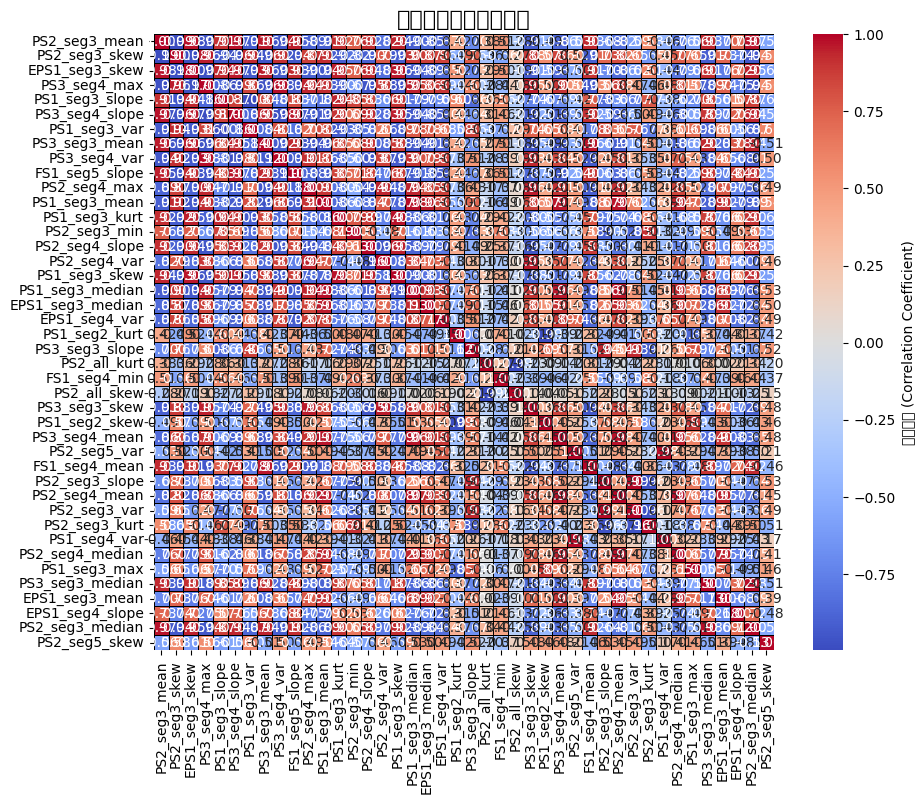


--- 相關性矩陣 ---
                  PS2_seg3_mean  PS2_seg3_skew  ...  PS2_seg3_median  PS2_seg5_skew
PS2_seg3_mean          1.000000      -0.989463  ...         0.970267      -0.564733
PS2_seg3_skew         -0.989463       1.000000  ...        -0.940267       0.584832
EPS1_seg3_skew         0.976224      -0.981243  ...         0.946620      -0.605220
PS3_seg4_max          -0.970785       0.958045  ...        -0.943020       0.557023
PS1_seg3_slope         0.909874      -0.936601  ...         0.869768      -0.613762
PS3_seg4_slope         0.972543      -0.961997  ...         0.942435      -0.558828
PS1_seg3_var          -0.911207       0.937086  ...        -0.872742       0.595536
PS3_seg3_mean          0.958555      -0.957690  ...         0.937627      -0.514590
PS3_seg4_var          -0.942848       0.919249  ...        -0.912034       0.495622
FS1_seg5_slope         0.948170      -0.944749  ...         0.917615      -0.562126
PS2_seg4_max          -0.886944       0.870091  ...        -0

In [ ]:
# 定義最終目標特徵列表
target_list = target_valve_feature_list

# 執行數據自動載入與合併
combined_valve_features_df = load_and_combine_features_by_name(
    target_feature_list=target_list,
    base_dir='/content'
)

# 檢查合併的特徵資料表是否是空的
if not combined_valve_features_df.empty:
    # 若不是空的，執行共線性分析與視覺化
    correlation_results = calculate_and_visualize_collinearity(combined_valve_features_df)

    # 如果相關性分析的結果不是空的
    if correlation_results is not None:
        # 印出相關性矩陣
        print("\n--- 相關性矩陣 ---")
        print(correlation_results)

In [ ]:
# 執行共線性分析，閾值設定為 0.8
highly_collinear_combinations = high_collinearity_pairs(
    correlation_results,
    threshold=0.8
)

# 輸出共線性分析結果
if highly_collinear_combinations:
    print("--- 相關係數絕對值 > 0.8 的特徵組合 ---")
    # 印出相關性過高的特徵對
    for a, b, corr in highly_collinear_combinations:
        print(f"組合: ({a} vs {b}) | 相關係數: {corr:.4f} ({'正相關' if corr > 0 else '負相關'})")

# 若沒有相關性過高的特徵對
else:
    print(" 分析完成！沒有找到相關係數絕對值大於 0.8 的特徵組合。")

--- 相關係數絕對值 > 0.8 的特徵組合 ---
組合: (PS2_seg3_mean vs PS2_seg3_skew) | 相關係數: -0.9895 (負相關)
組合: (PS2_seg3_mean vs EPS1_seg3_skew) | 相關係數: 0.9762 (正相關)
組合: (PS2_seg3_mean vs PS3_seg4_max) | 相關係數: -0.9708 (負相關)
組合: (PS2_seg3_mean vs PS1_seg3_slope) | 相關係數: 0.9099 (正相關)
組合: (PS2_seg3_mean vs PS3_seg4_slope) | 相關係數: 0.9725 (正相關)
組合: (PS2_seg3_mean vs PS1_seg3_var) | 相關係數: -0.9112 (負相關)
組合: (PS2_seg3_mean vs PS3_seg3_mean) | 相關係數: 0.9586 (正相關)
組合: (PS2_seg3_mean vs PS3_seg4_var) | 相關係數: -0.9428 (負相關)
組合: (PS2_seg3_mean vs FS1_seg5_slope) | 相關係數: 0.9482 (正相關)
組合: (PS2_seg3_mean vs PS2_seg4_max) | 相關係數: -0.8869 (負相關)
組合: (PS2_seg3_mean vs PS1_seg3_mean) | 相關係數: -0.9088 (負相關)
組合: (PS2_seg3_mean vs PS1_seg3_kurt) | 相關係數: 0.9218 (正相關)
組合: (PS2_seg3_mean vs PS2_seg4_slope) | 相關係數: 0.9158 (正相關)
組合: (PS2_seg3_mean vs PS2_seg4_var) | 相關係數: -0.8154 (負相關)
組合: (PS2_seg3_mean vs PS1_seg3_skew) | 相關係數: 0.9416 (正相關)
組合: (PS2_seg3_mean vs PS1_seg3_median) | 相關係數: -0.9043 (負相關)
組合: (PS2_seg3_mean vs EPS1_seg3_me

In [ ]:
# 執行高共線性之特徵對的特徵篩選
try:
    # 取得建議刪除的名單
    drop_list = filter_features(
        correlation_results,
        'Valve_spearman_correlation.csv',
        threshold=0.8
    )

    print(f"\n 篩選完成！")
    print(f" 共計刪除 {len(drop_list)} 個高共線性且表現較弱的特徵。")
    print(f" 刪除名單: {drop_list}")

# 當程式執行發生錯誤時，印出錯誤原因
except Exception as e:
    print(f" 執行出錯: {e}")

--- 開始基於 Spearman 相關係數進行篩選 (閾值: 0.8) ---
 組合 [PS2_seg3_mean vs PS2_seg3_skew]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS2_seg3_skew (Score: 0.9242)
 組合 [PS2_seg3_mean vs EPS1_seg3_skew]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 EPS1_seg3_skew (Score: 0.9225)
 組合 [PS2_seg3_mean vs PS3_seg4_max]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS3_seg4_max (Score: 0.9153)
 組合 [PS2_seg3_mean vs PS1_seg3_slope]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS1_seg3_slope (Score: 0.9137)
 組合 [PS2_seg3_mean vs PS3_seg4_slope]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS3_seg4_slope (Score: 0.9106)
 組合 [PS2_seg3_mean vs PS1_seg3_var]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS1_seg3_var (Score: 0.9092)
 組合 [PS2_seg3_mean vs PS3_seg3_mean]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS3_seg3_mean (Score: 0.9030)
 組合 [PS2_seg3_mean vs PS3_seg4_var]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 PS3_seg4_var (Score: 0.8917)
 組合 [PS2_seg3_mean vs FS1_seg5_slope]: 保留 PS2_seg3_mean (Score: 0.9242), 剔除 FS1_seg5_slope (Score: 0.8825)
 組合 [PS2_seg

In [ ]:
# 特徵篩選後保留的特徵
valve_remaining_features = [f for f in target_valve_feature_list if f not in drop_list]

# 印出特徵篩選結果
print(f"--- 最終保留的特徵列表 (共 {len(valve_remaining_features)} 個) ---")
# enumerate(): 把清單變成一個「索引 + 數值」的組合 (編號從 1 開始)
for i, feat in enumerate(valve_remaining_features, 1):
    print(f"{i}. {feat}")

--- 最終保留的特徵列表 (共 6 個) ---
1. PS2_seg3_mean
2. PS1_seg2_kurt
3. PS2_all_kurt
4. FS1_seg4_min
5. PS2_seg5_var
6. PS2_seg5_skew


In [ ]:
# 建立僅含保留特徵的 DataFrame 以供建模
valve_remaining_features_df = pd.DataFrame(valve_remaining_features, columns=['remaining features'])

print(valve_remaining_features_df)

  remaining features
0      PS2_seg3_mean
1      PS1_seg2_kurt
2       PS2_all_kurt
3       FS1_seg4_min
4       PS2_seg5_var
5      PS2_seg5_skew


### Pump condition

In [ ]:
# 將 DataFrame 中特定的 Column (特徵名稱欄位) 轉換為 Numpy Array
target_pump_feature_list = df_pump_feature_above[0].to_numpy()
target_pump_feature_list

array(['FS1_all_skew', 'PS2_seg8_kurt', 'PS3_seg12_min', 'EPS1_all_mean',
       'PS3_seg12_max'], dtype=object)

--- 解析特徵名稱並載入數據 ---
 > 成功載入檔案: /content/FS1_features.csv
 > 成功擷取欄位: all_skew，將命名為: FS1_all_skew
 > 成功載入檔案: /content/PS2_features.csv
 > 成功擷取欄位: seg8_kurt，將命名為: PS2_seg8_kurt
 > 成功載入檔案: /content/PS3_features.csv
 > 成功擷取欄位: seg12_min，將命名為: PS3_seg12_min
 > 成功載入檔案: /content/EPS1_features.csv
 > 成功擷取欄位: all_mean，將命名為: EPS1_all_mean
 > 成功擷取欄位: seg12_max，將命名為: PS3_seg12_max

 合併與清理完成。最終數據形狀: (2205, 5)

--- 計算相關性矩陣與熱力圖視覺化 ---


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24501 (\N{C

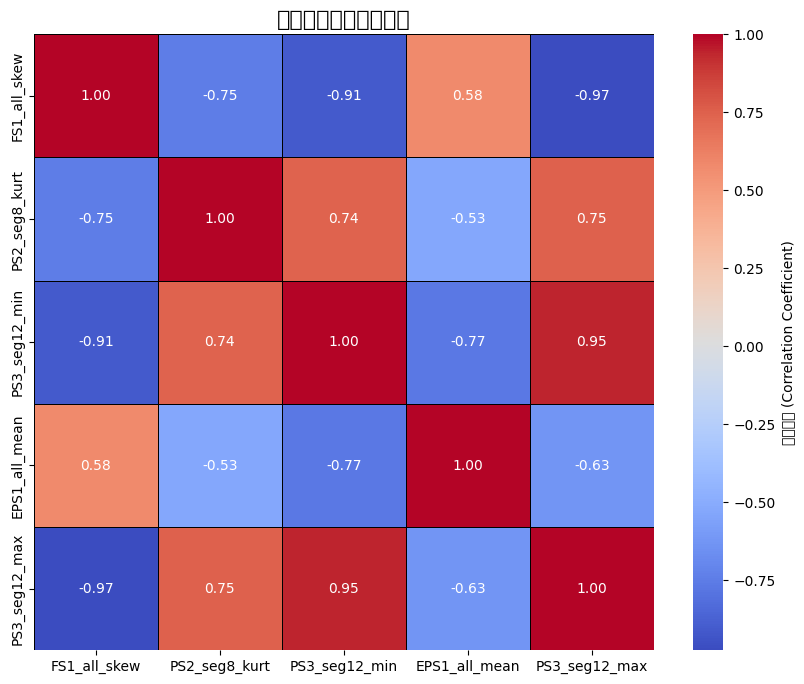


--- 相關性矩陣 ---
               FS1_all_skew  PS2_seg8_kurt  ...  EPS1_all_mean  PS3_seg12_max
FS1_all_skew       1.000000      -0.747392  ...       0.580875      -0.974567
PS2_seg8_kurt     -0.747392       1.000000  ...      -0.532926       0.752065
PS3_seg12_min     -0.906755       0.742098  ...      -0.773883       0.945727
EPS1_all_mean      0.580875      -0.532926  ...       1.000000      -0.630217
PS3_seg12_max     -0.974567       0.752065  ...      -0.630217       1.000000

[5 rows x 5 columns]


In [ ]:
# 定義最終目標特徵列表
target_list = target_pump_feature_list

# 執行數據自動載入與合併
combined_pump_features_df = load_and_combine_features_by_name(
    target_feature_list=target_list,
    base_dir='/content'
)

# 檢查合併的特徵資料表是否是空的
if not combined_pump_features_df.empty:
    # 若不是空的，執行共線性分析與視覺化
    correlation_results = calculate_and_visualize_collinearity(combined_pump_features_df)

    # 如果相關性分析的結果不是空的
    if correlation_results is not None:
        # 印出相關性矩陣
        print("\n--- 相關性矩陣 ---")
        print(correlation_results)

In [ ]:
# 執行共線性分析，閾值設定為 0.8
highly_collinear_combinations = high_collinearity_pairs(
    correlation_results,
    threshold=0.8
)

# 輸出共線性分析結果
if highly_collinear_combinations:
    print("--- 相關係數絕對值 > 0.8 的特徵組合 ---")
    # 印出相關性過高的特徵對
    for a, b, corr in highly_collinear_combinations:
        print(f"組合: ({a} vs {b}) | 相關係數: {corr:.4f} ({'正相關' if corr > 0 else '負相關'})")

# 若沒有相關性過高的特徵對
else:
    print(" 分析完成！沒有找到相關係數絕對值大於 0.8 的特徵組合。")

--- 相關係數絕對值 > 0.8 的特徵組合 ---
組合: (FS1_all_skew vs PS3_seg12_min) | 相關係數: -0.9068 (負相關)
組合: (FS1_all_skew vs PS3_seg12_max) | 相關係數: -0.9746 (負相關)
組合: (PS3_seg12_min vs PS3_seg12_max) | 相關係數: 0.9457 (正相關)


In [ ]:
# 執行高共線性之特徵對的特徵篩選
try:
    # 取得建議刪除的名單
    drop_list = filter_features(
        correlation_results,
        'Pump_spearman_correlation.csv',
        threshold=0.8
    )

    print(f"\n 篩選完成！")
    print(f" 共計刪除 {len(drop_list)} 個高共線性且表現較弱的特徵。")
    print(f" 刪除名單: {drop_list}")

# 當程式執行發生錯誤時，印出錯誤原因
except Exception as e:
    print(f" 執行出錯: {e}")

--- 開始基於 Spearman 相關係數進行篩選 (閾值: 0.8) ---
 組合 [FS1_all_skew vs PS3_seg12_min]: 保留 FS1_all_skew (Score: 0.5983), 剔除 PS3_seg12_min (Score: 0.5235)
 組合 [FS1_all_skew vs PS3_seg12_max]: 保留 FS1_all_skew (Score: 0.5983), 剔除 PS3_seg12_max (Score: 0.4987)

 篩選完成！
 共計刪除 2 個高共線性且表現較弱的特徵。
 刪除名單: ['PS3_seg12_min', 'PS3_seg12_max']


In [ ]:
# 特徵篩選後保留的特徵
pump_remaining_features = [f for f in target_pump_feature_list if f not in drop_list]

# 印出特徵篩選結果
print(f"--- 最終保留的特徵列表 (共 {len(pump_remaining_features)} 個) ---")
# enumerate(): 把清單變成一個「索引 + 數值」的組合 (編號從 1 開始)
for i, feat in enumerate(pump_remaining_features, 1):
    print(f"{i}. {feat}")

--- 最終保留的特徵列表 (共 3 個) ---
1. FS1_all_skew
2. PS2_seg8_kurt
3. EPS1_all_mean


In [ ]:
# 建立僅含保留特徵的 DataFrame 以供建模
pump_remaining_features_df = pd.DataFrame(pump_remaining_features, columns=['remaining features'])

print(pump_remaining_features_df)

  remaining features
0       FS1_all_skew
1      PS2_seg8_kurt
2      EPS1_all_mean


### Accumulator condition

In [ ]:
# 將 DataFrame 中特定的 Column (特徵名稱欄位) 轉換為 Numpy Array
target_accumulator_feature_list = df_accumulator_feature_above[0].to_numpy()
target_accumulator_feature_list

array(['EPS1_seg1_var', 'EPS1_seg1_slope', 'PS1_seg10_var'], dtype=object)

--- 解析特徵名稱並載入數據 ---
 > 成功載入檔案: /content/EPS1_features.csv
 > 成功擷取欄位: seg1_var，將命名為: EPS1_seg1_var
 > 成功擷取欄位: seg1_slope，將命名為: EPS1_seg1_slope
 > 成功載入檔案: /content/PS1_features.csv
 > 成功擷取欄位: seg10_var，將命名為: PS1_seg10_var

 合併與清理完成。最終數據形狀: (2205, 3)

--- 計算相關性矩陣與熱力圖視覺化 ---


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24501 (\N{C

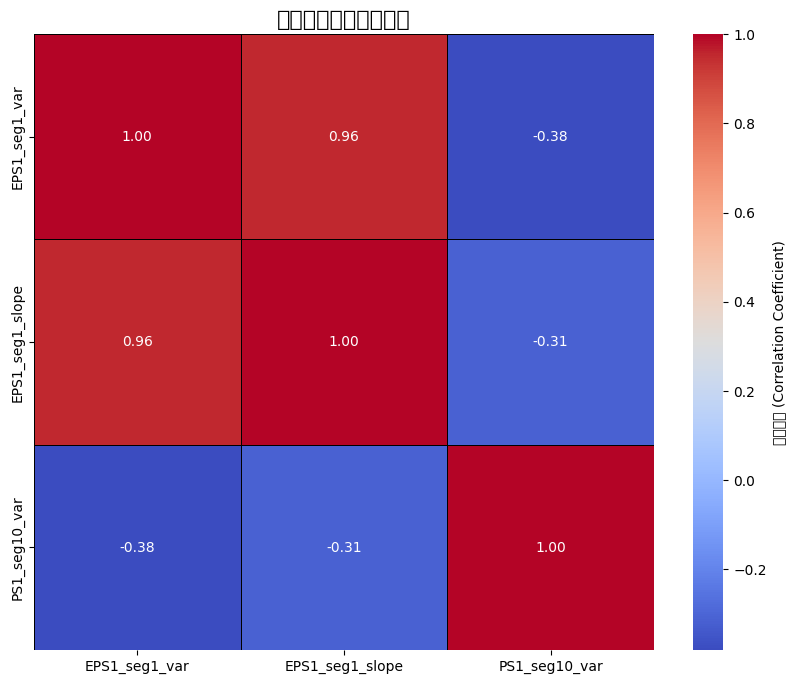


--- 相關性矩陣 ---
                 EPS1_seg1_var  EPS1_seg1_slope  PS1_seg10_var
EPS1_seg1_var         1.000000         0.956302      -0.381329
EPS1_seg1_slope       0.956302         1.000000      -0.314282
PS1_seg10_var        -0.381329        -0.314282       1.000000


In [ ]:
# 定義最終目標特徵列表
target_list = target_accumulator_feature_list

# 執行數據自動載入與合併
combined_accumulator_features_df = load_and_combine_features_by_name(
    target_feature_list=target_list,
    base_dir='/content'
)

# 檢查合併的特徵資料表是否是空的
if not combined_accumulator_features_df.empty:
    # 若不是空的，執行共線性分析與視覺化
    correlation_results = calculate_and_visualize_collinearity(combined_accumulator_features_df)

    # 如果相關性分析的結果不是空的
    if correlation_results is not None:
        # 印出相關性矩陣
        print("\n--- 相關性矩陣 ---")
        print(correlation_results)

In [ ]:
# 執行共線性分析，閾值設定為 0.8
highly_collinear_combinations = high_collinearity_pairs(
    correlation_results,
    threshold=0.8
)

# 輸出共線性分析結果
if highly_collinear_combinations:
    print("--- 相關係數絕對值 > 0.8 的特徵組合 ---")
    # 印出相關性過高的特徵對
    for a, b, corr in highly_collinear_combinations:
        print(f"組合: ({a} vs {b}) | 相關係數: {corr:.4f} ({'正相關' if corr > 0 else '負相關'})")

# 若沒有相關性過高的特徵對
else:
    print(" 分析完成！沒有找到相關係數絕對值大於 0.8 的特徵組合。")

--- 相關係數絕對值 > 0.8 的特徵組合 ---
組合: (EPS1_seg1_var vs EPS1_seg1_slope) | 相關係數: 0.9563 (正相關)


In [ ]:
# 執行高共線性之特徵對的特徵篩選
try:
    # 取得建議刪除的名單
    drop_list = filter_features(
        correlation_results,
        'Accumulator_spearman_correlation.csv',
        threshold=0.8
    )

    print(f"\n 篩選完成！")
    print(f" 共計刪除 {len(drop_list)} 個高共線性且表現較弱的特徵。")
    print(f" 刪除名單: {drop_list}")

# 當程式執行發生錯誤時，印出錯誤原因
except Exception as e:
    print(f" 執行出錯: {e}")

--- 開始基於 Spearman 相關係數進行篩選 (閾值: 0.8) ---
 組合 [EPS1_seg1_var vs EPS1_seg1_slope]: 保留 EPS1_seg1_var (Score: 0.7886), 剔除 EPS1_seg1_slope (Score: 0.7751)

 篩選完成！
 共計刪除 1 個高共線性且表現較弱的特徵。
 刪除名單: ['EPS1_seg1_slope']


In [ ]:
# 特徵篩選後保留的特徵
accumulator_remaining_features = [f for f in target_accumulator_feature_list if f not in drop_list]

# 印出特徵篩選結果
print(f"--- 最終保留的特徵列表 (共 {len(accumulator_remaining_features)} 個) ---")
# enumerate(): 把清單變成一個「索引 + 數值」的組合 (編號從 1 開始)
for i, feat in enumerate(accumulator_remaining_features, 1):
    print(f"{i}. {feat}")

--- 最終保留的特徵列表 (共 2 個) ---
1. EPS1_seg1_var
2. PS1_seg10_var


In [ ]:
# 建立僅含保留特徵的 DataFrame 以供建模
accumulator_remaining_features_df = pd.DataFrame(accumulator_remaining_features, columns=['remaining features'])

print(accumulator_remaining_features_df)

  remaining features
0      EPS1_seg1_var
1      PS1_seg10_var


# 模型訓練 & 五折交叉驗證

1.   透過五折交叉驗證檢驗模型是否真的有學到所有可能的 cycle
2.   藉由平均指標 (mean accuracy、recall) 作為模型挑選的基準，最終選定使用 XGBoost 模型



In [ ]:
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [ ]:
# 讀取 profile.txt 檔案 (\t 代表欄位之間用 Tab 分隔， header=None 代表沒有標題列)
profiles = pd.read_csv('raw_data/profile.txt', sep='\t', header=None)

# 定義欄位名稱
profiles.columns = ['cooler', 'valve', 'pump', 'accumulator', 'stable']

## Cooler condition

資料準備

In [ ]:
# # coverage 檢查參數
# LOWCONF_K = 50          # 列出信心最低前 50 筆
# LOWCONF_THRESH = 0.60   # max prob < 0.60 視為低信心（可自行調）
# OUTLIER_FRAC = 0.02     # IsolationForest 預期 2% outliers（可自行調）

# OUT_XLSX = "coverage_report.xlsx"

In [ ]:
# 篩選特徵欄位
X = combined_cooler_features_df[cooler_remaining_features]

# 印出篩選特徵欄位結果
print(f"已成功提取特徵數據 X，形狀為: {X.shape}")
print(X.head())

已成功提取特徵數據 X，形狀為: (2205, 13)
   PS1_seg2_mean  VS1_seg1_max  ...  PS2_seg12_kurt  EPS1_seg2_var
0     190.314857         0.619  ...        1.700766    2680.481277
1     191.248990         0.626  ...        2.362515      12.623787
2     191.174086         0.662  ...        2.065666      14.177935
3     191.115131         0.645  ...        1.634690      18.172381
4     191.070000         0.660  ...        3.170047      22.494750

[5 rows x 13 columns]


In [ ]:
# 從 profile 中提取目標變數
try:
    # 提取 cooler 欄位作為 target (y)
    y = profiles['cooler']

    # 印出提取結果
    print("成功匯入目標數據！")
    print(f"資料筆數: {len(y)}")
    print("\nCooler 狀態的分佈狀況 (數值代表不同的損壞程度):")
    print(y.value_counts().sort_index())

    # 將其轉換為 DataFrame 格式以便後續操作
    target_df = pd.DataFrame(y)

# 當程式執行發生錯誤時，印出錯誤原因
except FileNotFoundError:
    print("錯誤：找不到 profile.txt 檔案，請確認檔案路徑是否正確。")

成功匯入目標數據！
資料筆數: 2205

Cooler 狀態的分佈狀況 (數值代表不同的損壞程度):
cooler
3      732
20     732
100    741
Name: count, dtype: int64


In [ ]:
# 將 y 中的資料型態轉換為整數
y = y.astype(int)

### Logistic Regression


Train size: 1764
Test size : 441


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


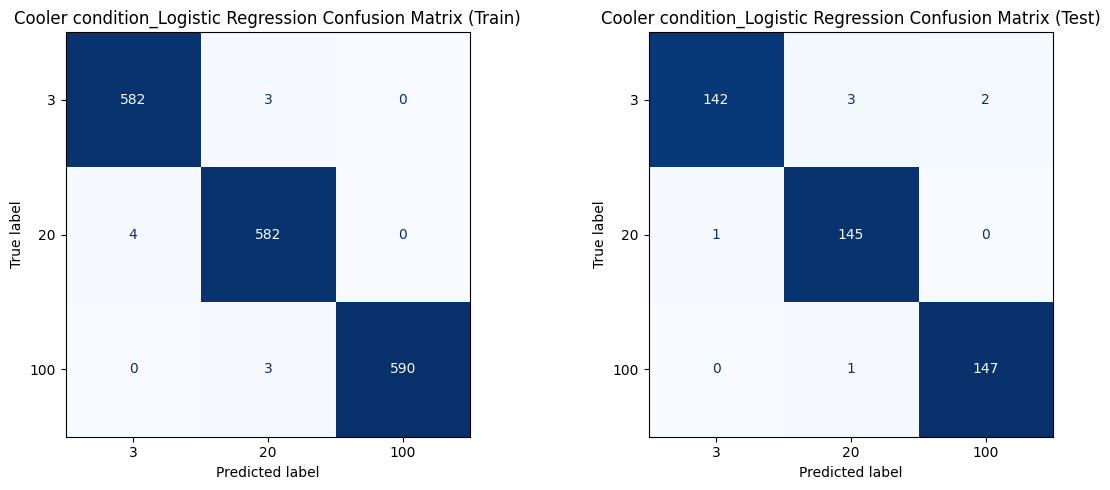


=== Train Classification Report ===
              precision    recall  f1-score   support

           3     0.9932    0.9949    0.9940       585
          20     0.9898    0.9932    0.9915       586
         100     1.0000    0.9949    0.9975       593

    accuracy                         0.9943      1764
   macro avg     0.9943    0.9943    0.9943      1764
weighted avg     0.9943    0.9943    0.9943      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           3     0.9930    0.9660    0.9793       147
          20     0.9732    0.9932    0.9831       146
         100     0.9866    0.9932    0.9899       148

    accuracy                         0.9841       441
   macro avg     0.9842    0.9841    0.9841       441
weighted avg     0.9843    0.9841    0.9841       441



In [ ]:
# 準備資料與標準化
# 數據標準化 (邏輯迴歸對數值極度敏感)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立模型
'''
multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
solver='lbfgs': lbfgs 是一種二階優化演算法
max_iter: 最大迭代次數
'''
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# 訓練模型
Cooler_log_reg_model = log_reg.fit(X_train, y_train)

# 預測
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Cooler condition_Logistic Regression Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Cooler condition_Logistic Regression Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立模型
    '''
    multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
    solver='lbfgs': lbfgs 是一種二階優化演算法
    max_iter: 最大迭代次數
    '''
    log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

    # 訓練模型
    Cooler_log_reg_model = log_reg.fit(X_train, y_train)

    # 預測
    y_pred = log_reg.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Logistic Regression) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9864
precision: 0.9864
recall: 0.9864
f1-score: 0.9864

--- Fold 2 ---
Accuracy: 0.9887
precision: 0.9887
recall: 0.9887
f1-score: 0.9887

--- Fold 3 ---
Accuracy: 0.9909
precision: 0.9909
recall: 0.9909
f1-score: 0.9909

--- Fold 4 ---
Accuracy: 0.9909
precision: 0.9909
recall: 0.9909
f1-score: 0.9909

--- Fold 5 ---
Accuracy: 0.9932
precision: 0.9932
recall: 0.9932
f1-score: 0.9932

=== 5-Fold Cross-Validation Summary (Logistic Regression) ===
Mean Accuracy: 0.9900
Std  Accuracy: 0.0023


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### SVM


Train size: 1764
Test size : 441


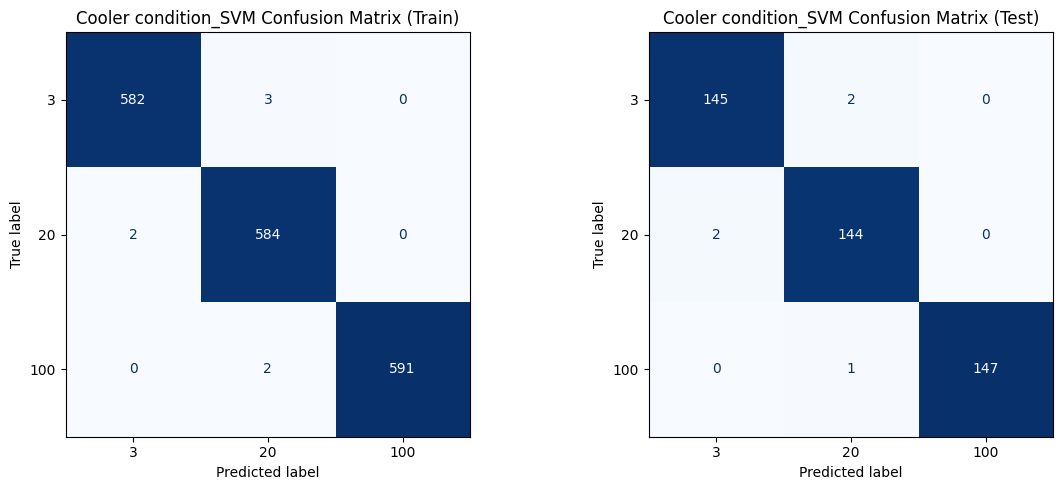


=== Train Classification Report ===
              precision    recall  f1-score   support

           3     0.9966    0.9949    0.9957       585
          20     0.9915    0.9966    0.9940       586
         100     1.0000    0.9966    0.9983       593

    accuracy                         0.9960      1764
   macro avg     0.9960    0.9960    0.9960      1764
weighted avg     0.9960    0.9960    0.9960      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           3     0.9864    0.9864    0.9864       147
          20     0.9796    0.9863    0.9829       146
         100     1.0000    0.9932    0.9966       148

    accuracy                         0.9887       441
   macro avg     0.9887    0.9886    0.9886       441
weighted avg     0.9887    0.9887    0.9887       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


# 建立 SVM 模型(SVM with RBF)
'''
kernel='rbf': 使用徑向基函數
C: 懲罰參數（越高代表對錯誤容忍度越低）
gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
'''
svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

# 訓練 SVM 模型
Cooler_svm_model = svm_model.fit(X_train, y_train)

# 預測
y_train_pred = svm_model.predict(X_train)
y_test_pred  = svm_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Cooler condition_SVM Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Cooler condition_SVM Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立 SVM 模型(SVM with RBF)
    '''
    kernel='rbf': 使用徑向基函數
    C: 懲罰參數（越高代表對錯誤容忍度越低）
    gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
    '''
    svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

    # 訓練 SVM 模型
    Cooler_svm_model = svm_model.fit(X_train, y_train)

    # 預測
    y_pred = svm_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (SVM) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9841
precision: 0.9841
recall: 0.9841
f1-score: 0.9841

--- Fold 2 ---
Accuracy: 0.9887
precision: 0.9887
recall: 0.9887
f1-score: 0.9887

--- Fold 3 ---
Accuracy: 0.9932
precision: 0.9932
recall: 0.9932
f1-score: 0.9932

--- Fold 4 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 5 ---
Accuracy: 0.9932
precision: 0.9932
recall: 0.9932
f1-score: 0.9932

=== 5-Fold Cross-Validation Summary (SVM) ===
Mean Accuracy: 0.9909
Std  Accuracy: 0.0041


### XGBoost


Train size: 1764
Test size : 441


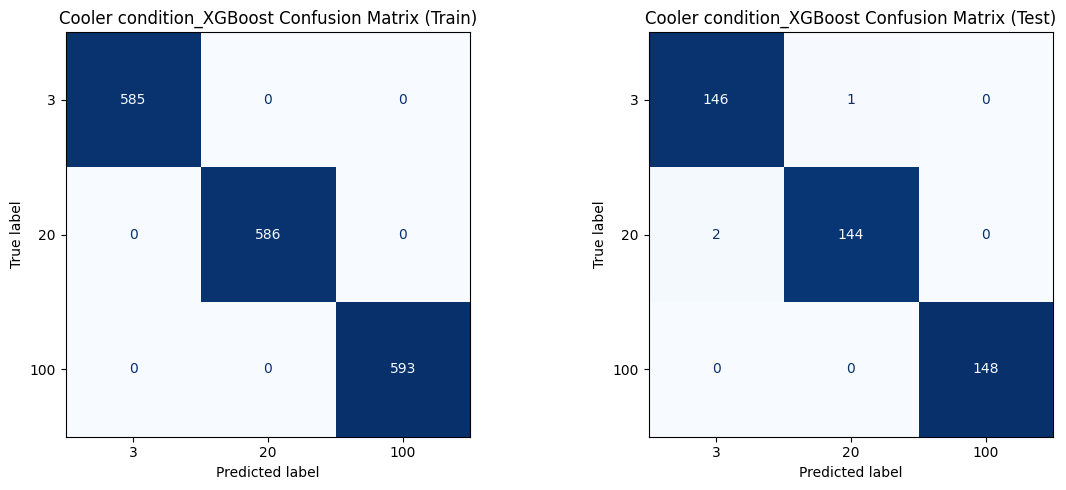


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       585
           1     1.0000    1.0000    1.0000       586
           2     1.0000    1.0000    1.0000       593

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9865    0.9932    0.9898       147
           1     0.9931    0.9863    0.9897       146
           2     1.0000    1.0000    1.0000       148

    accuracy                         0.9932       441
   macro avg     0.9932    0.9932    0.9932       441
weighted avg     0.9932    0.9932    0.9932       441



In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y, random_state=42)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立 XGBoost 模型
'''
n_estimators: 樹的數量
learning_rate: 學習率 (步長)
max_depth: 每棵樹的最大深度
objective='multi:softprob': 多分類問題
'''
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softprob'
)

# 訓練 XGBoost 模型
Cooler_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的數值 (0, 1, 2, 3) 轉回原本數值 (73, 80, 90, 100)
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Cooler condition_XGBoost Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Cooler condition_XGBoost Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # 建立 XGBoost 模型
    '''
    n_estimators: 樹的數量
    learning_rate: 學習率 (步長)
    max_depth: 每棵樹的最大深度
    objective='multi:softprob': 多分類問題
    '''
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

    # 訓練 XGBoost 模型
    Cooler_xgb_model = xgb_model.fit(X_train, y_train)

    # 預測
    y_pred = xgb_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 2 ---
Accuracy: 0.9887
precision: 0.9887
recall: 0.9887
f1-score: 0.9887

--- Fold 3 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 4 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 5 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

=== 5-Fold Cross-Validation Summary (XGBoost) ===
Mean Accuracy: 0.9959
Std  Accuracy: 0.0039


最終模型訓練


Train size: 1764
Test size : 441


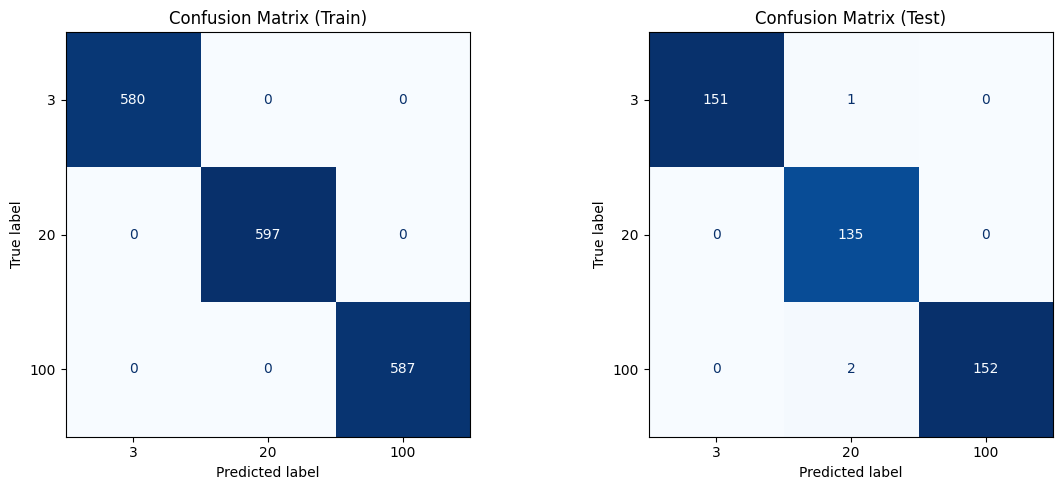


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       580
           1     1.0000    1.0000    1.0000       597
           2     1.0000    1.0000    1.0000       587

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    0.9934    0.9967       152
           1     0.9783    1.0000    0.9890       135
           2     1.0000    0.9870    0.9935       154

    accuracy                         0.9932       441
   macro avg     0.9928    0.9935    0.9931       441
weighted avg     0.9933    0.9932    0.9932       441


--- Fold 1 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 2 ---
Accuracy: 0.9887
precision: 0.9887
recall: 0.9887
f1-score: 0.9887

In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ====== 用特定 index 切分（取代 train_test_split） ======
N = 2205  # 總筆數(0-2204)

test_idx_raw = [1966, 1091, 1468, 438, 1790, 1953, 752, 408, 1477, 2037, 1732, 495, 2022, 1526, 985,
387, 1229, 426, 168, 1455, 1444, 351, 2150, 2115, 275, 528, 1261, 1989, 679, 29, 596, 281, 727, 1383,
2114, 1855, 1323, 432, 1566, 231, 1848, 2109, 2196, 111, 1489, 1023, 1897, 1601, 1822, 617, 1560, 873,
1466, 2190, 1151, 1683, 1928, 1840, 1518, 1708, 994, 1211, 1200, 134, 179, 96, 367, 680, 1414, 1842, 942,
321, 433, 2007, 585, 988, 2014, 360, 196, 1047, 427, 1263, 1313, 73, 233, 353, 2046, 332, 1891, 416, 2018,
1216, 1730, 1916, 361, 2155, 100, 1133, 1010, 2136, 1068, 368, 674, 70, 632, 414, 1653, 2122, 1915, 1533, 240,
2126, 1914, 383, 254, 1075, 1701, 1645, 109, 1910, 1650, 67, 1514, 1234, 1336, 561, 282, 1433, 1582, 668, 1596,
1037, 2056, 1769, 184, 1286, 906, 1204, 1131, 507, 1009, 251, 1473, 923, 1364, 1232, 135, 2063, 1952, 527, 247,
350, 1351, 1739, 1574, 867, 1795, 798, 1551, 128, 932, 1599, 1025, 1753, 1441, 51, 816, 693, 2008, 552, 1776,
599, 1810, 1745, 290, 1298, 1508, 486, 1249, 1979, 554, 1623, 382, 1463, 1283, 1451, 298, 2130, 636, 1949, 1660,
2188, 303, 1394, 1121, 756, 482, 188, 695, 792, 1085, 1033, 1532, 1357, 1611, 48, 1406, 218, 479, 943, 1859, 120,
2176, 211, 1736, 889, 56, 1905, 1618, 1828, 765, 289, 1908, 1187, 485, 1717, 535, 1228, 297, 1173, 1465, 259, 1886,
519, 1178, 1974, 1421, 1513, 1501, 44, 163, 1335, 2081, 1467, 192, 2011, 772, 694, 611, 1557, 1737, 618, 1222, 1379,
69, 634, 480, 1165, 230, 342, 1995, 963, 1767, 538, 976, 239, 99, 1950, 1809, 1210, 581, 1078, 1264, 1185, 812, 124,
1835, 185, 307, 1509, 65, 532, 406, 1677, 1412, 1561, 1805, 430, 1125, 729, 219, 1044, 1138, 1545, 1836, 212, 2108,
555, 1658, 1559, 1876, 841, 893, 529, 1800, 210, 1128, 299, 306, 1430, 707, 435, 1944, 220, 1555, 237, 808, 1544,
354, 1000, 1575, 1170, 324, 979, 445, 13, 1094, 296, 1786, 621, 1517, 1818, 1163, 1100, 1410, 1811, 1237, 1641, 1869,
900, 2180, 862, 1676, 203, 1161, 1343, 785, 478, 410, 2040, 316, 1973, 105, 1832, 121, 948, 2116, 2129, 1036, 1358,
788, 115, 76, 1742, 422, 1192, 2087, 2134, 715, 2096, 925, 1157, 941, 907, 993, 1584, 620, 420, 856, 1602, 859, 952,
178, 1827, 613, 767, 2181, 780, 1005, 651, 1017, 409, 1102, 781, 1941, 1389, 450, 1226, 1612, 886, 2086, 63, 508, 817,
2137, 916, 1057, 1292, 742, 1851, 1972, 1110, 1380, 1823, 471, 1593, 205, 530, 2072, 836, 1889, 1965, 1984, 2054, 1193,
23, 1870, 1958, 1084, 198, 49, 173, 1159, 1583, 2078, 308, 1314, 930, 1735, 59, 71
]

# 所有 index -1（轉成 0-based）
test_idx = np.array([i - 1 for i in test_idx_raw], dtype=int)

# 產生 train index（補集）
all_idx = np.arange(N)
train_idx = np.setdiff1d(all_idx, test_idx)

# 切分 X / y（保留你原本的資料型態：若 X, y 是 pandas 就用 .iloc；若是 numpy 就用 []）
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]  # 如果 y_encoded 是 numpy，改成 y_encoded[train_idx]

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立並訓練 XGBoost 模型
# use_label_encoder=False 是為了避免新版本的警告
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=5,        # 每棵樹的最大深度
    random_state=42,
    objective='multi:softprob' # 多分類問題
)

Cooler_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的 0,1,2,3 轉回 73, 80, 90, 100
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後將這些類別按升序排序
labels = sorted(y.unique())

# Confusion Matrices
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Train)")

ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.show()

# Classification reports
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

# ===== 5-fold stratified CV =====
# 重新編碼 y，確保 y_encoded 在當前作用域中
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 定義 make_xgb_model 函式
def make_xgb_model():
    return xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 修正 DataFrame 的索引方式，使用 .iloc
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = make_xgb_model()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    conf_matrices.append(cm)

    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")

### Random Forest Classifier


Train size: 1764
Test size : 441


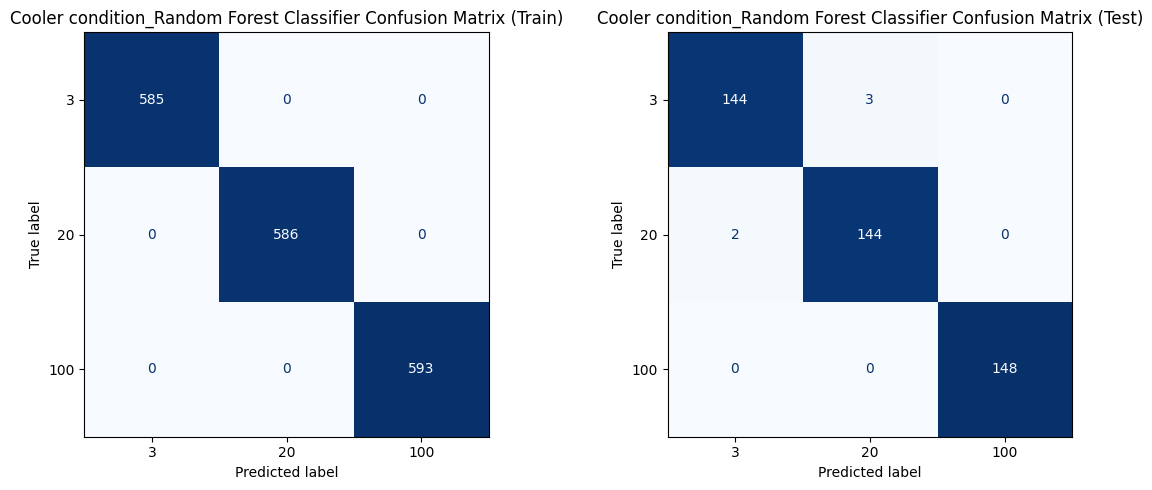


=== Train Classification Report ===
              precision    recall  f1-score   support

           3     1.0000    1.0000    1.0000       585
          20     1.0000    1.0000    1.0000       586
         100     1.0000    1.0000    1.0000       593

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           3     0.9863    0.9796    0.9829       147
          20     0.9796    0.9863    0.9829       146
         100     1.0000    1.0000    1.0000       148

    accuracy                         0.9887       441
   macro avg     0.9886    0.9886    0.9886       441
weighted avg     0.9887    0.9887    0.9887       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立隨機森林模型
'''
n_estimators: 樹的數量
max_depth: 每棵樹的最大深度
n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
'''
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# 訓練隨機森林模型
Cooler_rf_model = rf_model.fit(X_train, y_train)

# 預測
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Cooler condition_Random Forest Classifier Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Cooler condition_Random Forest Classifier Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立隨機森林模型
    '''
    n_estimators: 樹的數量
    max_depth: 每棵樹的最大深度
    n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
    '''
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        n_jobs=-1
    )

    # 訓練隨機森林模型
    Cooler_rf_model = rf_model.fit(X_train, y_train)

    # 預測
    y_pred = rf_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Random Forest) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 2 ---
Accuracy: 0.9887
precision: 0.9887
recall: 0.9887
f1-score: 0.9887

--- Fold 3 ---
Accuracy: 0.9932
precision: 0.9932
recall: 0.9932
f1-score: 0.9932

--- Fold 4 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 5 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

=== 5-Fold Cross-Validation Summary (Random Forest) ===
Mean Accuracy: 0.9937
Std  Accuracy: 0.0026


## Valve condition

資料準備

In [ ]:
# 篩選特徵欄位
X = combined_valve_features_df[valve_remaining_features]

# 印出篩選特徵欄位結果
print(f"已成功提取特徵數據 X，形狀為: {X.shape}")
print(X.head())

已成功提取特徵數據 X，形狀為: (2205, 6)
   PS2_seg3_mean  PS1_seg2_kurt  ...  PS2_seg5_var  PS2_seg5_skew
0     129.158263      23.336317  ...      0.051285       3.271726
1     129.291079     240.128169  ...      0.083118       2.694818
2     128.157237     243.999890  ...      0.105486       1.210813
3     127.890421     240.524253  ...      0.109146       1.004143
4     128.033211     241.855612  ...      0.100849       0.881212

[5 rows x 6 columns]


In [ ]:
# 從 profile 中提取目標變數
try:
    # 提取 valve 欄位作為 target (y)
    y = profiles['valve']

    # 印出提取結果
    print("成功匯入目標數據！")
    print(f"資料筆數: {len(y)}")
    print("\nValve 狀態的分佈狀況 (數值代表不同的損壞程度):")
    print(y.value_counts().sort_index())

    # 將其轉換為 DataFrame 格式以便後續操作
    target_df = pd.DataFrame(y)

# 當程式執行發生錯誤時，印出錯誤原因
except FileNotFoundError:
    print("錯誤：找不到 profile.txt 檔案，請確認檔案路徑是否正確。")

成功匯入目標數據！
資料筆數: 2205

Valve 狀態的分佈狀況 (數值代表不同的損壞程度):
valve
73      360
80      360
90      360
100    1125
Name: count, dtype: int64


In [ ]:
# 將 y 中的資料型態轉換為整數
y = y.astype(int)

### Logistic Regression


Train size: 1764
Test size : 441


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


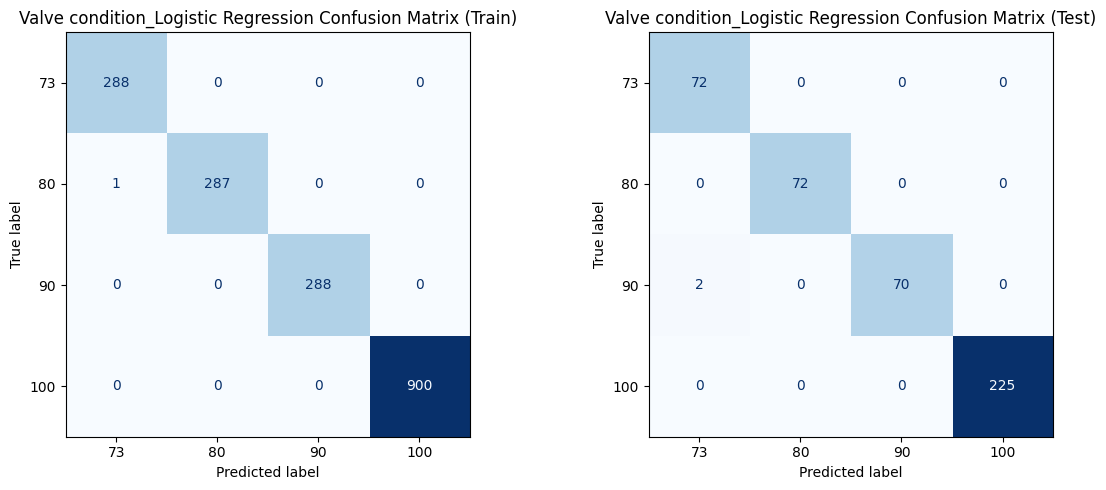


=== Train Classification Report ===
              precision    recall  f1-score   support

          73     0.9965    1.0000    0.9983       288
          80     1.0000    0.9965    0.9983       288
          90     1.0000    1.0000    1.0000       288
         100     1.0000    1.0000    1.0000       900

    accuracy                         0.9994      1764
   macro avg     0.9991    0.9991    0.9991      1764
weighted avg     0.9994    0.9994    0.9994      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          73     0.9730    1.0000    0.9863        72
          80     1.0000    1.0000    1.0000        72
          90     1.0000    0.9722    0.9859        72
         100     1.0000    1.0000    1.0000       225

    accuracy                         0.9955       441
   macro avg     0.9932    0.9931    0.9931       441
weighted avg     0.9956    0.9955    0.9955       441



In [ ]:
# 準備資料與標準化
# 數據標準化 (邏輯迴歸對數值極度敏感)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立模型
'''
multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
solver='lbfgs': lbfgs 是一種二階優化演算法
max_iter: 最大迭代次數
'''
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# 訓練模型
Valve_log_reg_model = log_reg.fit(X_train, y_train)

# 預測
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Valve condition_Logistic Regression Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Valve condition_Logistic Regression Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立模型
    '''
    multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
    solver='lbfgs': lbfgs 是一種二階優化演算法
    max_iter: 最大迭代次數
    '''
    log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

    # 訓練模型
    Valve_log_reg_model = log_reg.fit(X_train, y_train)

    # 預測
    y_pred = log_reg.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Logistic Regression) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 2 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 3 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 4 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 5 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

=== 5-Fold Cross-Validation Summary (Logistic Regression) ===
Mean Accuracy: 0.9986
Std  Accuracy: 0.0018


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### SVM


Train size: 1764
Test size : 441


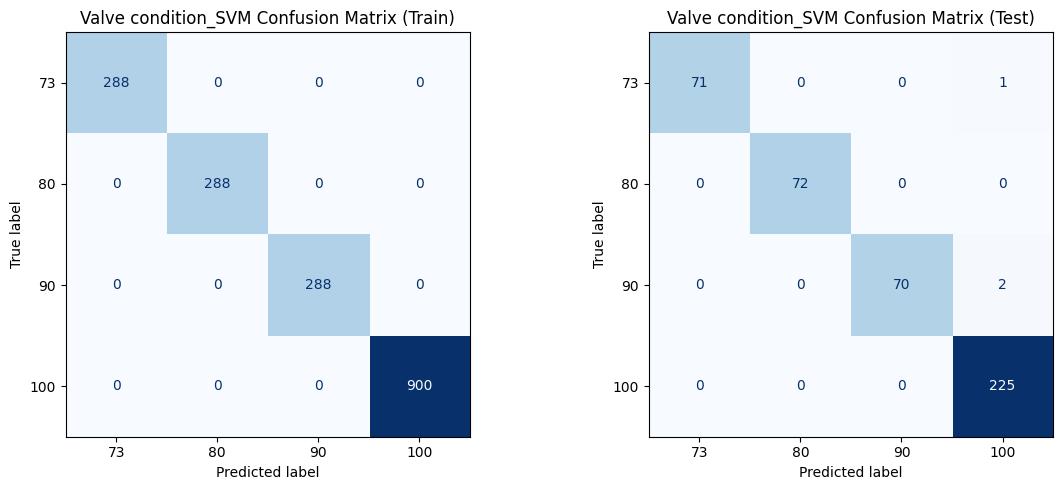


=== Train Classification Report ===
              precision    recall  f1-score   support

          73     1.0000    1.0000    1.0000       288
          80     1.0000    1.0000    1.0000       288
          90     1.0000    1.0000    1.0000       288
         100     1.0000    1.0000    1.0000       900

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          73     1.0000    0.9861    0.9930        72
          80     1.0000    1.0000    1.0000        72
          90     1.0000    0.9722    0.9859        72
         100     0.9868    1.0000    0.9934       225

    accuracy                         0.9932       441
   macro avg     0.9967    0.9896    0.9931       441
weighted avg     0.9933    0.9932    0.9932       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


# 建立 SVM 模型(SVM with RBF)
'''
kernel='rbf': 使用徑向基函數
C: 懲罰參數（越高代表對錯誤容忍度越低）
gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
'''
svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

# 訓練 SVM 模型
Valve_svm_model = svm_model.fit(X_train, y_train)

# 預測
y_train_pred = svm_model.predict(X_train)
y_test_pred  = svm_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Valve condition_SVM Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Valve condition_SVM Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立 SVM 模型(SVM with RBF)
    '''
    kernel='rbf': 使用徑向基函數
    C: 懲罰參數（越高代表對錯誤容忍度越低）
    gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
    '''
    svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

    # 訓練 SVM 模型
    Valve_svm_model = svm_model.fit(X_train, y_train)

    # 預測
    y_pred = svm_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (SVM) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 2 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 3 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

--- Fold 4 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 5 ---
Accuracy: 0.9955
precision: 0.9955
recall: 0.9955
f1-score: 0.9955

=== 5-Fold Cross-Validation Summary (SVM) ===
Mean Accuracy: 0.9968
Std  Accuracy: 0.0018


### XGBoost


Train size: 1764
Test size : 441


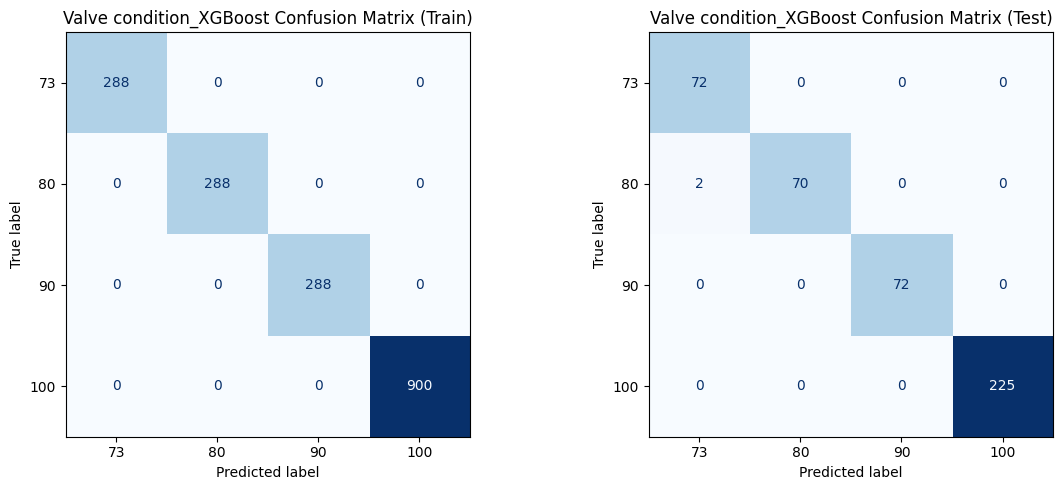


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       288
           1     1.0000    1.0000    1.0000       288
           2     1.0000    1.0000    1.0000       288
           3     1.0000    1.0000    1.0000       900

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9730    1.0000    0.9863        72
           1     1.0000    0.9722    0.9859        72
           2     1.0000    1.0000    1.0000        72
           3     1.0000    1.0000    1.0000       225

    accuracy                         0.9955       441
   macro avg     0.9932    0.9931    0.9931       441
weighted avg     0.9956    0.9955    0.9955       441



In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y, random_state=42)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立 XGBoost 模型
'''
n_estimators: 樹的數量
learning_rate: 學習率 (步長)
max_depth: 每棵樹的最大深度
objective='multi:softprob': 多分類問題
'''
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softprob'
)

# 訓練 XGBoost 模型
Valve_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的數值 (0, 1, 2, 3) 轉回原本數值 (73, 80, 90, 100)
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Valve condition_XGBoost Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Valve condition_XGBoost Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # 建立 XGBoost 模型
    '''
    n_estimators: 樹的數量
    learning_rate: 學習率 (步長)
    max_depth: 每棵樹的最大深度
    objective='multi:softprob': 多分類問題
    '''
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

    # 訓練 XGBoost 模型
    Valve_xgb_model = xgb_model.fit(X_train, y_train)

    # 預測
    y_pred = xgb_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 2 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 3 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 4 ---
Accuracy: 0.9977
precision: 0.9977
recall: 0.9977
f1-score: 0.9977

--- Fold 5 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

=== 5-Fold Cross-Validation Summary (XGBoost) ===
Mean Accuracy: 0.9991
Std  Accuracy: 0.0011


最終模型訓練


Train size: 1764
Test size : 441


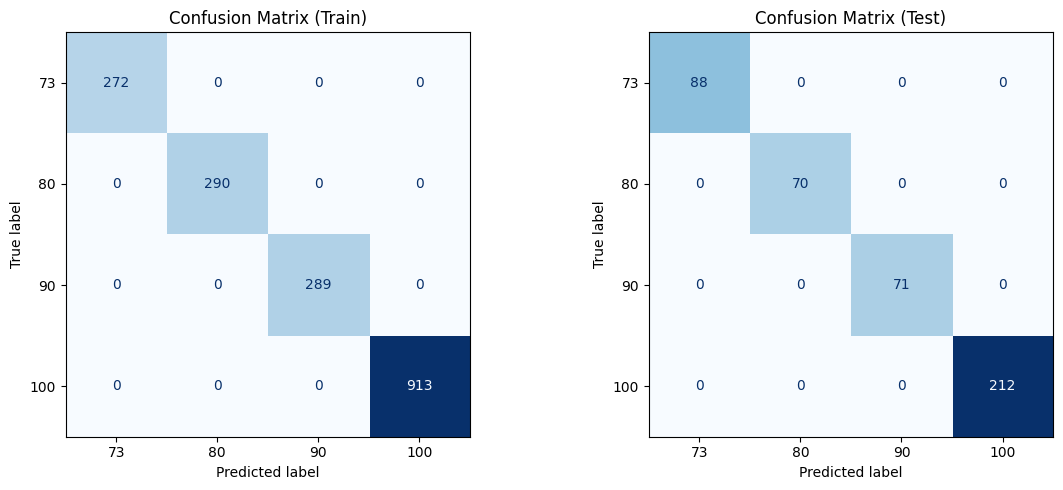


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       272
           1     1.0000    1.0000    1.0000       290
           2     1.0000    1.0000    1.0000       289
           3     1.0000    1.0000    1.0000       913

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        88
           1     1.0000    1.0000    1.0000        70
           2     1.0000    1.0000    1.0000        71
           3     1.0000    1.0000    1.0000       212

    accuracy                         1.0000       441
   macro avg     1.0000    1.0000    1.0000       441
weighted avg     1.0000    1.0000    1.0000       441


--- Fold 1 ---
Accuracy: 0.9977
precision: 0.9977
recall

In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ====== 用特定 index 切分（取代 train_test_split） ======
N = 2205  # 總筆數(0-2204)

test_idx_raw = [1966, 1091, 1468, 438, 1790, 1953, 752, 408, 1477, 2037, 1732, 495, 2022, 1526, 985,
387, 1229, 426, 168, 1455, 1444, 351, 2150, 2115, 275, 528, 1261, 1989, 679, 29, 596, 281, 727, 1383,
2114, 1855, 1323, 432, 1566, 231, 1848, 2109, 2196, 111, 1489, 1023, 1897, 1601, 1822, 617, 1560, 873,
1466, 2190, 1151, 1683, 1928, 1840, 1518, 1708, 994, 1211, 1200, 134, 179, 96, 367, 680, 1414, 1842, 942,
321, 433, 2007, 585, 988, 2014, 360, 196, 1047, 427, 1263, 1313, 73, 233, 353, 2046, 332, 1891, 416, 2018,
1216, 1730, 1916, 361, 2155, 100, 1133, 1010, 2136, 1068, 368, 674, 70, 632, 414, 1653, 2122, 1915, 1533, 240,
2126, 1914, 383, 254, 1075, 1701, 1645, 109, 1910, 1650, 67, 1514, 1234, 1336, 561, 282, 1433, 1582, 668, 1596,
1037, 2056, 1769, 184, 1286, 906, 1204, 1131, 507, 1009, 251, 1473, 923, 1364, 1232, 135, 2063, 1952, 527, 247,
350, 1351, 1739, 1574, 867, 1795, 798, 1551, 128, 932, 1599, 1025, 1753, 1441, 51, 816, 693, 2008, 552, 1776,
599, 1810, 1745, 290, 1298, 1508, 486, 1249, 1979, 554, 1623, 382, 1463, 1283, 1451, 298, 2130, 636, 1949, 1660,
2188, 303, 1394, 1121, 756, 482, 188, 695, 792, 1085, 1033, 1532, 1357, 1611, 48, 1406, 218, 479, 943, 1859, 120,
2176, 211, 1736, 889, 56, 1905, 1618, 1828, 765, 289, 1908, 1187, 485, 1717, 535, 1228, 297, 1173, 1465, 259, 1886,
519, 1178, 1974, 1421, 1513, 1501, 44, 163, 1335, 2081, 1467, 192, 2011, 772, 694, 611, 1557, 1737, 618, 1222, 1379,
69, 634, 480, 1165, 230, 342, 1995, 963, 1767, 538, 976, 239, 99, 1950, 1809, 1210, 581, 1078, 1264, 1185, 812, 124,
1835, 185, 307, 1509, 65, 532, 406, 1677, 1412, 1561, 1805, 430, 1125, 729, 219, 1044, 1138, 1545, 1836, 212, 2108,
555, 1658, 1559, 1876, 841, 893, 529, 1800, 210, 1128, 299, 306, 1430, 707, 435, 1944, 220, 1555, 237, 808, 1544,
354, 1000, 1575, 1170, 324, 979, 445, 13, 1094, 296, 1786, 621, 1517, 1818, 1163, 1100, 1410, 1811, 1237, 1641, 1869,
900, 2180, 862, 1676, 203, 1161, 1343, 785, 478, 410, 2040, 316, 1973, 105, 1832, 121, 948, 2116, 2129, 1036, 1358,
788, 115, 76, 1742, 422, 1192, 2087, 2134, 715, 2096, 925, 1157, 941, 907, 993, 1584, 620, 420, 856, 1602, 859, 952,
178, 1827, 613, 767, 2181, 780, 1005, 651, 1017, 409, 1102, 781, 1941, 1389, 450, 1226, 1612, 886, 2086, 63, 508, 817,
2137, 916, 1057, 1292, 742, 1851, 1972, 1110, 1380, 1823, 471, 1593, 205, 530, 2072, 836, 1889, 1965, 1984, 2054, 1193,
23, 1870, 1958, 1084, 198, 49, 173, 1159, 1583, 2078, 308, 1314, 930, 1735, 59, 71
]

# 所有 index -1（轉成 0-based）
test_idx = np.array([i - 1 for i in test_idx_raw], dtype=int)

# 產生 train index（補集）
all_idx = np.arange(N)
train_idx = np.setdiff1d(all_idx, test_idx)

# 切分 X / y（保留你原本的資料型態：若 X, y 是 pandas 就用 .iloc；若是 numpy 就用 []）
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]  # 如果 y_encoded 是 numpy，改成 y_encoded[train_idx]

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立並訓練 XGBoost 模型
# use_label_encoder=False 是為了避免新版本的警告
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=5,        # 每棵樹的最大深度
    random_state=42,
    objective='multi:softprob' # 多分類問題
)

Valve_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的 0,1,2,3 轉回 73, 80, 90, 100
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後將這些類別按升序排序
labels = sorted(y.unique())

# Confusion Matrices
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Train)")

ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.show()

# Classification reports
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

# ===== 5-fold stratified CV =====
# 重新編碼 y，確保 y_encoded 在當前作用域中
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 定義 make_xgb_model 函式
def make_xgb_model():
    return xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 修正 DataFrame 的索引方式，使用 .iloc
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = make_xgb_model()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    conf_matrices.append(cm)

    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")

### Random Forest Classifier


Train size: 1764
Test size : 441


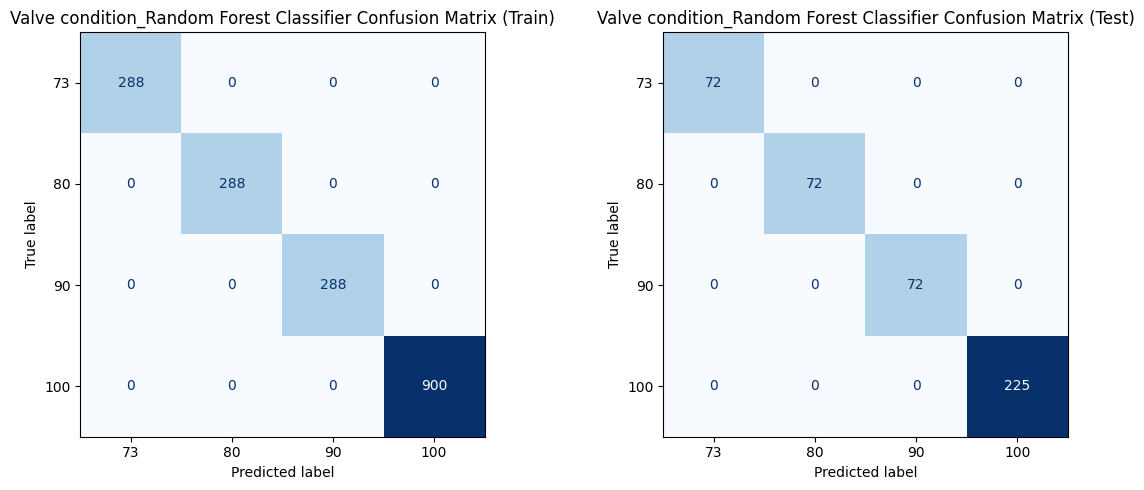


=== Train Classification Report ===
              precision    recall  f1-score   support

          73     1.0000    1.0000    1.0000       288
          80     1.0000    1.0000    1.0000       288
          90     1.0000    1.0000    1.0000       288
         100     1.0000    1.0000    1.0000       900

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          73     1.0000    1.0000    1.0000        72
          80     1.0000    1.0000    1.0000        72
          90     1.0000    1.0000    1.0000        72
         100     1.0000    1.0000    1.0000       225

    accuracy                         1.0000       441
   macro avg     1.0000    1.0000    1.0000       441
weighted avg     1.0000    1.0000    1.0000       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立隨機森林模型
'''
n_estimators: 樹的數量
max_depth: 每棵樹的最大深度
n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
'''
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# 訓練隨機森林模型
Valve_rf_model = rf_model.fit(X_train, y_train)

# 預測
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Valve condition_Random Forest Classifier Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Valve condition_Random Forest Classifier Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立隨機森林模型
    '''
    n_estimators: 樹的數量
    max_depth: 每棵樹的最大深度
    n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
    '''
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        n_jobs=-1
    )

    # 訓練隨機森林模型
    Valve_rf_model = rf_model.fit(X_train, y_train)

    # 預測
    y_pred = rf_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Random Forest) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 2 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 3 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 4 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

--- Fold 5 ---
Accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1-score: 1.0000

=== 5-Fold Cross-Validation Summary (Random Forest) ===
Mean Accuracy: 1.0000
Std  Accuracy: 0.0000


## Pump condition

資料準備

In [ ]:
# 篩選特徵欄位
X = combined_pump_features_df[pump_remaining_features]

# 印出篩選特徵欄位結果
print(f"已成功提取特徵數據 X，形狀為: {X.shape}")
print(X.head())

已成功提取特徵數據 X，形狀為: (2205, 3)
   FS1_all_skew  PS2_seg8_kurt  EPS1_all_mean
0     -1.403308       0.994178    2538.929167
1     -1.450100       0.467172    2531.498900
2     -1.435454       0.320706    2519.928000
3     -1.410198       0.678158    2511.541633
4     -1.426230       0.915267    2503.449500


In [ ]:
# 從 profile 中提取目標變數
try:
    # 提取 pump 欄位作為 target (y)
    y = profiles['pump']

    # 印出提取結果
    print("成功匯入目標數據！")
    print(f"資料筆數: {len(y)}")
    print("\nPump 狀態的分佈狀況 (數值代表不同的損壞程度):")
    print(y.value_counts().sort_index())

    # 將其轉換為 DataFrame 格式以便後續操作
    target_df = pd.DataFrame(y)

# 當程式執行發生錯誤時，印出錯誤原因
except FileNotFoundError:
    print("錯誤：找不到 profile.txt 檔案，請確認檔案路徑是否正確。")

成功匯入目標數據！
資料筆數: 2205

Pump 狀態的分佈狀況 (數值代表不同的損壞程度):
pump
0    1221
1     492
2     492
Name: count, dtype: int64


In [ ]:
# 將 y 中的資料型態轉換為整數
y = y.astype(int)

### Logistic Regression


Train size: 1764
Test size : 441


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


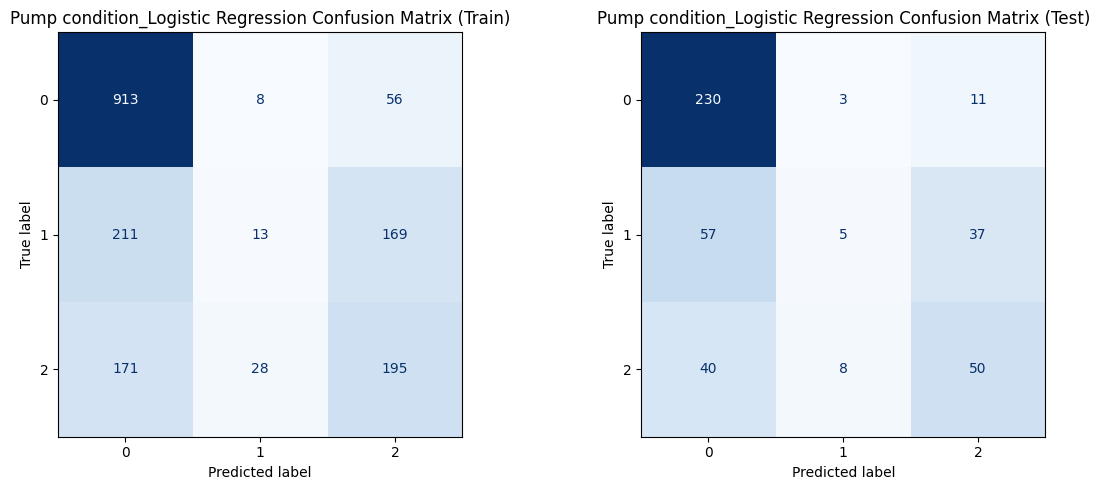


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.7050    0.9345    0.8037       977
           1     0.2653    0.0331    0.0588       393
           2     0.4643    0.4949    0.4791       394

    accuracy                         0.6355      1764
   macro avg     0.4782    0.4875    0.4472      1764
weighted avg     0.5533    0.6355    0.5653      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.7034    0.9426    0.8056       244
           1     0.3125    0.0505    0.0870        99
           2     0.5102    0.5102    0.5102        98

    accuracy                         0.6463       441
   macro avg     0.5087    0.5011    0.4676       441
weighted avg     0.5727    0.6463    0.5786       441



In [ ]:
# 準備資料與標準化
# 數據標準化 (邏輯迴歸對數值極度敏感)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立模型
'''
multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
solver='lbfgs': lbfgs 是一種二階優化演算法
max_iter: 最大迭代次數
'''
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# 訓練模型
Pump_log_reg_model = log_reg.fit(X_train, y_train)

# 預測
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Pump condition_Logistic Regression Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Pump condition_Logistic Regression Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立模型
    '''
    multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
    solver='lbfgs': lbfgs 是一種二階優化演算法
    max_iter: 最大迭代次數
    '''
    log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

    # 訓練模型
    Pump_log_reg_model = log_reg.fit(X_train, y_train)

    # 預測
    y_pred = log_reg.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Logistic Regression) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.6440
precision: 0.6440
recall: 0.6440
f1-score: 0.6440

--- Fold 2 ---
Accuracy: 0.6372
precision: 0.6372
recall: 0.6372
f1-score: 0.6372

--- Fold 3 ---
Accuracy: 0.6417
precision: 0.6417
recall: 0.6417
f1-score: 0.6417

--- Fold 4 ---
Accuracy: 0.6553
precision: 0.6553
recall: 0.6553
f1-score: 0.6553

--- Fold 5 ---
Accuracy: 0.6417
precision: 0.6417
recall: 0.6417
f1-score: 0.6417

=== 5-Fold Cross-Validation Summary (Logistic Regression) ===
Mean Accuracy: 0.6440
Std  Accuracy: 0.0061


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### SVM


Train size: 1764
Test size : 441


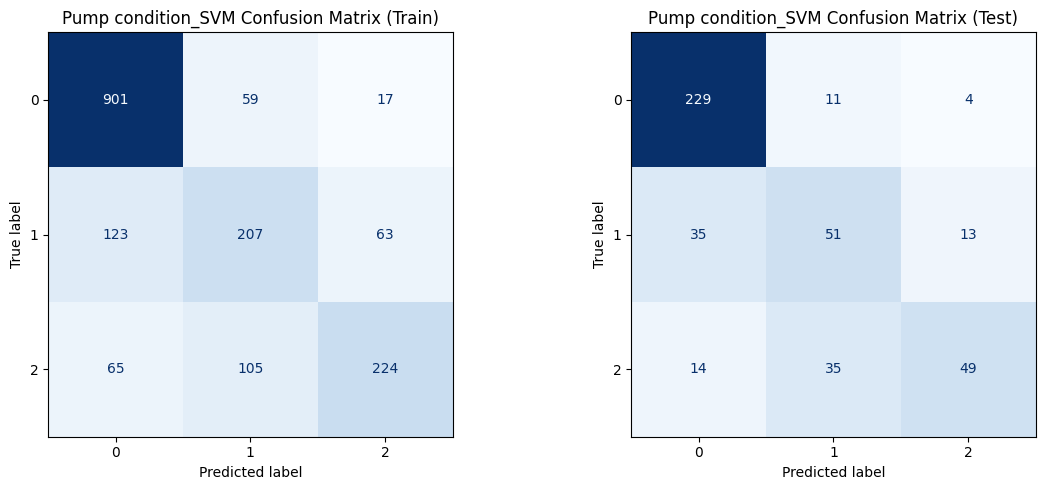


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.8274    0.9222    0.8722       977
           1     0.5580    0.5267    0.5419       393
           2     0.7368    0.5685    0.6418       394

    accuracy                         0.7551      1764
   macro avg     0.7074    0.6725    0.6853      1764
weighted avg     0.7471    0.7551    0.7472      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.8237    0.9385    0.8774       244
           1     0.5258    0.5152    0.5204        99
           2     0.7424    0.5000    0.5976        98

    accuracy                         0.7460       441
   macro avg     0.6973    0.6512    0.6651       441
weighted avg     0.7388    0.7460    0.7351       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


# 建立 SVM 模型(SVM with RBF)
'''
kernel='rbf': 使用徑向基函數
C: 懲罰參數（越高代表對錯誤容忍度越低）
gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
'''
svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

# 訓練 SVM 模型
Pump_svm_model = svm_model.fit(X_train, y_train)

# 預測
y_train_pred = svm_model.predict(X_train)
y_test_pred  = svm_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Pump condition_SVM Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Pump condition_SVM Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立 SVM 模型(SVM with RBF)
    '''
    kernel='rbf': 使用徑向基函數
    C: 懲罰參數（越高代表對錯誤容忍度越低）
    gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
    '''
    svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

    # 訓練 SVM 模型
    Pump_svm_model = svm_model.fit(X_train, y_train)

    # 預測
    y_pred = svm_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (SVM) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.7392
precision: 0.7392
recall: 0.7392
f1-score: 0.7392

--- Fold 2 ---
Accuracy: 0.7506
precision: 0.7506
recall: 0.7506
f1-score: 0.7506

--- Fold 3 ---
Accuracy: 0.7483
precision: 0.7483
recall: 0.7483
f1-score: 0.7483

--- Fold 4 ---
Accuracy: 0.7596
precision: 0.7596
recall: 0.7596
f1-score: 0.7596

--- Fold 5 ---
Accuracy: 0.7483
precision: 0.7483
recall: 0.7483
f1-score: 0.7483

=== 5-Fold Cross-Validation Summary (SVM) ===
Mean Accuracy: 0.7492
Std  Accuracy: 0.0065


### XGBoost


Train size: 1764
Test size : 441


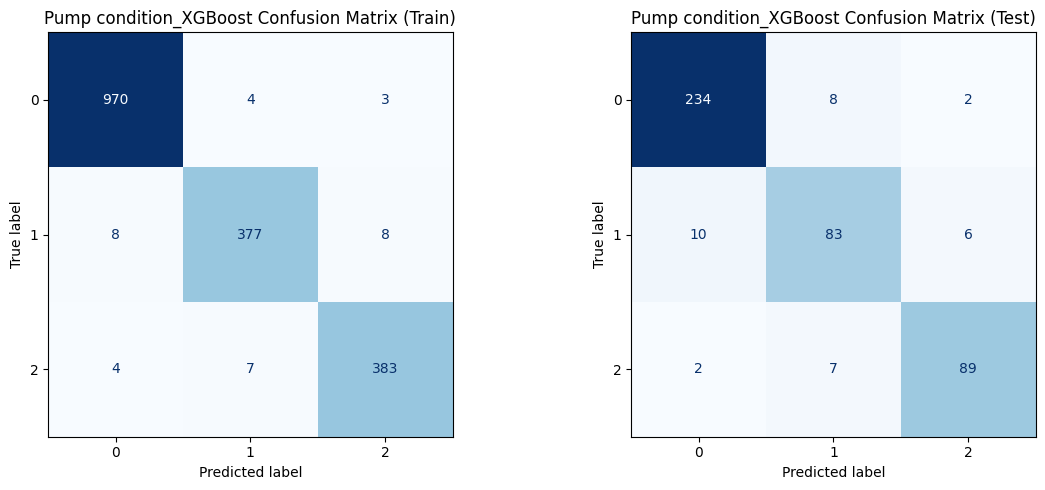


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9878    0.9928    0.9903       977
           1     0.9716    0.9593    0.9654       393
           2     0.9721    0.9721    0.9721       394

    accuracy                         0.9807      1764
   macro avg     0.9772    0.9747    0.9759      1764
weighted avg     0.9807    0.9807    0.9807      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9512    0.9590    0.9551       244
           1     0.8469    0.8384    0.8426        99
           2     0.9175    0.9082    0.9128        98

    accuracy                         0.9206       441
   macro avg     0.9052    0.9019    0.9035       441
weighted avg     0.9203    0.9206    0.9205       441



In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y, random_state=42)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立 XGBoost 模型
'''
n_estimators: 樹的數量
learning_rate: 學習率 (步長)
max_depth: 每棵樹的最大深度
objective='multi:softprob': 多分類問題
'''
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softprob'
)

# 訓練 XGBoost 模型
Pump_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的數值 (0, 1, 2, 3) 轉回原本數值 (73, 80, 90, 100)
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Pump condition_XGBoost Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Pump condition_XGBoost Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # 建立 XGBoost 模型
    '''
    n_estimators: 樹的數量
    learning_rate: 學習率 (步長)
    max_depth: 每棵樹的最大深度
    objective='multi:softprob': 多分類問題
    '''
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

    # 訓練 XGBoost 模型
    Pump_xgb_model = xgb_model.fit(X_train, y_train)

    # 預測
    y_pred = xgb_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9274
precision: 0.9274
recall: 0.9274
f1-score: 0.9274

--- Fold 2 ---
Accuracy: 0.8980
precision: 0.8980
recall: 0.8980
f1-score: 0.8980

--- Fold 3 ---
Accuracy: 0.9116
precision: 0.9116
recall: 0.9116
f1-score: 0.9116

--- Fold 4 ---
Accuracy: 0.9161
precision: 0.9161
recall: 0.9161
f1-score: 0.9161

--- Fold 5 ---
Accuracy: 0.9274
precision: 0.9274
recall: 0.9274
f1-score: 0.9274

=== 5-Fold Cross-Validation Summary (XGBoost) ===
Mean Accuracy: 0.9161
Std  Accuracy: 0.0110


最終模型訓練


Train size: 1764
Test size : 441


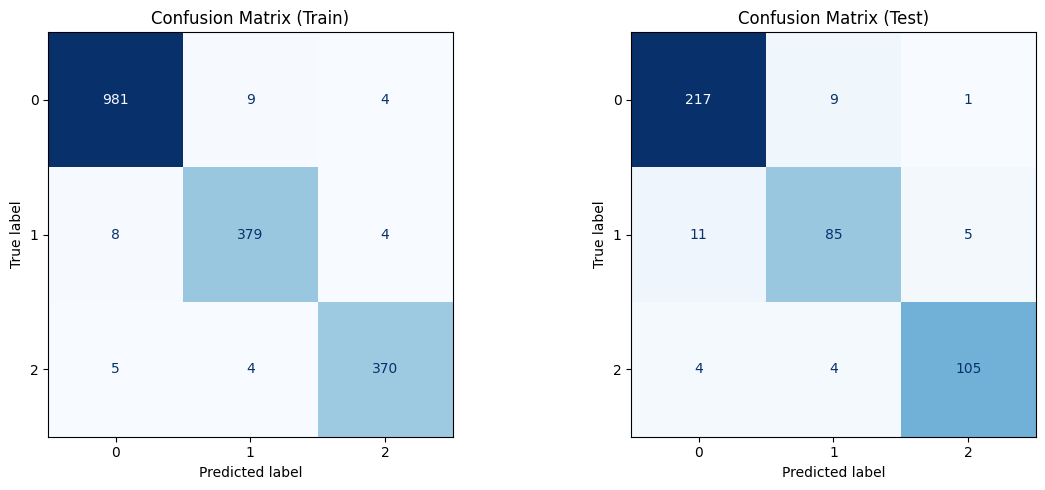


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9869    0.9869    0.9869       994
           1     0.9668    0.9693    0.9681       391
           2     0.9788    0.9763    0.9775       379

    accuracy                         0.9807      1764
   macro avg     0.9775    0.9775    0.9775      1764
weighted avg     0.9807    0.9807    0.9807      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9353    0.9559    0.9455       227
           1     0.8673    0.8416    0.8543       101
           2     0.9459    0.9292    0.9375       113

    accuracy                         0.9229       441
   macro avg     0.9162    0.9089    0.9124       441
weighted avg     0.9225    0.9229    0.9226       441


--- Fold 1 ---
Accuracy: 0.9274
precision: 0.9274
recall: 0.9274
f1-score: 0.9274

--- Fold 2 ---
Accuracy: 0.8980
precision: 0.8980
recall: 0.8980
f1-score: 0.8980

In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ====== 用特定 index 切分（取代 train_test_split） ======
N = 2205  # 總筆數(0-2204)

test_idx_raw = [1966, 1091, 1468, 438, 1790, 1953, 752, 408, 1477, 2037, 1732, 495, 2022, 1526, 985,
387, 1229, 426, 168, 1455, 1444, 351, 2150, 2115, 275, 528, 1261, 1989, 679, 29, 596, 281, 727, 1383,
2114, 1855, 1323, 432, 1566, 231, 1848, 2109, 2196, 111, 1489, 1023, 1897, 1601, 1822, 617, 1560, 873,
1466, 2190, 1151, 1683, 1928, 1840, 1518, 1708, 994, 1211, 1200, 134, 179, 96, 367, 680, 1414, 1842, 942,
321, 433, 2007, 585, 988, 2014, 360, 196, 1047, 427, 1263, 1313, 73, 233, 353, 2046, 332, 1891, 416, 2018,
1216, 1730, 1916, 361, 2155, 100, 1133, 1010, 2136, 1068, 368, 674, 70, 632, 414, 1653, 2122, 1915, 1533, 240,
2126, 1914, 383, 254, 1075, 1701, 1645, 109, 1910, 1650, 67, 1514, 1234, 1336, 561, 282, 1433, 1582, 668, 1596,
1037, 2056, 1769, 184, 1286, 906, 1204, 1131, 507, 1009, 251, 1473, 923, 1364, 1232, 135, 2063, 1952, 527, 247,
350, 1351, 1739, 1574, 867, 1795, 798, 1551, 128, 932, 1599, 1025, 1753, 1441, 51, 816, 693, 2008, 552, 1776,
599, 1810, 1745, 290, 1298, 1508, 486, 1249, 1979, 554, 1623, 382, 1463, 1283, 1451, 298, 2130, 636, 1949, 1660,
2188, 303, 1394, 1121, 756, 482, 188, 695, 792, 1085, 1033, 1532, 1357, 1611, 48, 1406, 218, 479, 943, 1859, 120,
2176, 211, 1736, 889, 56, 1905, 1618, 1828, 765, 289, 1908, 1187, 485, 1717, 535, 1228, 297, 1173, 1465, 259, 1886,
519, 1178, 1974, 1421, 1513, 1501, 44, 163, 1335, 2081, 1467, 192, 2011, 772, 694, 611, 1557, 1737, 618, 1222, 1379,
69, 634, 480, 1165, 230, 342, 1995, 963, 1767, 538, 976, 239, 99, 1950, 1809, 1210, 581, 1078, 1264, 1185, 812, 124,
1835, 185, 307, 1509, 65, 532, 406, 1677, 1412, 1561, 1805, 430, 1125, 729, 219, 1044, 1138, 1545, 1836, 212, 2108,
555, 1658, 1559, 1876, 841, 893, 529, 1800, 210, 1128, 299, 306, 1430, 707, 435, 1944, 220, 1555, 237, 808, 1544,
354, 1000, 1575, 1170, 324, 979, 445, 13, 1094, 296, 1786, 621, 1517, 1818, 1163, 1100, 1410, 1811, 1237, 1641, 1869,
900, 2180, 862, 1676, 203, 1161, 1343, 785, 478, 410, 2040, 316, 1973, 105, 1832, 121, 948, 2116, 2129, 1036, 1358,
788, 115, 76, 1742, 422, 1192, 2087, 2134, 715, 2096, 925, 1157, 941, 907, 993, 1584, 620, 420, 856, 1602, 859, 952,
178, 1827, 613, 767, 2181, 780, 1005, 651, 1017, 409, 1102, 781, 1941, 1389, 450, 1226, 1612, 886, 2086, 63, 508, 817,
2137, 916, 1057, 1292, 742, 1851, 1972, 1110, 1380, 1823, 471, 1593, 205, 530, 2072, 836, 1889, 1965, 1984, 2054, 1193,
23, 1870, 1958, 1084, 198, 49, 173, 1159, 1583, 2078, 308, 1314, 930, 1735, 59, 71
]

# 所有 index -1（轉成 0-based）
test_idx = np.array([i - 1 for i in test_idx_raw], dtype=int)

# 產生 train index（補集）
all_idx = np.arange(N)
train_idx = np.setdiff1d(all_idx, test_idx)

# 切分 X / y（保留你原本的資料型態：若 X, y 是 pandas 就用 .iloc；若是 numpy 就用 []）
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]  # 如果 y_encoded 是 numpy，改成 y_encoded[train_idx]

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立並訓練 XGBoost 模型
# use_label_encoder=False 是為了避免新版本的警告
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=5,        # 每棵樹的最大深度
    random_state=42,
    objective='multi:softprob' # 多分類問題
)

Pump_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的 0,1,2,3 轉回 73, 80, 90, 100
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後將這些類別按升序排序
labels = sorted(y.unique())

# Confusion Matrices
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Train)")

ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.show()

# Classification reports
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

# ===== 5-fold stratified CV =====
# 重新編碼 y，確保 y_encoded 在當前作用域中
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 定義 make_xgb_model 函式
def make_xgb_model():
    return xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 修正 DataFrame 的索引方式，使用 .iloc
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = make_xgb_model()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    conf_matrices.append(cm)

    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")

### Random Forest Classifier


Train size: 1764
Test size : 441


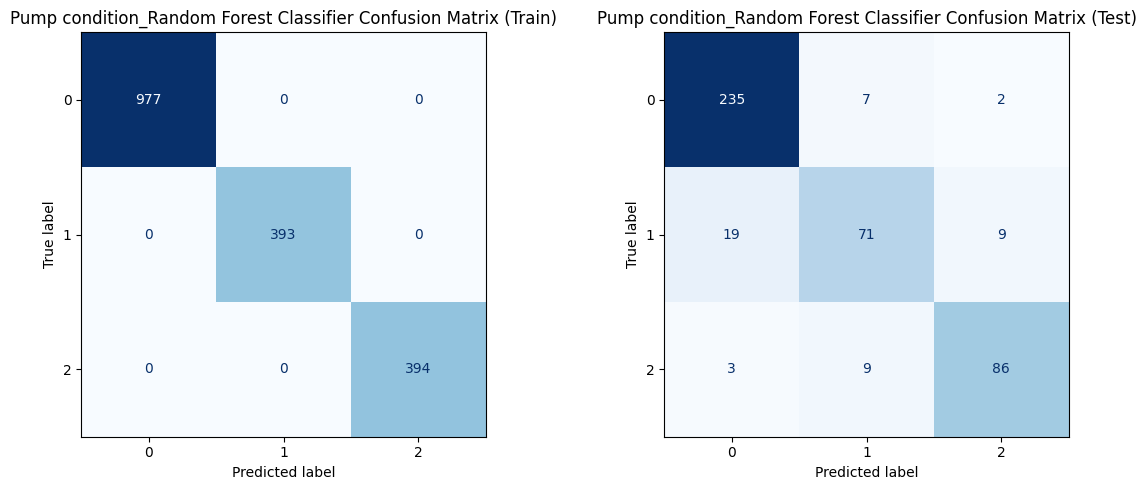


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       977
           1     1.0000    1.0000    1.0000       393
           2     1.0000    1.0000    1.0000       394

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9144    0.9631    0.9381       244
           1     0.8161    0.7172    0.7634        99
           2     0.8866    0.8776    0.8821        98

    accuracy                         0.8889       441
   macro avg     0.8724    0.8526    0.8612       441
weighted avg     0.8862    0.8889    0.8864       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立隨機森林模型
'''
n_estimators: 樹的數量
max_depth: 每棵樹的最大深度
n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
'''
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# 訓練隨機森林模型
Pump_rf_model = rf_model.fit(X_train, y_train)

# 預測
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Pump condition_Random Forest Classifier Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Pump condition_Random Forest Classifier Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立隨機森林模型
    '''
    n_estimators: 樹的數量
    max_depth: 每棵樹的最大深度
    n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
    '''
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        n_jobs=-1
    )

    # 訓練隨機森林模型
    Pump_rf_model = rf_model.fit(X_train, y_train)

    # 預測
    y_pred = rf_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Random Forest) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.9116
precision: 0.9116
recall: 0.9116
f1-score: 0.9116

--- Fold 2 ---
Accuracy: 0.8753
precision: 0.8753
recall: 0.8753
f1-score: 0.8753

--- Fold 3 ---
Accuracy: 0.8821
precision: 0.8821
recall: 0.8821
f1-score: 0.8821

--- Fold 4 ---
Accuracy: 0.8889
precision: 0.8889
recall: 0.8889
f1-score: 0.8889

--- Fold 5 ---
Accuracy: 0.9116
precision: 0.9116
recall: 0.9116
f1-score: 0.9116

=== 5-Fold Cross-Validation Summary (Random Forest) ===
Mean Accuracy: 0.8939
Std  Accuracy: 0.0151


## Accumulator condition

資料準備

In [ ]:
# 篩選特徵欄位
X = combined_accumulator_features_df[accumulator_remaining_features]

# 印出篩選特徵欄位結果
print(f"已成功提取特徵數據 X，形狀為: {X.shape}")
print(X.head())

已成功提取特徵數據 X，形狀為: (2205, 2)
   EPS1_seg1_var  PS1_seg10_var
0   37981.402622       0.021776
1   30023.765101       0.017290
2   29609.851430       0.023132
3   29833.711580       0.018911
4   29565.199723       0.022364


In [ ]:
# 從 profile 中提取目標變數
try:
    # 提取 accumulator 欄位作為 target (y)
    y = profiles['accumulator']

    # 印出提取結果
    print("成功匯入目標數據！")
    print(f"資料筆數: {len(y)}")
    print("\nAccumulator 狀態的分佈狀況 (數值代表不同的損壞程度):")
    print(y.value_counts().sort_index())

    # 將其轉換為 DataFrame 格式以便後續操作
    target_df = pd.DataFrame(y)

# 當程式執行發生錯誤時，印出錯誤原因
except FileNotFoundError:
    print("錯誤：找不到 profile.txt 檔案，請確認檔案路徑是否正確。")

成功匯入目標數據！
資料筆數: 2205

Accumulator 狀態的分佈狀況 (數值代表不同的損壞程度):
accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64


In [ ]:
# 將 y 中的資料型態轉換為整數
y = y.astype(int)

### Logistic Regression


Train size: 1764
Test size : 441


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


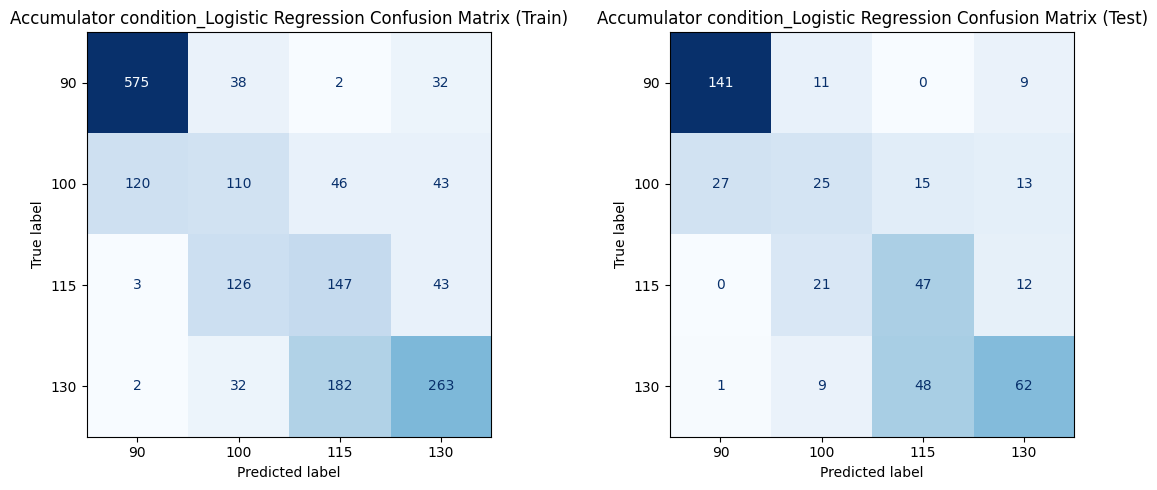


=== Train Classification Report ===
              precision    recall  f1-score   support

          90     0.8214    0.8887    0.8537       647
         100     0.3595    0.3448    0.3520       319
         115     0.3899    0.4608    0.4224       319
         130     0.6903    0.5491    0.6116       479

    accuracy                         0.6207      1764
   macro avg     0.5653    0.5609    0.5599      1764
weighted avg     0.6242    0.6207    0.6193      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          90     0.8343    0.8758    0.8545       161
         100     0.3788    0.3125    0.3425        80
         115     0.4273    0.5875    0.4947        80
         130     0.6458    0.5167    0.5741       120

    accuracy                         0.6236       441
   macro avg     0.5716    0.5731    0.5665       441
weighted avg     0.6266    0.6236    0.6201       441



In [ ]:
# 準備資料與標準化
# 數據標準化 (邏輯迴歸對數值極度敏感)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立模型
'''
multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
solver='lbfgs': lbfgs 是一種二階優化演算法
max_iter: 最大迭代次數
'''
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# 訓練模型
Accumulator_log_reg_model = log_reg.fit(X_train, y_train)

# 預測
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Accumulator condition_Logistic Regression Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Accumulator condition_Logistic Regression Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立模型
    '''
    multi_class='multinomial': 用於處理多個類別 (多項式邏輯回歸)
    solver='lbfgs': lbfgs 是一種二階優化演算法
    max_iter: 最大迭代次數
    '''
    log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

    # 訓練模型
    Accumulator_log_reg_model = log_reg.fit(X_train, y_train)

    # 預測
    y_pred = log_reg.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Logistic Regression) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.6304
precision: 0.6304
recall: 0.6304
f1-score: 0.6304

--- Fold 2 ---
Accuracy: 0.6145
precision: 0.6145
recall: 0.6145
f1-score: 0.6145

--- Fold 3 ---
Accuracy: 0.6077
precision: 0.6077
recall: 0.6077
f1-score: 0.6077

--- Fold 4 ---
Accuracy: 0.6349
precision: 0.6349
recall: 0.6349
f1-score: 0.6349

--- Fold 5 ---
Accuracy: 0.6009
precision: 0.6009
recall: 0.6009
f1-score: 0.6009

=== 5-Fold Cross-Validation Summary (Logistic Regression) ===
Mean Accuracy: 0.6177
Std  Accuracy: 0.0130


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

### SVM


Train size: 1764
Test size : 441


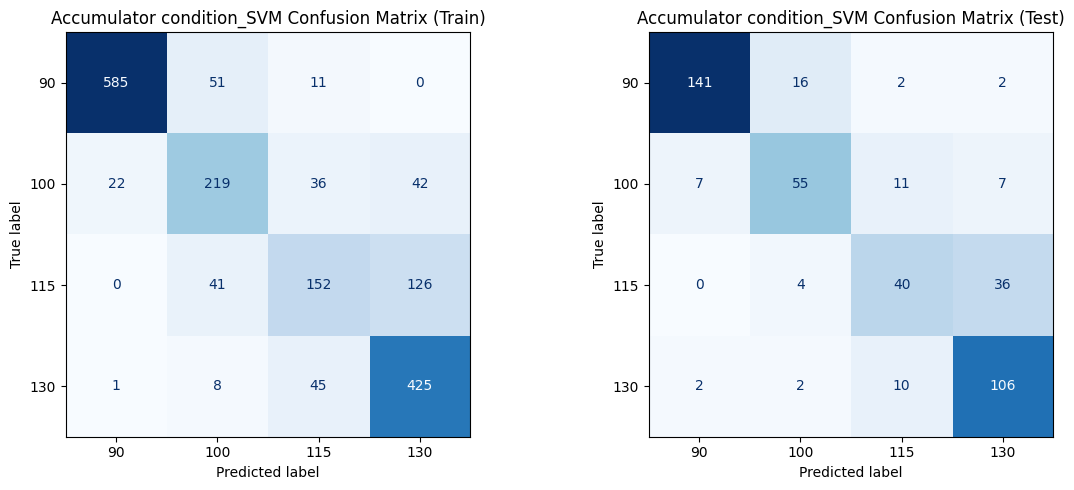


=== Train Classification Report ===
              precision    recall  f1-score   support

          90     0.9622    0.9042    0.9323       647
         100     0.6865    0.6865    0.6865       319
         115     0.6230    0.4765    0.5400       319
         130     0.7167    0.8873    0.7929       479

    accuracy                         0.7829      1764
   macro avg     0.7471    0.7386    0.7379      1764
weighted avg     0.7843    0.7829    0.7790      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          90     0.9400    0.8758    0.9068       161
         100     0.7143    0.6875    0.7006        80
         115     0.6349    0.5000    0.5594        80
         130     0.7020    0.8833    0.7823       120

    accuracy                         0.7755       441
   macro avg     0.7478    0.7367    0.7373       441
weighted avg     0.7789    0.7755    0.7725       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


# 建立 SVM 模型(SVM with RBF)
'''
kernel='rbf': 使用徑向基函數
C: 懲罰參數（越高代表對錯誤容忍度越低）
gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
'''
svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

# 訓練 SVM 模型
Accumulator_svm_model = svm_model.fit(X_train, y_train)

# 預測
y_train_pred = svm_model.predict(X_train)
y_test_pred  = svm_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Accumulator condition_SVM Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Accumulator condition_SVM Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立 SVM 模型(SVM with RBF)
    '''
    kernel='rbf': 使用徑向基函數
    C: 懲罰參數（越高代表對錯誤容忍度越低）
    gamma: 定義單個樣本的影響範圍（越高代表每個點的影響範圍很小， 'scale' 是 Scikit-learn 的預設值）
    '''
    svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

    # 訓練 SVM 模型
    Accumulator_svm_model = svm_model.fit(X_train, y_train)

    # 預測
    y_pred = svm_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (SVM) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.7664
precision: 0.7664
recall: 0.7664
f1-score: 0.7664

--- Fold 2 ---
Accuracy: 0.7642
precision: 0.7642
recall: 0.7642
f1-score: 0.7642

--- Fold 3 ---
Accuracy: 0.7687
precision: 0.7687
recall: 0.7687
f1-score: 0.7687

--- Fold 4 ---
Accuracy: 0.7823
precision: 0.7823
recall: 0.7823
f1-score: 0.7823

--- Fold 5 ---
Accuracy: 0.7619
precision: 0.7619
recall: 0.7619
f1-score: 0.7619

=== 5-Fold Cross-Validation Summary (SVM) ===
Mean Accuracy: 0.7687
Std  Accuracy: 0.0072


### XGBoost


Train size: 1764
Test size : 441


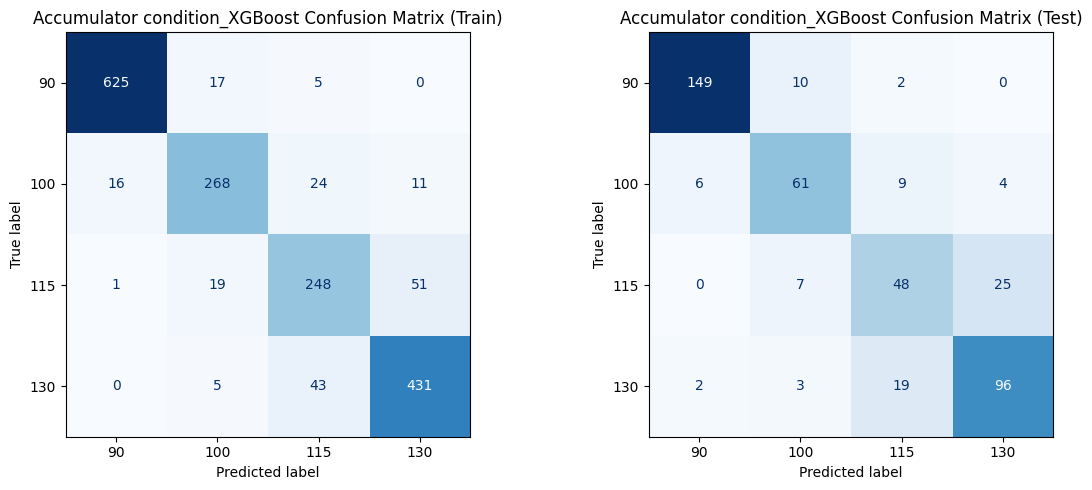


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9735    0.9660    0.9697       647
           1     0.8673    0.8401    0.8535       319
           2     0.7750    0.7774    0.7762       319
           3     0.8742    0.8998    0.8868       479

    accuracy                         0.8912      1764
   macro avg     0.8725    0.8708    0.8716      1764
weighted avg     0.8915    0.8912    0.8912      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9490    0.9255    0.9371       161
           1     0.7531    0.7625    0.7578        80
           2     0.6154    0.6000    0.6076        80
           3     0.7680    0.8000    0.7837       120

    accuracy                         0.8027       441
   macro avg     0.7714    0.7720    0.7715       441
weighted avg     0.8037    0.8027    0.8030       441



In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y, random_state=42)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立 XGBoost 模型
'''
n_estimators: 樹的數量
learning_rate: 學習率 (步長)
max_depth: 每棵樹的最大深度
objective='multi:softprob': 多分類問題
'''
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softprob'
)

# 訓練 XGBoost 模型
Accumulator_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的數值 (0, 1, 2, 3) 轉回原本數值 (73, 80, 90, 100)
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Accumulator condition_XGBoost Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Accumulator condition_XGBoost Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # 建立 XGBoost 模型
    '''
    n_estimators: 樹的數量
    learning_rate: 學習率 (步長)
    max_depth: 每棵樹的最大深度
    objective='multi:softprob': 多分類問題
    '''
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

    # 訓練 XGBoost 模型
    Accumulator_xgb_model = xgb_model.fit(X_train, y_train)

    # 預測
    y_pred = xgb_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.8186
precision: 0.8186
recall: 0.8186
f1-score: 0.8186

--- Fold 2 ---
Accuracy: 0.8118
precision: 0.8118
recall: 0.8118
f1-score: 0.8118

--- Fold 3 ---
Accuracy: 0.8435
precision: 0.8435
recall: 0.8435
f1-score: 0.8435

--- Fold 4 ---
Accuracy: 0.8141
precision: 0.8141
recall: 0.8141
f1-score: 0.8141

--- Fold 5 ---
Accuracy: 0.8095
precision: 0.8095
recall: 0.8095
f1-score: 0.8095

=== 5-Fold Cross-Validation Summary (XGBoost) ===
Mean Accuracy: 0.8195
Std  Accuracy: 0.0124


最終模型訓練


Train size: 1764
Test size : 441


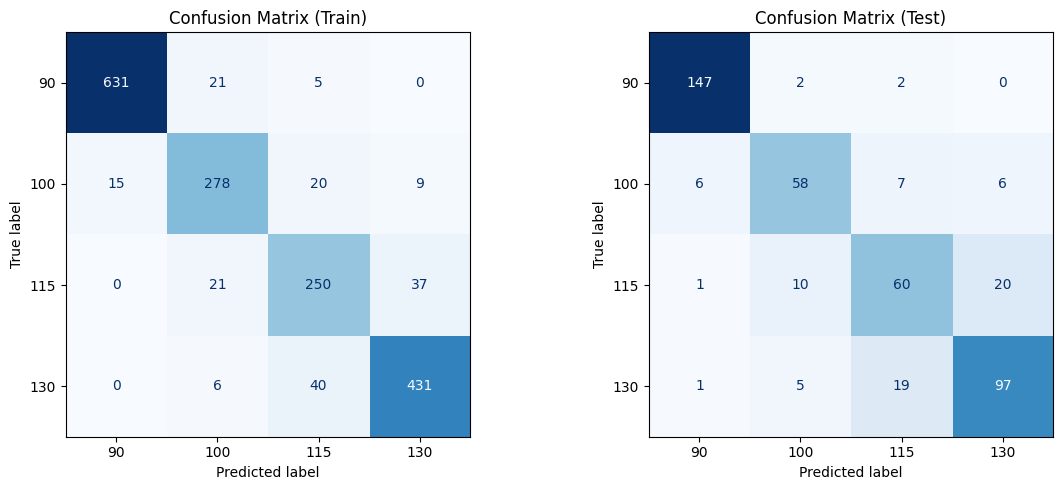


=== Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9768    0.9604    0.9685       657
           1     0.8528    0.8634    0.8580       322
           2     0.7937    0.8117    0.8026       308
           3     0.9036    0.9036    0.9036       477

    accuracy                         0.9014      1764
   macro avg     0.8817    0.8848    0.8832      1764
weighted avg     0.9024    0.9014    0.9018      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

           0     0.9484    0.9735    0.9608       151
           1     0.7733    0.7532    0.7632        77
           2     0.6818    0.6593    0.6704        91
           3     0.7886    0.7951    0.7918       122

    accuracy                         0.8209       441
   macro avg     0.7980    0.7953    0.7965       441
weighted avg     0.8186    0.8209    0.8196       441


--- Fold 1 ---
Accuracy: 0.8186
precision: 0.8186
recall

In [ ]:
# 準備資料
# XGBoost 對標籤的要求通常是從 0 開始的整數，因此需要進行編碼
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ====== 用特定 index 切分（取代 train_test_split） ======
N = 2205  # 總筆數(0-2204)

test_idx_raw = [1966, 1091, 1468, 438, 1790, 1953, 752, 408, 1477, 2037, 1732, 495, 2022, 1526, 985,
387, 1229, 426, 168, 1455, 1444, 351, 2150, 2115, 275, 528, 1261, 1989, 679, 29, 596, 281, 727, 1383,
2114, 1855, 1323, 432, 1566, 231, 1848, 2109, 2196, 111, 1489, 1023, 1897, 1601, 1822, 617, 1560, 873,
1466, 2190, 1151, 1683, 1928, 1840, 1518, 1708, 994, 1211, 1200, 134, 179, 96, 367, 680, 1414, 1842, 942,
321, 433, 2007, 585, 988, 2014, 360, 196, 1047, 427, 1263, 1313, 73, 233, 353, 2046, 332, 1891, 416, 2018,
1216, 1730, 1916, 361, 2155, 100, 1133, 1010, 2136, 1068, 368, 674, 70, 632, 414, 1653, 2122, 1915, 1533, 240,
2126, 1914, 383, 254, 1075, 1701, 1645, 109, 1910, 1650, 67, 1514, 1234, 1336, 561, 282, 1433, 1582, 668, 1596,
1037, 2056, 1769, 184, 1286, 906, 1204, 1131, 507, 1009, 251, 1473, 923, 1364, 1232, 135, 2063, 1952, 527, 247,
350, 1351, 1739, 1574, 867, 1795, 798, 1551, 128, 932, 1599, 1025, 1753, 1441, 51, 816, 693, 2008, 552, 1776,
599, 1810, 1745, 290, 1298, 1508, 486, 1249, 1979, 554, 1623, 382, 1463, 1283, 1451, 298, 2130, 636, 1949, 1660,
2188, 303, 1394, 1121, 756, 482, 188, 695, 792, 1085, 1033, 1532, 1357, 1611, 48, 1406, 218, 479, 943, 1859, 120,
2176, 211, 1736, 889, 56, 1905, 1618, 1828, 765, 289, 1908, 1187, 485, 1717, 535, 1228, 297, 1173, 1465, 259, 1886,
519, 1178, 1974, 1421, 1513, 1501, 44, 163, 1335, 2081, 1467, 192, 2011, 772, 694, 611, 1557, 1737, 618, 1222, 1379,
69, 634, 480, 1165, 230, 342, 1995, 963, 1767, 538, 976, 239, 99, 1950, 1809, 1210, 581, 1078, 1264, 1185, 812, 124,
1835, 185, 307, 1509, 65, 532, 406, 1677, 1412, 1561, 1805, 430, 1125, 729, 219, 1044, 1138, 1545, 1836, 212, 2108,
555, 1658, 1559, 1876, 841, 893, 529, 1800, 210, 1128, 299, 306, 1430, 707, 435, 1944, 220, 1555, 237, 808, 1544,
354, 1000, 1575, 1170, 324, 979, 445, 13, 1094, 296, 1786, 621, 1517, 1818, 1163, 1100, 1410, 1811, 1237, 1641, 1869,
900, 2180, 862, 1676, 203, 1161, 1343, 785, 478, 410, 2040, 316, 1973, 105, 1832, 121, 948, 2116, 2129, 1036, 1358,
788, 115, 76, 1742, 422, 1192, 2087, 2134, 715, 2096, 925, 1157, 941, 907, 993, 1584, 620, 420, 856, 1602, 859, 952,
178, 1827, 613, 767, 2181, 780, 1005, 651, 1017, 409, 1102, 781, 1941, 1389, 450, 1226, 1612, 886, 2086, 63, 508, 817,
2137, 916, 1057, 1292, 742, 1851, 1972, 1110, 1380, 1823, 471, 1593, 205, 530, 2072, 836, 1889, 1965, 1984, 2054, 1193,
23, 1870, 1958, 1084, 198, 49, 173, 1159, 1583, 2078, 308, 1314, 930, 1735, 59, 71
]

# 所有 index -1（轉成 0-based）
test_idx = np.array([i - 1 for i in test_idx_raw], dtype=int)

# 產生 train index（補集）
all_idx = np.arange(N)
train_idx = np.setdiff1d(all_idx, test_idx)

# 切分 X / y（保留你原本的資料型態：若 X, y 是 pandas 就用 .iloc；若是 numpy 就用 []）
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]  # 如果 y_encoded 是 numpy，改成 y_encoded[train_idx]

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立並訓練 XGBoost 模型
# use_label_encoder=False 是為了避免新版本的警告
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=5,        # 每棵樹的最大深度
    random_state=42,
    objective='multi:softprob' # 多分類問題
)

Accumulator_xgb_model = xgb_model.fit(X_train, y_train)

# 預測
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 將編碼後的 0,1,2,3 轉回 73, 80, 90, 100
y_train_original = le.inverse_transform(y_train)
y_train_pred_original = le.inverse_transform(y_train_pred)
y_test_original = le.inverse_transform(y_test)
y_test_pred_original = le.inverse_transform(y_test_pred)

# 找出目標變數 y 中所有不重複的類別，然後將這些類別按升序排序
labels = sorted(y.unique())

# Confusion Matrices
cm_train = confusion_matrix(y_train_original, y_train_pred_original, labels=labels)
cm_test  = confusion_matrix(y_test_original,  y_test_pred_original,  labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Train)")

ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.show()

# Classification reports
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

# ===== 5-fold stratified CV =====
# 重新編碼 y，確保 y_encoded 在當前作用域中
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 定義 make_xgb_model 函式
def make_xgb_model():
    return xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective='multi:softprob'
    )

# 定義 labels_original 和 labels_encoded
labels_original = sorted(y.unique())
labels_encoded = le.transform(labels_original)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), 1):
    # 修正 DataFrame 的索引方式，使用 .iloc
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = make_xgb_model()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    cm = confusion_matrix(y_test, y_pred, labels=labels_encoded)
    conf_matrices.append(cm)

    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (XGBoost) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")

### Random Forest Classifier


Train size: 1764
Test size : 441


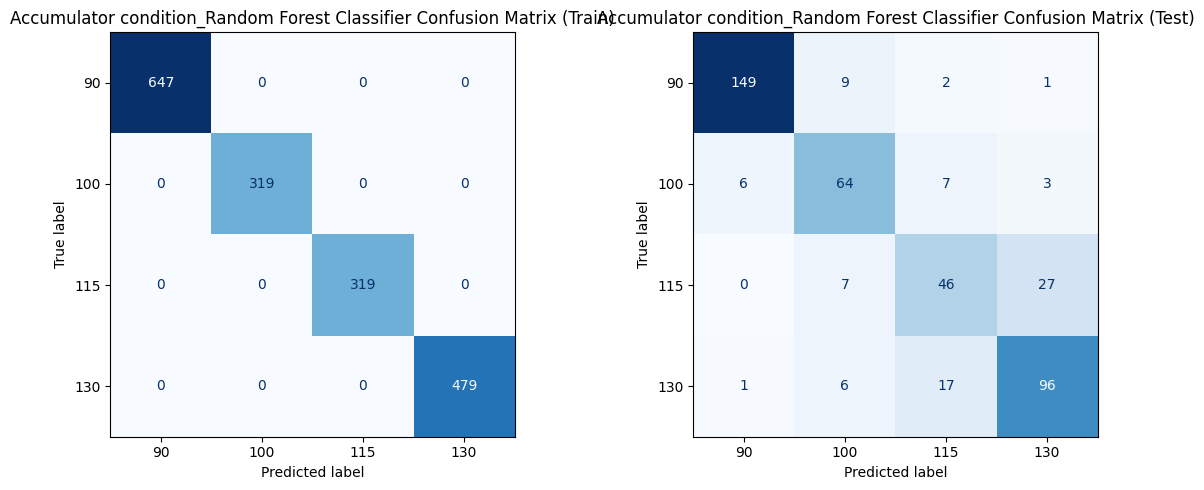


=== Train Classification Report ===
              precision    recall  f1-score   support

          90     1.0000    1.0000    1.0000       647
         100     1.0000    1.0000    1.0000       319
         115     1.0000    1.0000    1.0000       319
         130     1.0000    1.0000    1.0000       479

    accuracy                         1.0000      1764
   macro avg     1.0000    1.0000    1.0000      1764
weighted avg     1.0000    1.0000    1.0000      1764


=== Test Classification Report ===
              precision    recall  f1-score   support

          90     0.9551    0.9255    0.9401       161
         100     0.7442    0.8000    0.7711        80
         115     0.6389    0.5750    0.6053        80
         130     0.7559    0.8000    0.7773       120

    accuracy                         0.8050       441
   macro avg     0.7735    0.7751    0.7734       441
weighted avg     0.8053    0.8050    0.8044       441



In [ ]:
# 準備資料與標準化
# 數據標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分資料 (訓練集和測試集)
'''
test_size=0.2: 切分的比例 (使用 80% 資料訓練模型，剩下 20% 資料當作測試集)
stratify=y: 層次抽樣

'''
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
# 印出切分資料的結果
print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# 建立隨機森林模型
'''
n_estimators: 樹的數量
max_depth: 每棵樹的最大深度
n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
'''
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

# 訓練隨機森林模型
Accumulator_rf_model = rf_model.fit(X_train, y_train)

# 預測
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

# 找出目標變數 y 中所有不重複的類別，然後按升序排序
labels = sorted(y.unique())

# 計算混淆矩陣
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
cm_test  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 混淆矩陣視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_train, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", colorbar=False, cmap="Blues")
axes[0].set_title("Accumulator condition_Random Forest Classifier Confusion Matrix (Train)")
ConfusionMatrixDisplay(cm_test, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", colorbar=False, cmap="Blues")
axes[1].set_title("Accumulator condition_Random Forest Classifier Confusion Matrix (Test)")
# 自動調整圖表間距
plt.tight_layout()
plt.show()

# 印出分類報告
print("\n=== Train Classification Report ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred, digits=4))

五折交叉驗證

In [ ]:
# 分層五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 創建空的 list ，用以存取計算出的準確率與混淆矩陣
acc_scores = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    # 切分 X / y（保留原本資料型態：若 X, y 是 pandas 用 .iloc；若是 numpy 用 []）
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 建立隨機森林模型
    '''
    n_estimators: 樹的數量
    max_depth: 每棵樹的最大深度
    n_jobs: 使用的 CPU 數量（-1 代表使用所有 CPU）
    '''
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        n_jobs=-1
    )

    # 訓練隨機森林模型
    Accumulator_rf_model = rf_model.fit(X_train, y_train)

    # 預測
    y_pred = rf_model.predict(X_test)

    # 計算準確率
    acc = accuracy_score(y_test, y_pred)
    # 將計算結果存入 list 中
    acc_scores.append(acc)

    # 建立混淆矩陣
    cm = confusion_matrix(y_test, y_pred)
    # 將計算結果存入 list 中
    conf_matrices.append(cm)

    # 印出結果
    print(f"\n--- Fold {fold} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"precision: {acc:.4f}")
    print(f"recall: {acc:.4f}")
    print(f"f1-score: {acc:.4f}")

# ===== summary =====
print("\n=== 5-Fold Cross-Validation Summary (Random Forest) ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f}")
print(f"Std  Accuracy: {np.std(acc_scores):.4f}")


--- Fold 1 ---
Accuracy: 0.8209
precision: 0.8209
recall: 0.8209
f1-score: 0.8209

--- Fold 2 ---
Accuracy: 0.8050
precision: 0.8050
recall: 0.8050
f1-score: 0.8050

--- Fold 3 ---
Accuracy: 0.8345
precision: 0.8345
recall: 0.8345
f1-score: 0.8345

--- Fold 4 ---
Accuracy: 0.8095
precision: 0.8095
recall: 0.8095
f1-score: 0.8095

--- Fold 5 ---
Accuracy: 0.8095
precision: 0.8095
recall: 0.8095
f1-score: 0.8095

=== 5-Fold Cross-Validation Summary (Random Forest) ===
Mean Accuracy: 0.8159
Std  Accuracy: 0.0107
